# Radiative Transfer in Snow and Ice: From Maxwell to Albedo

## A Physics Primer for BioSNICAR

This notebook teaches the **physics of radiative transfer** in snow and ice
from first principles — starting with Maxwell's equations and building up,
layer by layer, to the complete adding-doubling solver implemented in
BioSNICAR.

### Structure

| Act | Theme | Sections | Core question |
|-----|-------|----------|---------------|
| I   | From Maxwell to Mie | 1 – 4 | How does light interact with a single ice grain? |
| II  | Single Particles → Bulk Properties | 5 – 8 | How do many grains create a scattering medium? |
| III | The Radiative Transfer Equation | 9 – 13 | How does light propagate through a layered snowpack? |
| IV  | Light-Absorbing Particles | 14 – 18 | How do impurities darken the surface? |
| V   | The Complete BioSNICAR Solver | 19 – 22 | How does BioSNICAR assemble all the pieces? |
| VI  | Putting It All Together | 23 – 25 | Sensitivity, demonstrations, and summary |

### How to use this notebook

- **Run cells in order** — later sections depend on objects built earlier.
- **BioSNICAR connection** boxes map each concept to the exact source file and function.
- **Toy models** let you explore the physics interactively without running the full model.
- Section 24 optionally runs a real BioSNICAR forward model for comparison.

> **Dependencies**: `numpy`, `scipy`, `matplotlib`.
> `miepython` is optional (a Rayleigh-limit fallback is provided).
> Section 24 optionally uses `biosnicar`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from pathlib import Path

# Attempt optional imports
try:
    import miepython
    HAS_MIEPYTHON = True
except ImportError:
    HAS_MIEPYTHON = False
    print("miepython not installed — using Rayleigh-limit approximations.")

try:
    import biosnicar
    HAS_BIOSNICAR = True
except ImportError:
    HAS_BIOSNICAR = False
    print("biosnicar not installed — Section 24 (capstone) will be skipped.")

# Plotting defaults
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Shared wavelength grid — matches BioSNICAR's 480 bands (0.205–4.995 µm)
WAVELENGTH = np.linspace(0.205, 4.995, 480)

# Reduced wavelength grid for Mie calculations (fast — avoids huge size parameters)
# 200 points over the VIS-NIR range used in most plots.  This resolves the
# main absorption features in ice (1.03, 1.25, 1.5, 2.0 µm) cleanly.
WVL_FAST = np.linspace(0.3, 2.5, 200)

# Locate BioSNICAR data directory (works if run from repo root or notebooks/)
_repo = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path(".")
DATA_DIR = None
for candidate in [_repo / "data", Path("../data"), Path("data")]:
    if (candidate / "OP_data" / "480band").is_dir():
        DATA_DIR = candidate.resolve()
        break

print(f"Wavelength grid: {len(WAVELENGTH)} bands, "
      f"{WAVELENGTH[0]:.3f} – {WAVELENGTH[-1]:.3f} µm")
print(f"Fast Mie grid: {len(WVL_FAST)} bands, "
      f"{WVL_FAST[0]:.3f} – {WVL_FAST[-1]:.3f} µm")
if DATA_DIR:
    print(f"BioSNICAR data: {DATA_DIR}")
else:
    print("BioSNICAR data not found — using analytical approximations only.")

# ------------------------------------------------------------------
# Load ice refractive index EARLY so all Mie plots use real data
# ------------------------------------------------------------------
def _ice_ri_approx_setup(wavelength_um):
    """Smooth analytical fallback for ice refractive index."""
    n_re = 1.31 - 0.005 * (wavelength_um - 0.5)
    ln_k = np.where(wavelength_um < 0.6, -21 + 3*(wavelength_um - 0.3),
            np.where(wavelength_um < 1.5, -20 + 12*(wavelength_um - 0.6),
                     -9 + 2*(wavelength_um - 1.5)))
    n_im = np.exp(ln_k)
    n_im += 5e-4 * np.exp(-((wavelength_um - 1.5)/0.08)**2)
    n_im += 2e-3 * np.exp(-((wavelength_um - 2.0)/0.1)**2)
    return n_re, n_im

RHO_ICE = 917.0  # kg/m³

# Try to load real measured refractive index
_ri_source = "analytical approximation"
if DATA_DIR is not None:
    _fpath = DATA_DIR / "OP_data" / "480band" / "rfidx_ice.npz"
    if _fpath.is_file():
        _ri_data = np.load(_fpath)
        _wvl_ri = _ri_data["wvl"]
        # Prefer Warren 2008, then Picard 2016, then Warren 1984
        for _dsname in ["Wrn08", "Pic16", "Wrn84"]:
            if f"re_{_dsname}" in _ri_data and f"im_{_dsname}" in _ri_data:
                _n_re_full = _ri_data[f"re_{_dsname}"]
                _n_im_full = _ri_data[f"im_{_dsname}"]
                _ri_source = _dsname
                break

if _ri_source == "analytical approximation":
    # Fallback: use analytical approximation
    _n_re_full = _ice_ri_approx_setup(WAVELENGTH)[0]
    _n_im_full = _ice_ri_approx_setup(WAVELENGTH)[1]
    _wvl_ri = WAVELENGTH

# Interpolate onto the fast Mie grid — used by ALL Mie plots
N_RE = np.interp(WVL_FAST, _wvl_ri, _n_re_full)
N_IM = np.interp(WVL_FAST, _wvl_ri, _n_im_full)

print(f"Ice refractive index: {_ri_source}")
print(f"  N_RE, N_IM on fast grid ({len(N_RE)} pts) — "
      f"available for all Mie calculations")


Wavelength grid: 480 bands, 0.205 – 4.995 µm
Fast Mie grid: 200 bands, 0.300 – 2.500 µm
BioSNICAR data: /home/joe/Code/biosnicar-py/data
Ice refractive index: Wrn08
  N_RE, N_IM on fast grid (200 pts) — available for all Mie calculations


---
# Act I: From Maxwell to Mie

## Section 1 — From Maxwell's Equations to Absorption

### Starting point: what is light?

Light is an **electromagnetic wave** — oscillating electric and magnetic fields
that propagate through space.  In 1865, James Clerk Maxwell unified electricity,
magnetism, and optics into four equations that govern all electromagnetic
phenomena.  We don't need to solve Maxwell's equations directly, but
understanding the key result — the **wave equation** — is essential for
everything that follows.

### Maxwell's equations and the wave equation

In a material (like ice or air), the electric field $\mathbf{E}$ and magnetic
field $\mathbf{B}$ obey Maxwell's equations.  For a **linear, isotropic,
homogeneous** medium (one where the material properties don't depend on
field strength, direction, or position), these simplify to the **wave equation**:

$$
\nabla^2 \mathbf{E} = \mu \epsilon \frac{\partial^2 \mathbf{E}}{\partial t^2}
$$

where:
- $\nabla^2$ is the Laplacian operator (second spatial derivative in all
  directions) — it captures how the field curves in space
- $\mu$ is the **magnetic permeability** of the medium (how the medium
  responds to magnetic fields; for most optical materials $\mu \approx \mu_0$)
- $\epsilon$ is the **electric permittivity** (how the medium responds to
  electric fields — this is the key material property for optics)
- $\partial^2 \mathbf{E}/\partial t^2$ is the second time derivative — it
  captures the oscillation

This equation says: *the spatial curvature of the field is proportional to
its temporal acceleration*.  This is the defining property of a wave — the
same mathematical form appears in vibrating strings, sound waves, and water
waves.  The speed of the wave is $v = 1/\sqrt{\mu\epsilon}$.

### Plane-wave solution

The simplest solution to the wave equation is a **plane wave** propagating in
one direction (let's call it $z$).  If we allow the medium to absorb energy
(which ice does), the permittivity $\epsilon$ becomes **complex**, and the
solution is:

$$
E(z,t) = E_0 \, e^{i(\tilde{n} k_0 z - \omega t)}
$$

where:
- $E_0$ is the amplitude of the electric field
- $\omega = 2\pi c/\lambda_0$ is the angular frequency ($c$ = speed of light,
  $\lambda_0$ = wavelength in vacuum)
- $k_0 = 2\pi/\lambda_0$ is the **free-space wavenumber** (how many radians
  of oscillation per metre in vacuum)
- $\tilde{n} = n + i\kappa$ is the **complex refractive index** of the medium

### The complex refractive index: $\tilde{n} = n + i\kappa$

This is the central quantity linking Maxwell's equations to optics.  To see
what the two parts do, substitute $\tilde{n} = n + i\kappa$ into the plane
wave:

$$
E(z,t) = E_0 \, e^{i(n k_0 z - \omega t)} \cdot e^{-\kappa k_0 z}
$$

The first factor is a wave oscillating in space and time with wavelength
$\lambda = \lambda_0/n$.  The second factor is a **decaying exponential**.

- **Real part $n$** (typically 1.0–2.5 for common materials): Controls the
  **phase velocity** $v = c/n$.  Light travels slower in media with higher
  $n$; this is what causes refraction (bending of light at interfaces).
  For ice, $n \approx 1.31$.
- **Imaginary part $\kappa$** (ranges from $\sim 10^{-11}$ to $\sim 1$):
  Controls **absorption**.  A larger $\kappa$ means the wave amplitude
  decreases more rapidly with distance — energy is being transferred from
  the electromagnetic field to the material (usually as heat).

### From wave amplitude to intensity: Beer-Lambert law

We measure light using **intensity** (power per unit area), which is
proportional to the *square* of the electric field amplitude: $I \propto |E|^2$.
Since the amplitude decays as $e^{-\kappa k_0 z}$, the intensity decays as:

$$
I(z) = I_0 \, e^{-2\kappa k_0 z} = I_0 \, e^{-\alpha z}
$$

where the **absorption coefficient** is:

$$
\alpha = 2\kappa k_0 = \frac{4\pi\kappa}{\lambda_0}
$$

This exponential decay of intensity with distance is the **Beer-Lambert law**
(also called the Beer-Lambert-Bouguer law).  It says that each thin slab of
material absorbs the same *fraction* of the light passing through it.  If
1 cm of material absorbs 10% of the light, then 2 cm absorbs not 20% but
19% (because the second centimetre acts on the already-reduced beam).

The absorption coefficient $\alpha$ has units of m$^{-1}$.  Its reciprocal
$1/\alpha$ is the **e-folding distance** (or **skin depth**) — the distance
over which the intensity drops to $1/e \approx 37\%$ of its initial value.

### Why this matters for snow and ice

For ice, $\kappa$ varies enormously with wavelength:
- **Visible** (0.4–0.7 µm): $\kappa$ ranges from $\sim 10^{-11}$ (at 0.4 µm) to $\sim 10^{-8}$ (at 0.7 µm).
  At the absorption minimum, light can penetrate **hundreds of metres** through pure ice.
- **Near-infrared** (1.5 µm): $\kappa \sim 10^{-3}$ → $\alpha \sim 8000$ m$^{-1}$
  → light is absorbed within **a fraction of a millimetre**.

This enormous contrast is why snow is bright white in the visible (photons
scatter many times between grains without being absorbed) but dark in the
near-infrared (photons are absorbed within the first few grains).


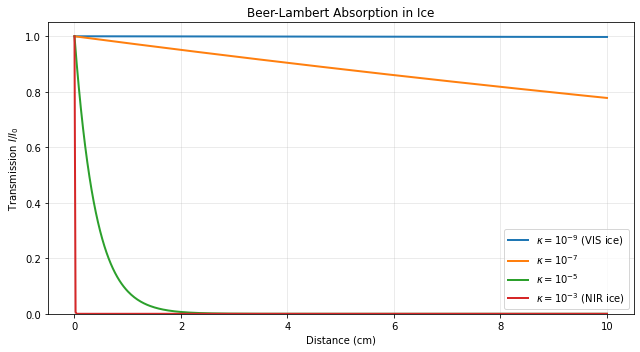

In [2]:
# Beer-Lambert absorption for different imaginary refractive indices

distance = np.linspace(0, 0.1, 500)  # metres
wavelength_example = 0.5e-6  # 500 nm in metres

kappas = [1e-9, 1e-7, 1e-5, 1e-3]
labels = ["$\\kappa = 10^{-9}$ (VIS ice)",
          "$\\kappa = 10^{-7}$",
          "$\\kappa = 10^{-5}$",
          "$\\kappa = 10^{-3}$ (NIR ice)"]

fig, ax = plt.subplots(figsize=(9, 5))
for kappa, label in zip(kappas, labels):
    alpha = 4 * np.pi * kappa / wavelength_example
    ax.plot(distance * 100, np.exp(-alpha * distance), lw=2, label=label)

ax.set_xlabel("Distance (cm)")
ax.set_ylabel("Transmission $I/I_0$")
ax.set_title("Beer-Lambert Absorption in Ice")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


### Reading the Beer-Lambert plot

Each curve shows how the transmitted fraction $I/I_0$ decreases with distance
through ice for a different value of $\kappa$:

- **Blue curve** ($\kappa = 10^{-9}$, typical of VIS wavelengths in ice):
  After 10 cm, essentially 100% of the light survives.  The absorption is
  so weak that a photon could travel 40 metres before losing $1/e$ of its
  intensity.  This is why clean glacier ice can appear blue-green — light
  at these wavelengths penetrates deep into the ice.

- **Orange/green curves** (intermediate $\kappa$): These show progressively
  faster absorption.  At $\kappa = 10^{-5}$, light is significantly attenuated
  within a few centimetres.

- **Red curve** ($\kappa = 10^{-3}$, typical of NIR at 1.5 µm): The light
  is almost completely absorbed within the first millimetre.  At these
  wavelengths, even a single pass through one snow grain ($\sim 200$ µm
  path) absorbs a substantial fraction of the light.

### Everyday consequences

This wavelength dependence of absorption explains several familiar phenomena:

- **Snow is white**: All visible wavelengths are equally (un-)absorbed by ice,
  so no colour is preferentially removed.  The whiteness comes from scattering
  at grain boundaries, not from any intrinsic colour of ice.
- **Glaciers are blue**: In thick ice, the slightly higher absorption of red
  wavelengths compared to blue becomes cumulative over long path lengths.
  After travelling several metres through ice, red light has been
  preferentially absorbed, leaving blue.
- **Snow is dark in NIR satellite imagery**: Cameras sensitive to 1.5 µm see
  snow as almost black because the absorption is so strong.

### A note on notation

You will see $\kappa$ referred to variously as the "imaginary refractive
index", "extinction coefficient", or "absorption index" in different
textbooks.  Some authors use $k$ instead of $\kappa$.  Be careful with
the factor of $4\pi/\lambda$ — some sources define $\alpha$ differently
depending on whether they use wavelength in vacuum or in the medium.
Throughout this notebook we follow the convention
$\alpha = 4\pi\kappa/\lambda_0$ where $\lambda_0$ is the vacuum wavelength.


> **BioSNICAR connection** — The complex refractive index of ice is loaded in
> `biosnicar/classes/ice.py` → `calculate_refractive_index()` (lines 63–102).
> Three datasets are available (Warren 1984, Warren & Brandt 2008, Picard 2016),
> selected by the `RF` parameter in `inputs.yaml`.  The imaginary part
> $\kappa(\lambda)$ feeds into the look-up tables that compute single-particle
> absorption efficiency, which ultimately determines the single-scattering albedo.
> The data is stored in `data/OP_data/480band/rfidx_ice.npz`.


## Section 2 — Scattering by a Single Sphere

### Why does scattering happen?

The Beer-Lambert law (Section 1) describes absorption — the conversion of
light energy into heat.  But in snow, another process is equally important:
**scattering**, the redirection of light into new directions.

Scattering occurs whenever a wave encounters a change in refractive index.
When a plane wave meets a sphere of ice ($n \approx 1.31$) embedded in air
($n = 1.0$), the wave inside the sphere travels at a different speed than the
wave outside.  This mismatch distorts the wavefronts, redirecting some energy
in new directions.

Think of it by analogy: a water wave hitting a submerged rock generates
circular ripples spreading out from the rock.  Similarly, an electromagnetic
wave hitting an ice grain generates scattered waves radiating outward.

### Extinction = scattering + absorption

The total power removed from the incident beam by a particle is called
**extinction**.  It has two components:

$$
\text{Extinction} = \text{Scattering} + \text{Absorption}
$$

- **Scattering**: Light is redirected but not lost — it continues propagating
  in a new direction.  In snow, scattering is what creates the bright
  appearance: photons bounce between grains, and some eventually exit back
  through the surface.
- **Absorption**: Light energy is converted into thermal energy (heat) within
  the particle.  This is an irreversible loss.

### Efficiency factors: $Q_{\text{ext}}$, $Q_{\text{sca}}$, $Q_{\text{abs}}$

We quantify scattering and absorption using **efficiency factors** $Q$,
defined as the ratio of the effective cross-section to the geometric
cross-section $\pi r^2$ of the sphere:

$$
Q_{\text{ext}} = Q_{\text{sca}} + Q_{\text{abs}}, \qquad
\sigma_{\text{ext}} = Q_{\text{ext}} \cdot \pi r^2
$$

For example, if a sphere with radius $r = 100$ µm has $Q_{\text{ext}} = 2$,
its effective extinction cross-section is $2 \times \pi (100\,\mu\text{m})^2$
— it removes twice as much power from the beam as you'd expect from its
physical shadow alone.  (This surprising result is explained below.)

$Q$ values are dimensionless and typically range from 0 to ~4:
- $Q_{\text{ext}} = 0$: Invisible (no interaction with the beam)
- $Q_{\text{ext}} = 2$: Geometric optics limit for large spheres
- $Q_{\text{ext}} > 2$: Possible in the Mie resonance regime (constructive
  interference effects)

### The size parameter: which regime are we in?

The physics of scattering depends critically on the ratio of particle size to
wavelength, captured by the dimensionless **size parameter**:

$$
x = \frac{2\pi r}{\lambda}
$$

This ratio determines whether the particle "looks" small or large to the wave:

| Regime | $x$ | Physical picture | Everyday example |
|--------|-----|-----------------|-----------------|
| **Rayleigh** | $x \ll 1$ | Particle much smaller than $\lambda$; the entire particle oscillates as a dipole in the external field. Scattering $\propto \lambda^{-4}$ (short wavelengths scattered much more). Symmetric forward/backward. | Air molecules scattering sunlight → **blue sky** |
| **Mie resonance** | $x \sim 1$ | Particle comparable to $\lambda$; complex interference between waves diffracted, refracted, and reflected by the particle. Strong forward scattering. | Water droplets in clouds → **white clouds** |
| **Geometric optics** | $x \gg 1$ | Particle much larger than $\lambda$; can be treated as a lens/mirror with rays. $Q_{\text{ext}} \to 2$. Very strong forward scattering. | Raindrops → **rainbows** |

For **snow grains** ($r \sim 50$–$1000\,\mu$m) at visible/NIR wavelengths
($\lambda \sim 0.3$–$2.5\,\mu$m), we have $x \sim 100$–$10{,}000$ — firmly in
the geometric optics regime.  For **impurity particles** like soot
($r \sim 0.04\,\mu$m), $x \sim 0.1$–$1$, placing them in the Rayleigh–Mie
transition — exactly where the physics is most complex.


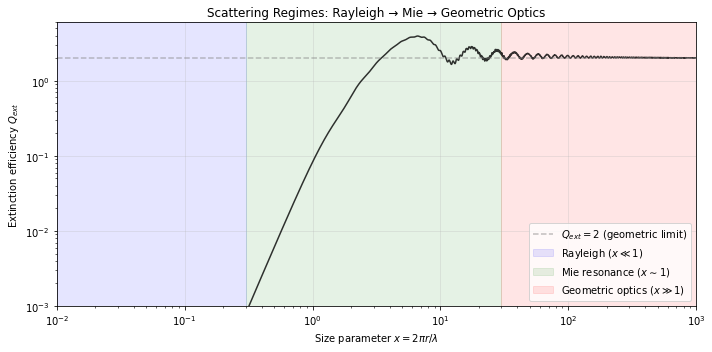

In [3]:
# Qext vs size parameter showing the three regimes

def rayleigh_qext(x, m):
    """Rayleigh-limit extinction efficiency (x << 1)."""
    m2 = m**2
    return x * (4 * np.imag((m2 - 1) / (m2 + 2))
                + (8/3) * x**3 * np.abs((m2 - 1) / (m2 + 2))**2)

x_range = np.logspace(-2, 3, 2000)
m_ice = 1.31 + 1e-6j  # Ice at ~500 nm (very weakly absorbing)

if HAS_MIEPYTHON:
    qext_vals = np.array([miepython.mie(m_ice, xi)[0] for xi in x_range])
else:
    # Rayleigh approximation (accurate for x < ~0.5, qualitative beyond)
    qext_vals = rayleigh_qext(x_range, m_ice)
    qext_vals = np.clip(qext_vals, 0, 4)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(x_range, qext_vals, "k-", lw=1.5, alpha=0.8)
ax.axhline(2, color="gray", ls="--", alpha=0.5, label="$Q_{ext} = 2$ (geometric limit)")
ax.axvspan(0.01, 0.3, alpha=0.1, color="blue", label="Rayleigh ($x \\ll 1$)")
ax.axvspan(0.3, 30, alpha=0.1, color="green", label="Mie resonance ($x \\sim 1$)")
ax.axvspan(30, 1000, alpha=0.1, color="red", label="Geometric optics ($x \\gg 1$)")
ax.set_xlabel("Size parameter $x = 2\\pi r / \\lambda$")
ax.set_ylabel("Extinction efficiency $Q_{ext}$")
ax.set_title("Scattering Regimes: Rayleigh → Mie → Geometric Optics")
ax.legend(loc="lower right")
ax.set_xlim(0.01, 1000)
ax.set_ylim(0.001, 6)
plt.tight_layout()
plt.show()


### Reading the Mie plot

- **Rayleigh regime** (blue shading, $x < 0.3$): $Q_{\text{ext}}$ increases
  steeply with $x$.  In this regime, scattering efficiency grows as $x^4$
  (equivalently, $\lambda^{-4}$).  This is why the sky is blue: air molecules
  have $x \ll 1$ for visible light, and shorter (blue) wavelengths are
  scattered much more efficiently than longer (red) ones.

- **Mie resonance regime** (green shading, $0.3 < x < 30$): The curve shows
  complex oscillations.  These arise from constructive and destructive
  interference between waves that take different paths through the sphere
  (direct transmission, single internal reflection, double internal reflection,
  etc.).  When these paths happen to be in phase, $Q_{\text{ext}}$ peaks;
  when out of phase, it dips.  The oscillation spacing depends on the
  refractive index contrast.

- **Geometric optics regime** (red shading, $x > 30$): The oscillations
  damp out and $Q_{\text{ext}}$ converges to 2.  This seems paradoxical —
  how can a sphere remove *twice* its geometric shadow from a beam?

### The extinction paradox: why $Q_{\text{ext}} = 2$

This is one of the most counter-intuitive results in optics.  A large
sphere removes power from the forward beam via two mechanisms:

1. **Geometric blocking** ($Q = 1$): The sphere physically blocks light
   rays that hit it, casting a geometric shadow.  Some of this light is
   absorbed, some is scattered to the sides and backwards.

2. **Diffraction** ($Q = 1$): Light passing *near* the edge of the sphere
   (but not hitting it) is bent by diffraction.  This redirected light
   is also removed from the forward beam.  The diffraction pattern has
   almost the same cross-section as the geometric shadow.

Together: $Q_{\text{ext}} = 1 + 1 = 2$.  The "missing" half of the extinction
is the diffracted light, which is scattered into a narrow forward cone.
For snow modelling, this means that the diffracted component carries nearly
half the scattered power but is concentrated so close to the forward
direction that it is practically indistinguishable from unscattered light.
This is why the **delta-Eddington correction** (Section 11) is so
important.

### Implications for snow and ice modelling

For **snow grains** ($r \sim 50$–$1000$ µm at VIS/NIR wavelengths), we have
$x \sim 100$–$10{,}000$ — firmly in the geometric optics regime.  Even the
smallest fresh-snow grains have $x \sim 300$.  This means we can use
simplified geometric-optics approximations rather than solving the full Mie
equations — which is fortunate, because Mie codes become numerically
challenging at these large size parameters (tens of thousands of terms in the
series expansion).

**Impurity particles** have much smaller radii and fall into different regimes:
- **Black carbon** ($r \sim 0.04$ µm): $x \sim 0.1$–$1$ → Rayleigh–Mie transition
- **Fine dust** ($r \sim 0.5$–$5$ µm): $x \sim 1$–$30$ → Mie regime
- **Algae cells** ($r \sim 5$–$25$ µm): $x \sim 30$–$300$ → Mie to geometric transition

For these, the full Mie theory must be used.  BioSNICAR pre-computes the
optical properties using validated Mie codes and stores the results in
look-up tables (`lap.npz`).


> **BioSNICAR connection** — BioSNICAR uses pre-computed Mie look-up tables
> rather than solving Mie theory at runtime.  Sphere optical properties are
> retrieved in `biosnicar/optical_properties/op_lookup.py` → `OpLookupTable.get()`.
> For large hexagonal crystals, geometric optics is used instead:
> `biosnicar/optical_properties/van_diedenhoven.py` → `calc_ssa_and_g()`.


## Section 3 — From Mie Theory to Geometric Optics: The Key Outputs

Mie theory (Gustav Mie, 1908) is the exact analytical solution for scattering
and absorption of a plane wave by a homogeneous sphere.  While the full
mathematical machinery involves infinite series of Bessel functions and
Legendre polynomials, we only need four wavelength-dependent outputs.
These are the quantities that feed into the radiative transfer equation.

### The four key quantities

| Symbol | Name | Range | Physical meaning |
|--------|------|-------|-----------------|
| $Q_{\text{ext}}$ | Extinction efficiency | 0 to ~4 | Total power removed from the beam, per unit geometric cross-section |
| $Q_{\text{sca}}$ | Scattering efficiency | 0 to ~4 | Power redirected (but not absorbed) |
| $Q_{\text{abs}}$ | Absorption efficiency | 0 to 2 | Power converted to heat inside the particle |
| $\tilde{\omega}$ | Single-scattering albedo | 0 to 1 | Probability that an extinction event is scattering (not absorption) |
| $g$ | Asymmetry parameter | $-1$ to $+1$ | Average cosine of scattering angle |

These are related by:
$$
Q_{\text{ext}} = Q_{\text{sca}} + Q_{\text{abs}}, \qquad
\tilde{\omega} = \frac{Q_{\text{sca}}}{Q_{\text{ext}}}
$$

### Understanding single-scattering albedo ($\tilde{\omega}$)

This is perhaps the most important quantity in snow optics.  Think of each
time a photon interacts with a grain as a coin flip:

- With probability $\tilde{\omega}$, the photon **scatters** — it bounces off
  in a new direction, still alive.
- With probability $1 - \tilde{\omega}$, the photon is **absorbed** — its
  energy is converted to heat, and it is removed from the radiation field.

For snow grains in the **visible**: $\tilde{\omega} \approx 0.999\,99$.
This means only about 1 in 100,000 scattering events results in
absorption.  A photon can scatter thousands of times between grains and
still have a high probability of escaping back out through the surface.

For snow grains in the **NIR** (say 1.5 µm): $\tilde{\omega}$ drops to
perhaps 0.95–0.99 for fine grains, or 0.5–0.9 for coarse grains.
Now each interaction carries a significant risk of absorption, and a photon
that scatters just 10–20 times is likely to be absorbed.

### Understanding the asymmetry parameter ($g$)

When a photon scatters, it doesn't go in a random direction.  The
**phase function** $P(\cos\theta)$ describes the probability of scattering
into each angle $\theta$ relative to the original direction.  The asymmetry
parameter $g$ is the average of $\cos\theta$ over this distribution:

$$
g = \langle \cos\theta \rangle = \frac{1}{2} \int_{-1}^{1} P(\cos\theta) \cos\theta \, d(\cos\theta)
$$

- $g = 0$: **Isotropic** scattering — equal probability of going forward,
  sideways, or backward.
- $g = +1$: Perfect **forward** scattering — all light continues in the
  original direction (as if nothing happened).
- $g = -1$: Perfect **backward** scattering (reflection).

For snow grains: $g \approx 0.85$–$0.9$.  This extreme forward bias means
that when a photon scatters off an ice grain, it mostly continues in roughly
the same direction.  Only a small fraction of scattering events meaningfully
redirect the photon.  This is why the **delta-Eddington correction**
(Section 11) is essential — it accounts for the fact that much of the
nominal "scattering" is really just forward transmission.

A common approximation for the phase function is the **Henyey-Greenstein**
(HG) function:

$$
P_{\text{HG}}(\cos\theta) = \frac{1 - g^2}{(1 + g^2 - 2g\cos\theta)^{3/2}}
$$

This has the nice property that its single parameter $g$ fully specifies
the angular distribution.  While not exact for ice crystals (the real phase
function has more complex structure), it captures the essential forward bias.

### Why geometric optics, not exact Mie?

Snow grains have radii of 50–1000 µm, giving size parameters $x = 2\pi r/\lambda$
of 100–20,000 in the VIS/NIR.  At these huge $x$:

- Exact Mie codes become **numerically unstable** (the Bessel function series
  requires $\sim x$ terms, each involving ratios of very large numbers that
  overflow standard floating-point arithmetic).
- The physics simplifies enormously: $Q_{\text{ext}} \to 2$ (the extinction
  paradox from Section 2), and absorption follows Beer-Lambert through the
  mean path length inside the sphere.
- BioSNICAR's own look-up tables are built from **validated Mie codes** written in
  Fortran with extended precision — not from Python packages.  For our toy model,
  the geometric optics approximation is more physically faithful.

### The geometric optics limit

In this regime, we can think of the photon as a ray that enters the sphere,
travels through absorbing ice, and exits.  The **mean path length** through
a sphere of radius $r$ (averaged over all impact parameters) is:

$$
\langle l \rangle = \frac{4}{3} r
$$

Using Beer-Lambert, the fraction of light absorbed in this traversal is:

$$
f_{\text{abs}} = 1 - e^{-\alpha \langle l \rangle}
= 1 - \exp\!\left(-\frac{4\pi\kappa}{\lambda} \cdot \frac{4r}{3}\right)
$$

The absorption efficiency and SSA are then:

$$
Q_{\text{abs}} = 2 f_{\text{abs}}, \qquad
Q_{\text{sca}} = 2(1 - f_{\text{abs}}), \qquad
\tilde{\omega} = 1 - f_{\text{abs}}
$$

(The factor of 2 comes from $Q_{\text{ext}} = 2$ normalisation.)

This simple formula connects all the physics we've built up: the imaginary
refractive index $\kappa(\lambda)$ from Section 1, the extinction paradox
from Section 2, and the Beer-Lambert law — all combined to give us the SSA
that controls snow albedo.


In [4]:
# Optical property calculations for ice spheres

_mie_cache = {}

def mie_sphere(radius_um, wavelength_um, n_re, n_im):
    """Compute extinction, SSA, and g for an ice sphere at each wavelength.

    Snow/ice grains have size parameters x = 2πr/λ in the range 100–20,000,
    far into the geometric optics regime.  Standard Mie codes (including
    miepython) become numerically unstable at these large x values, producing
    unphysical results (Qsca > Qext).

    We therefore use the **geometric optics approximation**:
    - Qext = 2 (extinction paradox — diffraction doubles the geometric shadow)
    - Qabs from Beer-Lambert absorption through the mean path length ⟨l⟩ = 4r/3
    - Qsca = Qext - Qabs
    - g ≈ 0.89 (typical for large ice spheres; weakly wavelength-dependent)

    This is the same physics encoded in BioSNICAR's pre-computed look-up tables.
    """
    cache_key = (radius_um, len(wavelength_um), wavelength_um[0], wavelength_um[-1])
    if cache_key in _mie_cache:
        return _mie_cache[cache_key]

    # Geometric optics for ice grains
    qext = np.full_like(wavelength_um, 2.0)

    # Mean photon path through a sphere: ⟨l⟩ = (4/3) r
    mean_path_m = (4.0 / 3.0) * radius_um * 1e-6

    # Absorption coefficient from imaginary refractive index
    alpha = 4 * np.pi * n_im / (wavelength_um * 1e-6)  # m⁻¹

    # Fraction absorbed in one traversal (Beer-Lambert)
    absorb_frac = 1.0 - np.exp(-alpha * mean_path_m)
    absorb_frac = np.clip(absorb_frac, 0, 1)

    # Absorption efficiency ≈ absorption fraction (in geometric limit)
    qabs = 2.0 * absorb_frac  # factor 2 from Qext normalisation
    qabs = np.minimum(qabs, qext)  # cannot exceed extinction

    qsca = qext - qabs
    ssa = qsca / qext  # always ∈ [0, 1]

    # Asymmetry parameter: large ice spheres are strongly forward-scattering
    # Weakly wavelength-dependent; increases slightly with absorption
    g = 0.89 - 0.02 * absorb_frac  # slight decrease as absorption grows

    result = (qext, qsca, qabs, ssa, g)
    _mie_cache[cache_key] = result
    return result


# Approximate ice refractive index (analytical, used until we load real data)
def ice_ri_approx(wavelength_um):
    """Simplified ice refractive index: n(λ) and k(λ).

    Real part: ~1.31 with slight dispersion.
    Imaginary part: very low in VIS, rising steeply in NIR.
    Based on Warren & Brandt (2008) but simplified analytically.
    """
    n_re = 1.31 - 0.005 * (wavelength_um - 0.5)
    # Piecewise log-linear approximation of k(λ)
    ln_k = np.where(
        wavelength_um < 0.6,
        -21 + 3 * (wavelength_um - 0.3),
        np.where(
            wavelength_um < 1.5,
            -20 + 12 * (wavelength_um - 0.6),
            -9 + 2 * (wavelength_um - 1.5)
        )
    )
    n_im = np.exp(ln_k)
    # Add absorption band features around 1.5 and 2.0 µm
    n_im += 5e-4 * np.exp(-((wavelength_um - 1.5) / 0.08)**2)
    n_im += 2e-3 * np.exp(-((wavelength_um - 2.0) / 0.1)**2)
    return n_re, n_im

print("Optical property functions defined.")


Optical property functions defined.


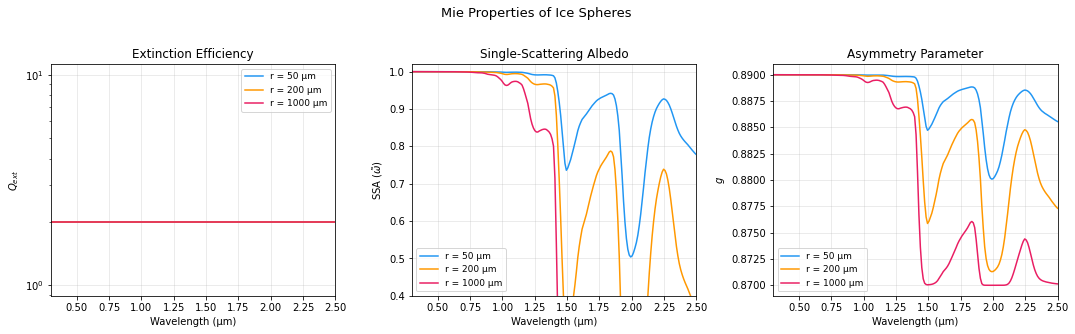

In [5]:
# 3-panel figure: Qext, SSA, g vs wavelength for ice spheres
# Uses N_RE, N_IM (real ice RI on WVL_FAST grid, loaded in setup cell)

radii = [50, 200, 1000]  # µm
colors = ["#2196F3", "#FF9800", "#E91E63"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for r, c in zip(radii, colors):
    qext, qsca, qabs, ssa, g = mie_sphere(r, WVL_FAST, N_RE, N_IM)
    axes[0].semilogy(WVL_FAST, qext, color=c, lw=1.5, label=f"r = {r} µm")
    axes[1].plot(WVL_FAST, ssa, color=c, lw=1.5, label=f"r = {r} µm")
    axes[2].plot(WVL_FAST, g, color=c, lw=1.5, label=f"r = {r} µm")

axes[0].set_ylabel("$Q_{ext}$")
axes[0].set_title("Extinction Efficiency")
axes[0].set_xlim(0.3, 2.5)
axes[1].set_ylabel("SSA ($\\tilde{\\omega}$)")
axes[1].set_title("Single-Scattering Albedo")
axes[1].set_ylim(0.4, 1.02)
axes[1].set_xlim(0.3, 2.5)
axes[2].set_ylabel("$g$")
axes[2].set_title("Asymmetry Parameter")
axes[2].set_xlim(0.3, 2.5)

for ax in axes:
    ax.set_xlabel("Wavelength (µm)")
    ax.legend(fontsize=9)

fig.suptitle("Mie Properties of Ice Spheres", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Key observations:

- **Larger grains** have lower SSA in the NIR — more absorption per scattering
  event because photons travel further inside the particle.  The mean path
  length through a sphere is $\langle l \rangle = 4r/3$, so doubling the grain
  radius doubles the absorption per scattering event.
- **SSA ≈ 1** in the visible for all grain sizes — ice barely absorbs at these
  wavelengths, so virtually all extinction is due to scattering.
- **$g \approx 0.87$–$0.89$** for snow-sized grains — strongly forward-scattering.
  This means ~97% of scattered power goes into the forward hemisphere.
- **$Q_{\text{ext}} = 2$** for all grain sizes (geometric limit) — the extinction
  cross-section is always twice the geometric cross-section.

These three quantities ($Q_{\text{ext}}$, $\tilde{\omega}$, $g$) are the fundamental
inputs to the radiative transfer equation.  Everything else — albedo, absorbed
flux, transmitted flux — follows from them and the layer geometry.

The key physical insight is that **grain size controls absorption through path
length**: a photon traversing a 1000 µm grain travels 20× further through
absorbing ice than one traversing a 50 µm grain, so it has a much higher
probability of being absorbed before being scattered back out.  In the visible,
where $\kappa \sim 10^{-9}$, even the longest path is negligible, so SSA ≈ 1
regardless of grain size.  In the NIR, where $\kappa \sim 10^{-4}$, the
path length matters enormously.


> **BioSNICAR connection** — Pre-computed Mie efficiencies for ice spheres are
> stored in look-up tables loaded by `biosnicar/optical_properties/op_lookup.py`.
> The LUTs contain $Q_{\text{ext}}$, $\tilde{\omega}$ (`ss_alb`), $g$ (`asm_prm`),
> and the mass extinction coefficient (`ext_cff_mss`) as functions of grain
> radius and wavelength.


## Section 4 — The Refractive Index of Ice

### Why the refractive index is the master variable

Everything we've built so far — Beer-Lambert absorption, Mie scattering
efficiencies, the geometric optics approximation — depends on a single
material property: the **complex refractive index** of ice,
$\tilde{n}(\lambda) = n(\lambda) + i\kappa(\lambda)$.

This function encodes the entire optical character of ice:
- How fast light travels through it ($n$, the real part → refraction and
  scattering)
- How quickly light is absorbed ($\kappa$, the imaginary part → absorption)

If you know $\tilde{n}(\lambda)$ at all wavelengths, you can compute every
optical property of ice grains at every wavelength.  The refractive index
is where **molecular physics meets optics**: the values of $n$ and $\kappa$
arise from how the H₂O molecules in the ice crystal lattice respond to
electromagnetic radiation.

### What determines $\kappa(\lambda)$?

The imaginary part of the refractive index is controlled by the
**molecular vibrations** of water molecules in the ice lattice:

- **O-H stretching modes** (fundamental near 3.1 µm, $\sim 3200$ cm$^{-1}$):
  The hydrogen atoms vibrate back and forth along the O-H bond.  This
  requires energy that matches the frequency of ~3 µm infrared light,
  creating the strongest absorption band in ice.
- **Overtone and combination bands** (1.5 µm, 2.0 µm): The 1.5 µm band is an
  overtone (approximately twice the fundamental frequency), while the 2.0 µm
  band is a combination band (O-H stretch + bend excited simultaneously).
  Both are weaker than the fundamental but still strong enough
  to make snow dark in the NIR.
- **Combination bands** (1.03 µm): Result from two different vibrational
  modes being excited simultaneously.  Weaker still, but detectable.
- **Electronic transitions** (UV, <0.2 µm): At very short wavelengths,
  the photon has enough energy to excite electronic transitions in the
  water molecule, causing UV absorption.
- **Visible window** (0.4–0.7 µm): There are no molecular vibrations or
  electronic transitions at these frequencies, so $\kappa$ is extraordinarily
  small ($\sim 10^{-9}$).  Ice is one of the most transparent materials
  known at visible wavelengths.

### Measurement datasets

Measuring $\kappa$ across its 10-order-of-magnitude range is experimentally
challenging.  Different regions require different techniques: thin-film
transmission for the VIS (where absorption is tiny), reflection spectroscopy
for the NIR (where absorption is strong).  BioSNICAR offers three
compilations:

| Code | Source | Notes |
|------|--------|-------|
| `Wrn84` | Warren (1984) | Classic reference, widely used |
| `Wrn08` | Warren & Brandt (2008) | Improved NIR absorption bands |
| `Pic16` | Picard et al. (2016) | Further NIR refinements |

The **real part** $n \approx 1.31$ varies slowly with wavelength (slight
dispersion — $n$ is higher at shorter wavelengths, causing the separation of
colours in ice prisms).  The **imaginary part** $\kappa$ spans from
$\sim 10^{-11}$ in the UV to $\sim 1$ at 3 µm.


In [6]:
# Load ALL available ice RI datasets for comparison plotting.
# N_RE, N_IM (the primary dataset on WVL_FAST) were already loaded in the
# setup cell.  Here we load the full 480-band datasets for the RI comparison
# plot below.

def load_ice_ri_datasets():
    """Load all available ice RI datasets from BioSNICAR for comparison."""
    if DATA_DIR is not None:
        fpath = DATA_DIR / "OP_data" / "480band" / "rfidx_ice.npz"
        if fpath.is_file():
            data = np.load(fpath)
            wvl = data["wvl"]
            datasets = {}
            for name in ["Wrn84", "Wrn08", "Pic16"]:
                re_key = f"re_{name}"
                im_key = f"im_{name}"
                if re_key in data and im_key in data:
                    datasets[name] = (data[re_key], data[im_key])
            if datasets:
                print(f"RI datasets available: {list(datasets.keys())}")
                return wvl, datasets
    # Fallback
    print("Using analytical approximation for ice RI comparison.")
    n_re, n_im = _ice_ri_approx_setup(WAVELENGTH)
    return WAVELENGTH, {"Approx": (n_re, n_im)}

WVL_ICE, ICE_RI = load_ice_ri_datasets()


RI datasets available: ['Wrn84', 'Wrn08', 'Pic16']


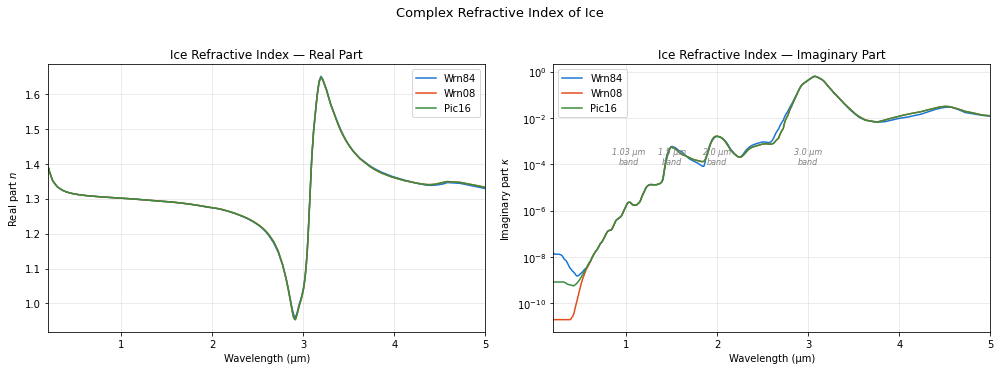

In [7]:
# Plot n(λ) and k(λ) for ice

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_ri = {"Wrn84": "#1976D2", "Wrn08": "#E64A19", "Pic16": "#388E3C", "Approx": "black"}

for name, (n_re, n_im) in ICE_RI.items():
    c = colors_ri.get(name, "gray")
    ax1.plot(WVL_ICE, n_re, color=c, lw=1.5, label=name)
    ax2.semilogy(WVL_ICE, np.maximum(n_im, 1e-15), color=c, lw=1.5, label=name)

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Real part $n$")
ax1.set_title("Ice Refractive Index — Real Part")
ax1.set_xlim(0.2, 5.0)
ax1.legend()

ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Imaginary part $\\kappa$")
ax2.set_title("Ice Refractive Index — Imaginary Part")
ax2.set_xlim(0.2, 5.0)
ax2.legend()

# Annotate key absorption features
if "Wrn08" in ICE_RI or "Approx" in ICE_RI:
    for wv, label in [(1.03, "1.03 µm\nband"), (1.5, "1.5 µm\nband"),
                       (2.0, "2.0 µm\nband"), (3.0, "3.0 µm\nband")]:
        if wv <= WVL_ICE[-1]:
            ax2.annotate(label, xy=(wv, 1e-4), fontsize=8, ha="center",
                         color="gray", style="italic")

fig.suptitle("Complex Refractive Index of Ice", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


The imaginary part $\kappa(\lambda)$ has a striking structure:

- **UV/blue (0.2–0.5 µm)**: $\kappa \sim 10^{-11}$ — ice is essentially transparent.
  A photon could travel hundreds of metres through pure ice at these wavelengths.
- **Red (0.6–0.7 µm)**: $\kappa$ starts to rise slightly — this is why deep ice
  and glacial meltwater pools appear blue (red photons are preferentially absorbed).
- **Near-IR (1–2.5 µm)**: Strong absorption bands at 1.03, 1.5, and 2.0 µm.
  These correspond to **overtone and combination bands** of the O-H stretching
  vibration (fundamental at 3.0 µm).  The 1.03 µm band is weak but detectable;
  the 1.5 and 2.0 µm bands are strong enough to make snow nearly black.
- **Mid-IR (>3 µm)**: $\kappa \to 1$ — ice is nearly opaque.  The fundamental
  O-H stretch at 3.0 µm is extremely strong.

The huge dynamic range of $\kappa$ (spanning 10 orders of magnitude) is why
snow reflectance varies so dramatically with wavelength.  It is also why
**different wavelengths probe different depths** in a snowpack: blue light
penetrates centimetres to metres, while 1.5 µm light is absorbed in the
top millimetre.

The three datasets (Warren 1984, Warren & Brandt 2008, Picard 2016) differ
mainly in the NIR, where more precise measurements have refined the absorption
band shapes.  The differences are small but matter for quantitative retrievals.

> **BioSNICAR connection** — `biosnicar/classes/ice.py:63–102` →
> `calculate_refractive_index()` loads these datasets from
> `data/OP_data/480band/rfidx_ice.npz`.  The key arrays are named
> `re_Wrn08` and `im_Wrn08` (for Warren & Brandt 2008, etc.).
> The choice of dataset is controlled by the `RF` parameter in `inputs.yaml`
> (0 = Wrn84, 1 = Wrn08, 2 = Pic16).  The same file also provides
> pre-computed diffuse Fresnel reflectances used in the adding-doubling solver.


---
# Act II: From Single Particles to Bulk Properties

## Section 5 — From Single-Particle Mie to Bulk Optical Properties

A snowpack is not one sphere — it is a collection of $\sim 10^{12}$ grains
per cubic metre.  We need to convert single-particle Mie efficiencies into
**bulk medium optical properties**.

For a collection of identical spheres with radius $r$, density $\rho_{\text{ice}} = 917$ kg/m³:

**Mass extinction coefficient** (m² kg⁻¹):
$$
\text{MAC} = \frac{3\, Q_{\text{ext}}}{4\, r\, \rho_{\text{ice}}}
$$

This tells us the optical depth per unit mass path.

**Single-scattering albedo** of the bulk medium equals the single-particle SSA:
$$
\tilde{\omega} = \frac{Q_{\text{sca}}}{Q_{\text{ext}}}
$$

**Asymmetry parameter** of the bulk also equals the single-particle $g$ (for
identical spheres).

### Intuitive picture: why grain size controls NIR albedo

Think of a photon entering a snowpack as a random walk.  At each grain, the
photon either **scatters** (probability $\tilde{\omega}$) or is **absorbed**
(probability $1 - \tilde{\omega}$).  The absorption probability per grain
depends on how far the photon travels through ice before exiting — and that
distance is proportional to the grain radius: $\langle l \rangle = 4r/3$.

Consider the journey of a photon in the NIR (say 1.5 µm, where ice absorbs):
- **Small grain** ($r = 50$ µm): Path through ice ≈ 67 µm.  With the imaginary
  refractive index $\kappa \sim 4 \times 10^{-4}$ at 1.5 µm, the absorption per traversal is
  $\alpha \cdot l \sim 4\pi\kappa/(\lambda) \cdot l \approx 0.22$.  Using geometric optics
  ($Q_{\text{abs}} \approx 1 - e^{-\alpha l}$, $\tilde{\omega} = 1 - Q_{\text{abs}}/2$),
  we get $\tilde{\omega} \approx 0.90$ → the photon
  scatters many times and has a good chance of escaping back out.
- **Large grain** ($r = 1000$ µm): Path ≈ 1333 µm.  Absorption per traversal
  is 20× larger → $\tilde{\omega} \approx 0.51$ → the photon is absorbed
  within a few scattering events → the snow is dark.

In the **visible** (0.5 µm), $\kappa \sim 10^{-9}$, so the absorption per
traversal is negligible regardless of grain size.  The photon scatters
hundreds of times and almost always escapes → $\tilde{\omega} \approx 1.0$,
albedo ≈ 1.0 for all grain sizes.

This explains the fundamental spectral shape of snow: **bright in the visible,
dark in the NIR, with grain size controlling the NIR**.

Snow metamorphism — the process by which snow grains grow and round over
time — is therefore an **optical ageing process**.  Temperature gradients,
melt-refreeze cycles, and wind packing all increase the effective grain size,
darkening the snow in the NIR and reducing its albedo.  This creates a
positive feedback: darker snow absorbs more energy, which accelerates
metamorphism, which further darkens the snow.

The **mass extinction coefficient** (MAC = $3 Q_{\text{ext}} / 4r\rho$) also
decreases with grain size as $1/r$, because larger particles intercept
the same fraction of a beam with fewer particles per unit mass.  This means
that per kilogram, fine snow is a more efficient scatterer than coarse snow.


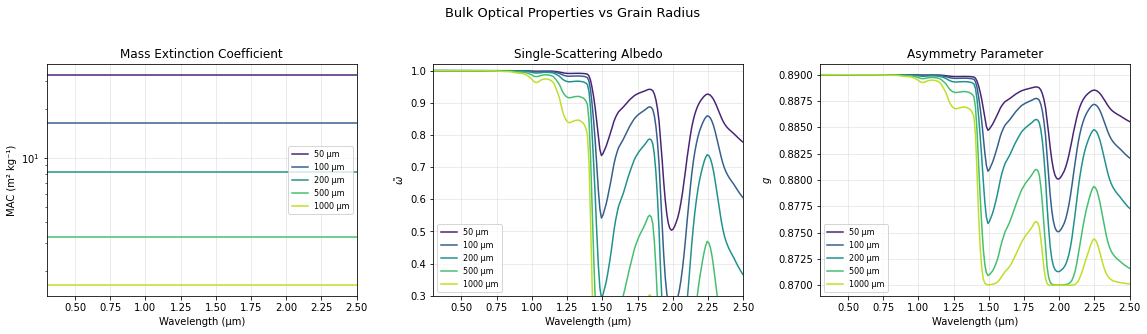

In [8]:
# Bulk optical properties for different grain radii
# N_RE, N_IM, RHO_ICE were all loaded in the setup cell

grain_radii = [50, 100, 200, 500, 1000]  # µm
colors_grain = plt.cm.viridis(np.linspace(0.1, 0.9, len(grain_radii)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for r, c in zip(grain_radii, colors_grain):
    qext, qsca, qabs, ssa, g = mie_sphere(r, WVL_FAST, N_RE, N_IM)
    mac = 3 * qext / (4 * r * 1e-6 * RHO_ICE)  # m² kg⁻¹ (r in metres)

    axes[0].semilogy(WVL_FAST, mac, color=c, lw=1.5, label=f"{r} µm")
    axes[1].plot(WVL_FAST, ssa, color=c, lw=1.5, label=f"{r} µm")
    axes[2].plot(WVL_FAST, g, color=c, lw=1.5, label=f"{r} µm")

axes[0].set_ylabel("MAC (m² kg⁻¹)")
axes[0].set_title("Mass Extinction Coefficient")
axes[1].set_ylabel("$\\tilde{\\omega}$")
axes[1].set_title("Single-Scattering Albedo")
axes[1].set_ylim(0.3, 1.02)
axes[2].set_ylabel("$g$")
axes[2].set_title("Asymmetry Parameter")

for ax in axes:
    ax.set_xlabel("Wavelength (µm)")
    ax.set_xlim(0.3, 2.5)
    ax.legend(fontsize=8)

fig.suptitle("Bulk Optical Properties vs Grain Radius", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


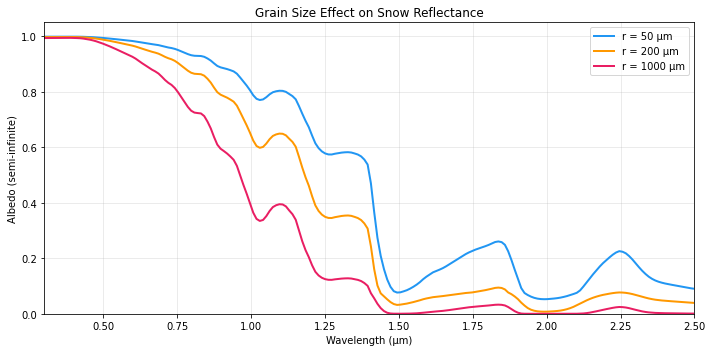

In [9]:
# Demonstrate how grain size controls reflectance
# Use the semi-infinite two-stream approximation (defined properly below in Sec 7,
# but we preview it here to show the grain-size effect)

def _semi_inf_direct(ws, gs, mu0):
    """Semi-infinite albedo for direct beam (Briegleb 1992).

    Takes delta-scaled single-scattering albedo (ws) and asymmetry
    parameter (gs).  Returns direct-beam reflectance.
    """
    ws = np.minimum(ws, 1 - 1e-12)
    lm = np.sqrt(np.maximum(3 * (1 - ws) * (1 - ws * gs), 0))
    with np.errstate(divide="ignore", invalid="ignore"):
        ue = np.where(lm > 1e-30, 1.5 * (1 - ws * gs) / lm, 0.0)
    # Semi-infinite diffuse reflectance: rdif = (ue-1)/(ue+1) as tau -> inf
    rdif_inf = np.where(ue > 1, (ue - 1) / (ue + 1), 0.0)
    # Direct beam correction
    eps = 1e-10
    dd = 1 - lm**2 * mu0**2 + eps
    alp = 0.75 * ws * mu0 * (1 + gs * (1 - ws)) / dd
    gam_c = 0.5 * ws * (1 + 3 * gs * mu0**2 * (1 - ws)) / dd
    rdir_inf = (alp + gam_c) * rdif_inf - (alp - gam_c)
    return np.clip(rdir_inf, 0, 1), np.clip(rdif_inf, 0, 1)

def _preview_albedo(radius_um, wavelength, n_re, n_im, mu0=0.5):
    """Semi-infinite albedo for direct beam using Briegleb (1992)."""
    qext, qsca, qabs, ssa, g = mie_sphere(radius_um, wavelength, n_re, n_im)
    f = g**2
    ws = ssa * (1 - f) / np.maximum(1 - ssa * f, 1e-30)
    gs = g / (1 + g)
    rdir, _ = _semi_inf_direct(ws, gs, mu0)
    return rdir

fig, ax = plt.subplots(figsize=(10, 5))
for r, c in zip([50, 200, 1000], ["#2196F3", "#FF9800", "#E91E63"]):
    alb = _preview_albedo(r, WVL_FAST, N_RE, N_IM)
    ax.plot(WVL_FAST, alb, color=c, lw=2, label=f"r = {r} µm")

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Albedo (semi-infinite)")
ax.set_title("Grain Size Effect on Snow Reflectance")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


Key physics from the three panels:

### MAC is nearly wavelength-independent — why?

The left panel shows something surprising: MAC is essentially **flat** across
all wavelengths.  This is because of the extinction paradox from Section 2.

For ice grains with radii $r = 50$–1000 µm, the size parameter $x = 2\pi r/\lambda$
is always very large ($x \gg 1$) — even at $\lambda = 2.5$ µm, a 50 µm grain has
$x \approx 125$.  In this geometric optics limit, $Q_{\text{ext}} \approx 2$
at all wavelengths (geometric blocking + diffraction).  So:

$$
\text{MAC} = \frac{3 Q_{\text{ext}}}{4 r \rho_{\text{ice}}} \approx \frac{3 \times 2}{4 r \rho_{\text{ice}}} = \frac{3}{2 r \rho_{\text{ice}}}
$$

This depends only on grain radius, not wavelength.  A 100 µm grain always
extincts light at ~16 m² kg⁻¹ regardless of whether it's blue or infrared
light.

**So where does the wavelength dependence come from?**  Not from extinction,
but from the **split between scattering and absorption**.  The middle and
right panels reveal the answer:

- **SSA** ($\tilde{\omega}$) varies dramatically with wavelength: near 1.0
  in the VIS (almost all extinction is scattering) and dropping to 0.4–0.95
  in the NIR (significant absorption).  This is controlled by $\kappa(\lambda)$.
- **$g$** also varies, mainly through absorption's effect on the angular
  distribution of scattered light.

So while every grain removes the same total amount of light from the beam
(MAC is flat), what happens to that light — scattered vs absorbed — depends
strongly on wavelength through the imaginary refractive index.

### Grain size effects

- **Visible (0.3–0.7 µm)**: SSA ≈ 1 for all grain sizes → reflectance ≈ 1.
  Grain size has almost no effect because ice barely absorbs.
- **NIR (1.0–2.5 µm)**: Larger grains → lower SSA → darker snow.  The
  absorption bands at 1.03, 1.5, and 2.0 µm are clearly visible.
- **MAC decreases** with radius as $1/r$ — larger particles have more mass
  per unit cross-sectional area, so they are less efficient extinctors per
  unit mass.

This grain-size sensitivity in the NIR is the basis of **remote sensing
of snow grain size** from satellite observations.

> **BioSNICAR connection** — `biosnicar/optical_properties/column_OPs.py:91–124`
> → `get_layer_OPs()` retrieves MAC, SSA, and $g$ from look-up tables indexed
> by grain radius.  The MAC formula $3 Q_{\text{ext}} / (4\, r\, \rho)$ is
> embedded in the LUT values.


## Section 6 — Grain Shape Effects

### The sphere approximation and its limits

Everything so far has assumed snow grains are perfect spheres.  In reality,
freshly fallen snow crystals are hexagonal plates, stellar dendrites, columns,
or needle-like structures.  Even after metamorphism rounds the grains,
they remain irregular.  Why does shape matter?

The key idea is that grain shape changes the **internal path length
distribution** and the **scattering phase function**.  Recall from Section 3
that the absorption efficiency depends on the mean path length through
the particle: $\langle l \rangle = 4r/3$ for a sphere.  For non-spherical
particles, the mean path is different.  A thin plate has a shorter mean
path (less absorption per interaction) than a sphere of the same volume.
A long needle has a longer one.

More importantly, shape affects $g$.  A sphere has a very smooth, symmetric
internal geometry that produces strong forward scattering.  Non-spherical
crystals with flat faces, edges, and corners create more complex internal
reflections that redirect light to wider angles.  This **reduces** $g$
(making scattering more isotropic), which **increases** albedo because
more photons are scattered back upward.

### Why it matters — but not as much as grain size

Shape effects on albedo are typically 1–5% (a few hundredths of albedo)
— significant for precise retrievals from satellite data, but secondary
compared to grain size (which can change albedo by 0.3 or more in the NIR).
The reason is that shape changes $g$ by perhaps 0.05–0.10, whereas grain
size changes $\tilde{\omega}$ by 0.5 or more in the NIR.  Since $\tilde{\omega}$
controls the probability of absorption per event, it has a stronger effect
on the final albedo than the angular redistribution controlled by $g$.

### How BioSNICAR represents shape

BioSNICAR offers several shape representations, using the `shp` parameter:

| `shp` | Shape | Method | Best for |
|--------|-------|--------|----------|
| 0 | Sphere | Mie theory | Aged, rounded grains |
| 1 | Sphere + asphericity correction | Mie + He et al. (2017) | General purpose |
| 2 | Spheroid + correction | As above | Slightly non-spherical |
| 3 | Koch snowflake + correction | As above | Complex fractal shapes |
| 4 | Hexagonal prism | Geometric optics (van Diedenhoven) | Fresh crystals |

The asphericity corrections work by adjusting $g$ downward for non-spherical
particles while keeping $\tilde{\omega}$ unchanged.  For hexagonal prisms
(shape 4), a full geometric optics calculation is used, parameterised by
the crystal's aspect ratio (side length to length ratio).


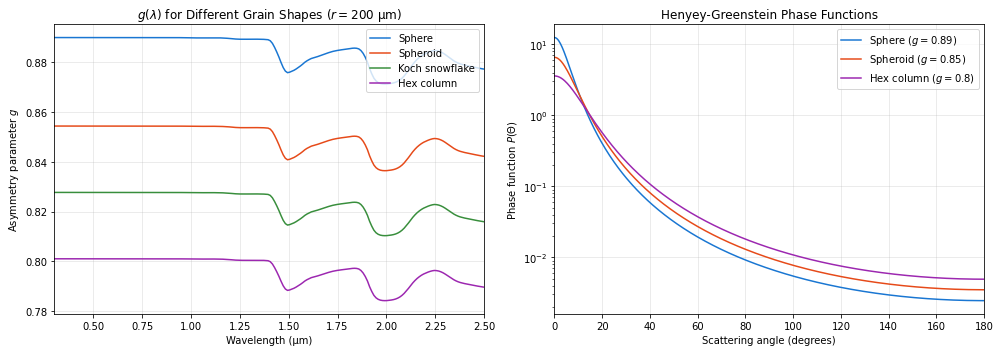

In [10]:
# Demonstrate asymmetry parameter corrections for different shapes

# He et al. (2017) asphericity correction for g
# Reduces g (less forward scattering) for non-spherical particles
def asphericity_correction(g_sphere, ssa, shape_factor=0.95):
    """Apply asphericity correction to reduce g for non-spherical particles.

    shape_factor: 1.0 = sphere (no correction), lower = more aspherical.
    He et al. (2017) parameterisation simplified.
    """
    g_corrected = g_sphere * shape_factor
    return g_corrected

# Phase function comparison (Henyey-Greenstein approximation)
theta = np.linspace(0, np.pi, 500)
cos_theta = np.cos(theta)

def hg_phase(cos_theta, g):
    """Henyey-Greenstein phase function."""
    return (1 - g**2) / (1 + g**2 - 2*g*cos_theta)**1.5 / (4 * np.pi)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: g(λ) for different shapes
r = 200  # µm
qext, qsca, qabs, ssa, g_sphere = mie_sphere(r, WVL_FAST, N_RE, N_IM)

shapes = {"Sphere": 1.0, "Spheroid": 0.96, "Koch snowflake": 0.93, "Hex column": 0.90}
shape_colors = ["#1976D2", "#E64A19", "#388E3C", "#9C27B0"]

for (name, sf), c in zip(shapes.items(), shape_colors):
    g_adj = asphericity_correction(g_sphere, ssa, sf)
    ax1.plot(WVL_FAST, g_adj, color=c, lw=1.5, label=name)

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Asymmetry parameter $g$")
ax1.set_title("$g(\\lambda)$ for Different Grain Shapes ($r = 200$ µm)")
ax1.set_xlim(0.3, 2.5)
ax1.legend()

# Right: Phase functions
for g_val, name, c in [(0.89, "Sphere", "#1976D2"),
                         (0.85, "Spheroid", "#E64A19"),
                         (0.80, "Hex column", "#9C27B0")]:
    p = hg_phase(cos_theta, g_val)
    ax2.semilogy(np.degrees(theta), p, color=c, lw=1.5, label=f"{name} ($g={g_val}$)")

ax2.set_xlabel("Scattering angle (degrees)")
ax2.set_ylabel("Phase function $P(\\Theta)$")
ax2.set_title("Henyey-Greenstein Phase Functions")
ax2.legend()
ax2.set_xlim(0, 180)

plt.tight_layout()
plt.show()


The forward-scattering peak is dramatically reduced as particles become less
spherical.  This has a measurable effect on albedo — non-spherical grains are
slightly brighter because more light is scattered sideways and backwards.

In practice, the shape effect on albedo is modest (a few percent) compared
to the grain size effect, but it matters for precise retrievals.

> **BioSNICAR connection** — Asphericity corrections are applied in
> `biosnicar/optical_properties/column_OPs.py` → `correct_for_asphericity()`
> for shapes 1–3.  Hexagonal prisms (shape 4) use a separate geometric optics
> LUT from `biosnicar/optical_properties/van_diedenhoven.py`.


> **Exercise**: Try changing the `shape_factor` values above and observe how
> the phase function forward peak changes.  What happens to the albedo of a
> Koch snowflake vs a sphere for the same grain size?


## Section 7 — Ice Physical Configuration: Snow vs Bubbly Ice

BioSNICAR handles two fundamentally different ice configurations:

| `layer_type` | Material | Scatterers | Key parameters |
|------|----------|------------|----------------|
| 0 | Granular snow/firn | Ice grains in air | Grain radius, snow density |
| 1 | Solid bubbly ice | Air bubbles in ice | Bubble radius, ice density |

**Granular snow** (type 0): Scattering occurs at grain boundaries where the
refractive index jumps from ice (n ≈ 1.31) to air (n = 1).  The grain radius
determines the optical properties via Mie theory.

**Bubbly ice** (type 1): The matrix is solid ice, and scattering occurs at
air inclusions (bubbles).  Here the bubble radius and ice density (which
determines the bubble volume fraction) control the optics.

The transition from snow to ice (firn densification) is a continuum, but
optically the key variable is the **specific surface area (SSA)** — the
total ice-air interface area per unit mass.  Higher SSA means more scattering,
which increases albedo.


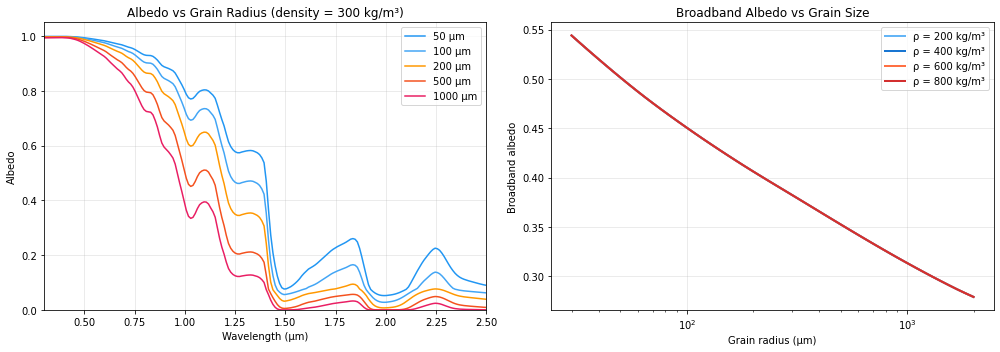

In [11]:
# Albedo vs grain size and density

def toy_deep_snowpack_albedo(grain_radius_um, density, wavelength, n_re, n_im, mu0=0.5):
    """Compute approximate spectral albedo for a deep snowpack.

    Uses the semi-infinite two-stream solution with direct-beam
    correction following Briegleb (1992) — the same formulation used
    in BioSNICAR's adding-doubling solver.
    """
    qext, qsca, qabs, ssa, g = mie_sphere(grain_radius_um, wavelength, n_re, n_im)
    f = g**2
    ws = ssa * (1 - f) / np.maximum(1 - ssa * f, 1e-30)
    gs = g / (1 + g)
    rdir, _ = _semi_inf_direct(ws, gs, mu0)
    return rdir

# Panel 1: Albedo vs grain size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for r, c in zip([50, 100, 200, 500, 1000],
                ["#2196F3", "#42A5F5", "#FF9800", "#F4511E", "#E91E63"]):
    alb = toy_deep_snowpack_albedo(r, 300, WVL_FAST, N_RE, N_IM)
    ax1.plot(WVL_FAST, alb, color=c, lw=1.5, label=f"{r} µm")

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Albedo")
ax1.set_title("Albedo vs Grain Radius (density = 300 kg/m³)")
ax1.set_xlim(0.3, 2.5)
ax1.set_ylim(0, 1.05)
ax1.legend()

# Panel 2: Broadband albedo vs grain size, for different densities
radii_sweep = np.logspace(np.log10(30), np.log10(2000), 50)
densities = [200, 400, 600, 800]
density_colors = ["#64B5F6", "#1976D2", "#FF7043", "#D32F2F"]

# Broadband albedo (0.3-2.5 µm average)
vis_nir = (WVL_FAST >= 0.3) & (WVL_FAST <= 2.5)

for rho, c in zip(densities, density_colors):
    bba = []
    for r in radii_sweep:
        alb = toy_deep_snowpack_albedo(r, rho, WVL_FAST, N_RE, N_IM)
        bba.append(np.mean(alb[vis_nir]))
    ax2.plot(radii_sweep, bba, color=c, lw=2, label=f"ρ = {rho} kg/m³")

ax2.set_xlabel("Grain radius (µm)")
ax2.set_ylabel("Broadband albedo")
ax2.set_title("Broadband Albedo vs Grain Size")
ax2.set_xscale("log")
ax2.legend()

plt.tight_layout()
plt.show()


Key physics:

- **Grain size dominates NIR albedo**: A 10× increase in grain radius
  dramatically darkens the NIR (1.0–2.5 µm).
- **Visible albedo is nearly grain-size independent** for clean snow.
- **Density effect is secondary** for deep snowpacks — it mainly affects
  the optical depth per unit thickness, not the spectral shape.

### Why density matters less than grain size for deep snow

For a **semi-infinite** (optically thick) snowpack, density does not appear
in the albedo formula at all — only $\tilde{\omega}$ and $g$, which depend
on grain size.  Density affects how many grains the photon encounters per
metre of depth, but in a deep snowpack the photon will scatter until it
either escapes or is absorbed regardless of how densely packed the grains are.

Density matters for **finite-depth layers** (like the sensitivity analysis below),
because it controls how much of the snowpack the photon "sees".  A thin, low-density
layer has less total scattering material, so more light passes through to
whatever is below (ground, bare ice, etc.).  Think of density as controlling
the **total amount of scatterer**, while grain size controls the
**scattering efficiency per interaction**.

For practical purposes, **grain size is the single most important control
on clean snow spectral albedo**.

> **BioSNICAR connection** — The granular snow (type 0) optics are computed
> in `biosnicar/optical_properties/column_OPs.py:91–124`.  Solid bubbly ice
> (type 1) uses a different approach at lines 128–200, where air bubble Mie
> properties are combined with the ice matrix absorption.


> **Exercise**: Why does the broadband albedo decrease less steeply for very
> large grains (>500 µm)?  *Hint*: think about which wavelengths contribute
> most to the broadband average when NIR albedo is already near zero.


## Section 8 — Liquid Water in Ice

Wet snow and temperate glacier ice contain liquid water, which modifies the
optical properties in several ways:

1. **Changed refractive index**: Water ($n \approx 1.33$) is close to ice
   ($n \approx 1.31$), but its absorption spectrum differs — water has stronger
   absorption at some NIR wavelengths and weaker at others.

2. **Reduced scattering**: Water fills air spaces between grains, reducing the
   refractive index contrast at scattering interfaces.  This lowers the
   scattering efficiency and shifts the apparent grain size.

3. **Coated spheres**: In BioSNICAR, liquid water is modelled as a coating on
   ice grains (Mie theory for coated spheres), which changes the effective
   Mie efficiencies.

The net effect is that wet snow is **slightly darker** than dry snow,
especially at wavelengths where water absorbs more than ice.


Loaded real liquid water RI (Segelstein 1981)


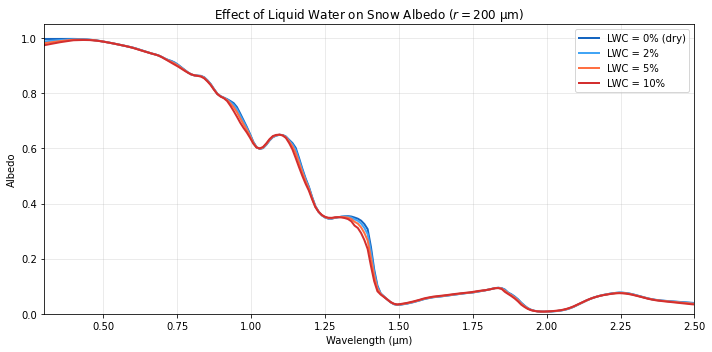

In [12]:
# Demonstrate water effect using a simple effective-medium approach

def load_water_ri(wavelength_um):
    """Load liquid water refractive index (Segelstein 1981)."""
    import csv
    wvl_w, n_re_w, n_im_w = [], [], []
    fpath = DATA_DIR / "OP_data" / "Refractive_Index_Liquid_Water_Segelstein_1981.csv"
    if fpath.is_file():
        with open(fpath) as f:
            for row in csv.reader(f):
                try:
                    wvl_w.append(float(row[0]))
                    n_re_w.append(float(row[1]))
                    n_im_w.append(float(row[2]))
                except (ValueError, IndexError):
                    pass
        if wvl_w:
            n_re = np.interp(wavelength_um, wvl_w, n_re_w)
            n_im = np.interp(wavelength_um, wvl_w, n_im_w)
            print("Loaded real liquid water RI (Segelstein 1981)")
            return n_re, n_im
    # Fallback: analytical approximation
    print("Using analytical water RI approximation (less accurate)")
    n_re = 1.33 - 0.003 * (wavelength_um - 0.5)
    ln_k = np.where(wavelength_um < 0.7, -22 + 4*(wavelength_um - 0.3),
            np.where(wavelength_um < 1.5, -18 + 8*(wavelength_um - 0.7),
                     -5 + 3*(wavelength_um - 1.5)))
    n_im = np.exp(ln_k)
    return n_re, n_im

# Effective-medium approximation: mix ice and water absorption
N_RE_WATER, N_IM_WATER = load_water_ri(WVL_FAST)

def wet_snow_albedo(grain_radius, lwc_fraction, wavelength, n_re_ice, n_im_ice, mu0=0.5):
    """Approximate wet snow albedo using effective medium mixing.

    lwc_fraction: volume fraction of liquid water (0 to ~0.15).
    The main effect is through the changed imaginary refractive index
    (water absorbs at slightly different NIR wavelengths than ice).
    """
    # Get dry-snow optical properties from Mie cache
    qext, qsca, qabs, ssa_dry, g = mie_sphere(grain_radius, wavelength, n_re_ice, n_im_ice)

    if lwc_fraction <= 0:
        ssa = ssa_dry
    else:
        # Effective-medium absorption: volume-weighted n_im
        n_im_eff = (1 - lwc_fraction) * n_im_ice + lwc_fraction * N_IM_WATER

        # Recompute absorption fraction with effective n_im
        mean_path_m = (4.0 / 3.0) * grain_radius * 1e-6
        alpha_eff = 4 * np.pi * n_im_eff / (wavelength * 1e-6)
        absorb_frac = np.clip(1 - np.exp(-alpha_eff * mean_path_m), 0, 1)
        qabs_eff = 2.0 * absorb_frac
        ssa = np.clip(1 - qabs_eff / 2.0, 0, 1)

    # Semi-infinite albedo using Briegleb (1992) direct-beam formulation
    f = g**2
    ws = ssa * (1 - f) / np.maximum(1 - ssa * f, 1e-30)
    gs = g / (1 + g)
    rdir, _ = _semi_inf_direct(ws, gs, mu0)
    return rdir

fig, ax = plt.subplots(figsize=(10, 5))
r = 200  # µm
lwc_values = [0.0, 0.02, 0.05, 0.10]
lwc_colors = ["#1565C0", "#42A5F5", "#FF7043", "#D32F2F"]

for lwc, c in zip(lwc_values, lwc_colors):
    alb = wet_snow_albedo(r, lwc, WVL_FAST, N_RE, N_IM)
    ax.plot(WVL_FAST, alb, color=c, lw=2,
            label=f"LWC = {lwc*100:.0f}% {'(dry)' if lwc==0 else ''}")

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Albedo")
ax.set_title("Effect of Liquid Water on Snow Albedo ($r = 200$ µm)")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


Liquid water darkens snow primarily in the NIR, where water's absorption
differs from ice.  The effect is modest compared to grain size changes,
but measurable — especially around the 1.0 and 1.2 µm water absorption bands.

### Why water matters more for scattering than absorption

The dominant optical effect of liquid water is actually through **scattering
reduction**, not absorption change.  When water fills the air spaces between
grains, the refractive index contrast at grain boundaries drops from
$n_{\text{ice}}/n_{\text{air}} \approx 1.31/1.00$ to
$n_{\text{ice}}/n_{\text{water}} \approx 1.31/1.33$.  The scattering
efficiency depends on this contrast — nearly matching refractive indices
means much weaker scattering.  With fewer scattering events, photons
penetrate deeper and are more likely to be absorbed.

This is why wet snow appears visibly darker than dry snow at the same
grain size — and why refrozen snow (dry but with large grains from the
melt-refreeze cycle) stays dark.

In practice, water content is difficult to retrieve independently from grain
size because both affect NIR albedo in similar ways.

> **BioSNICAR connection** — Liquid water is modelled as coated spheres using
> Mie theory for layered particles in
> `biosnicar/optical_properties/mie_coated_water_spheres.py` → `miecoated_driver()`.
> The liquid water content (LWC) is set per layer in the YAML config.


---
# Act III: The Radiative Transfer Equation

## Section 9 — The Radiative Transfer Equation (RTE)

### The central problem

We've now built up all the ingredients:
- **$\tau(\lambda)$** — the optical depth of each layer, controlling how
  many scattering/absorption events occur per unit depth
- **$\tilde{\omega}(\lambda)$** — the single-scattering albedo, controlling
  the outcome of each event (scatter vs absorb)
- **$g(\lambda)$** — the asymmetry parameter, controlling the angular
  redistribution at each scattering event

The question is: given these properties, how much light gets **reflected**
(albedo), how much gets **absorbed** (heating), and how much passes
**through**?  This is the central problem of radiative transfer.

### The plane-parallel approximation

Snow and ice surfaces are typically much wider than they are deep, and
their properties vary mainly with depth (not horizontally).  This lets us
use the **plane-parallel approximation**: we treat each layer as an
infinite horizontal slab, and the radiation field depends only on depth
and angle — not on horizontal position.

We describe direction using the **cosine of the polar angle**:
$\mu = \cos\theta$, where $\theta$ is measured from the vertical.
$\mu = +1$ is straight up, $\mu = -1$ is straight down, and $\mu = 0$
is horizontal.  (The convention varies between textbooks; here $\theta$
is measured from the zenith, so $\mu = \cos(0) = +1$ is up and
$\mu = \cos(\pi) = -1$ is down, while $\tau$ increases downward.)

### The full radiative transfer equation

In a plane-parallel scattering and absorbing medium, the monochromatic
specific intensity $I(\tau, \mu, \phi)$ obeys:

$$
\mu \frac{dI(\tau, \mu, \phi)}{d\tau}
= I(\tau, \mu, \phi)
- \frac{\tilde{\omega}}{4\pi} \int_0^{2\pi} \int_{-1}^{1}
  P(\mu, \phi; \mu', \phi') \, I(\tau, \mu', \phi') \, d\mu' \, d\phi'
- S_{\text{solar}}
$$

Let's unpack each term:

**Left-hand side**: $\mu \, dI/d\tau$ — the rate of change of intensity
along the beam direction.  The factor $\mu$ accounts for the path length
through a horizontal slab: a beam at angle $\theta$ travels a distance
$d\tau/\mu$ through a slab of optical thickness $d\tau$.

**First term on the right** ($+I$): **Extinction** — intensity is removed
from the beam by both scattering and absorption.  Each optical depth unit
removes a fraction $dI/I = -d\tau/\mu$ from the beam.

**Second term** ($-\tilde{\omega}/(4\pi) \int P \cdot I \, d\Omega$):
**Scattering source** — intensity scattered *into* this direction from all
other directions.  The phase function $P$ describes how much light is
redirected from direction $(\mu', \phi')$ into direction $(\mu, \phi)$.
The factor $\tilde{\omega}$ accounts for the fact that only the scattered
fraction (not the absorbed fraction) contributes.

**Third term** ($-S_{\text{solar}}$): **Direct solar source** — the direct
beam from the sun, which adds intensity at the solar zenith angle.

### Why the RTE is hard to solve

This is an **integro-differential equation**: the derivative of $I$ depends
on an integral of $I$ over all angles.  The intensity at any point depends
on the intensity arriving from every other direction — which itself depends
on the intensity at other points.  There is no general closed-form solution.

Exact numerical methods exist (discrete ordinates, Monte Carlo) but are
computationally expensive.  For snow and ice modelling, where we need
solutions at hundreds of wavelengths for many different configurations,
we need an **approximation** — the two-stream method (next section).

```
        ↓ ↓ ↓ F_solar (direct + diffuse)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  τ = 0 (top)
        ↕ scattering events
   - - - - - - - - - - - - - - - - -  τ = τ₁
        ↕ more scattering
   - - - - - - - - - - - - - - - - -  τ = τ₁ + τ₂
        ↕
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  τ = τ_total (bottom)
        ↓ F_transmitted
```


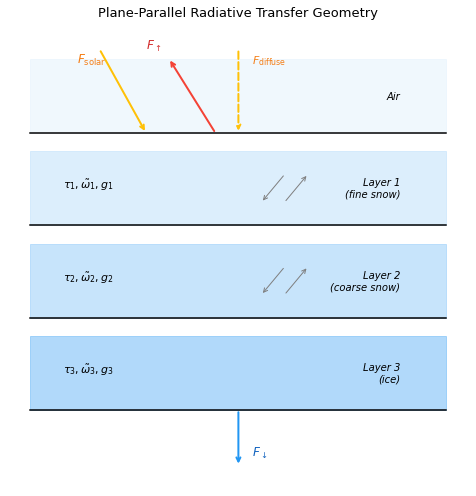

In [13]:
# Visualise the plane-parallel geometry

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")

# Layers
layers = [(8.5, "Air", "#E3F2FD"), (6.5, "Layer 1\n(fine snow)", "#BBDEFB"),
          (4.5, "Layer 2\n(coarse snow)", "#90CAF9"),
          (2.5, "Layer 3\n(ice)", "#64B5F6")]
for y, label, color in layers:
    ax.fill_between([0.5, 9.5], y-0.8, y+0.8, color=color, alpha=0.5)
    ax.text(8.5, y, label, ha="right", va="center", fontsize=10, style="italic")

# Interfaces
for y in [7.7, 5.7, 3.7, 1.7]:
    ax.axhline(y, color="black", lw=1.5, xmin=0.05, xmax=0.95)

# Incoming radiation
ax.annotate("", xy=(3, 7.7), xytext=(2, 9.5),
            arrowprops=dict(arrowstyle="->", lw=2, color="#FFC107"))
ax.text(1.5, 9.2, "$F_{\\mathrm{solar}}$", fontsize=12, color="#F57F17")
ax.annotate("", xy=(5, 7.7), xytext=(5, 9.5),
            arrowprops=dict(arrowstyle="->", lw=2, color="#FFC107", ls="--"))
ax.text(5.3, 9.2, "$F_{\\mathrm{diffuse}}$", fontsize=11, color="#F57F17")

# Reflected
ax.annotate("", xy=(3.5, 9.3), xytext=(4.5, 7.7),
            arrowprops=dict(arrowstyle="->", lw=2, color="#F44336"))
ax.text(3.0, 9.5, "$F_{\\uparrow}$", fontsize=12, color="#D32F2F")

# Transmitted
ax.annotate("", xy=(5, 0.5), xytext=(5, 1.7),
            arrowprops=dict(arrowstyle="->", lw=2, color="#2196F3"))
ax.text(5.3, 0.7, "$F_{\\downarrow}$", fontsize=12, color="#1565C0")

# Internal scattering
for y in [6.5, 4.5]:
    ax.annotate("", xy=(6.5, y+0.3), xytext=(6.0, y-0.3),
                arrowprops=dict(arrowstyle="->", lw=1, color="gray"))
    ax.annotate("", xy=(5.5, y-0.3), xytext=(6.0, y+0.3),
                arrowprops=dict(arrowstyle="->", lw=1, color="gray"))

# Labels
ax.text(1.2, 6.5, "$\\tau_1, \\tilde{\\omega}_1, g_1$", fontsize=11)
ax.text(1.2, 4.5, "$\\tau_2, \\tilde{\\omega}_2, g_2$", fontsize=11)
ax.text(1.2, 2.5, "$\\tau_3, \\tilde{\\omega}_3, g_3$", fontsize=11)

ax.set_title("Plane-Parallel Radiative Transfer Geometry", fontsize=13, pad=10)
plt.tight_layout()
plt.show()


The albedo is the ratio of upward to downward flux at the top surface:

$$
\alpha(\lambda) = \frac{F^{\uparrow}(\tau = 0)}{F^{\downarrow}(\tau = 0)}
$$

To solve the RTE, we need to simplify it.  The most common approach for
snow/ice is the **two-stream approximation**.

> **BioSNICAR connection** — BioSNICAR implements two solvers:
> - **Adding-doubling**: `biosnicar/rt_solvers/adding_doubling_solver.py`
>   (more accurate, handles Fresnel corrections)
> - **Toon et al. (1989)**: `biosnicar/rt_solvers/toon_rt_solver.py`
>   (simpler two-stream, slightly faster)


## Section 10 — The Two-Stream Approximation

### The key idea

The RTE describes how intensity varies with both depth *and* angle — it
is a function $I(\tau, \mu, \phi)$ of three variables.  The two-stream
approximation makes a radical simplification: instead of tracking intensity
at every angle, we collapse the entire angular distribution into just **two
numbers** at each depth:

- $F^{\downarrow}(\tau)$ — total flux moving **downward** (integrated over the
  downward hemisphere, $0 < \mu < 1$)
- $F^{\uparrow}(\tau)$ — total flux moving **upward** (integrated over the
  upward hemisphere, $-1 < \mu < 0$)

This is equivalent to saying: we don't care *exactly* which angle each
photon is travelling at — we only care whether it is going up or down.
At each depth, we know the total upward and downward power, and we track
how these change with depth.

### The two coupled ODEs

With this simplification, the integro-differential RTE becomes two
**coupled ordinary differential equations** (ODEs):

$$
\frac{dF^{\downarrow}}{d\tau} = \gamma_1 F^{\downarrow} - \gamma_2 F^{\uparrow} - S^{\downarrow}
$$

$$
\frac{dF^{\uparrow}}{d\tau} = -\gamma_1 F^{\uparrow} + \gamma_2 F^{\downarrow} + S^{\uparrow}
$$

The physical meaning of each term:

- **$\gamma_1 F^{\downarrow}$**: Downward flux lost to extinction
  (scattering + absorption).  $\gamma_1$ is the effective extinction rate
  that accounts for the fact that forward-scattered light stays in the
  downward beam.
- **$-\gamma_2 F^{\uparrow}$**: Upward flux scattered back into the
  downward direction.  $\gamma_2$ is the effective backscattering coefficient.
- **$S^{\downarrow}$**: Direct solar beam source.
- The second equation is the mirror image for upward-propagating light.

The $\gamma$ coefficients encode all the physics of the scattering
medium ($\tilde{\omega}$, $g$) into two effective rates.  Different choices
for how to perform the angular integration give different $\gamma$ values,
leading to three standard variants:

| Variant | $\gamma_1$ | $\gamma_2$ | Accuracy |
|---------|------------|------------|----------|
| **Eddington** | $\frac{7 - \tilde\omega(4 + 3g)}{4}$ | $\frac{-(1 - \tilde\omega(4 - 3g))}{4}$ | Good all-round; slight errors for conservative scattering |
| **Quadrature** | $\frac{\sqrt{3}(2 - \tilde\omega(1+g))}{2}$ | $\frac{\tilde\omega\sqrt{3}(1-g)}{2}$ | Best for $\tilde{\omega} \to 1$ (conservative scattering) |
| **Hemispheric Mean** | $2 - \tilde\omega(1+g)$ | $\tilde\omega(1-g)$ | Simplest; best for thick layers |

All three give the same results to within a few percent for typical snow
conditions.  BioSNICAR defaults to the Eddington variant.

### Why two-stream works well for snow

The two-stream approximation is exact for isotropic scattering ($g = 0$)
and becomes less accurate as $g \to 1$.  Since snow grains have
$g \approx 0.87$, you might worry about accuracy.  But the
**delta-Eddington correction** (next section) addresses exactly this:
by removing the forward peak from the phase function, it reduces the
effective $g$ to $\sim 0.47$, putting us in a regime where the
two-stream approximation is accurate.

The alternative — solving the full RTE with, say, 16-stream discrete
ordinates — is more accurate but ~100× slower.  For a model like BioSNICAR
that runs at 480 wavelengths over multi-layer snowpacks, the two-stream
approximation with delta-Eddington is the standard balance of speed and
accuracy.


In [14]:
# Implement and compare the three two-stream variants

def two_stream_gamma(ssa, g, mu0, variant="eddington"):
    """Two-stream gamma coefficients."""
    if variant == "eddington":
        g1 = (7 - ssa * (4 + 3*g)) / 4
        g2 = -(1 - ssa * (4 - 3*g)) / 4
        g3 = (2 - 3*g*mu0) / 4
        g4 = 1 - g3
        mu1 = 0.5
    elif variant == "quadrature":
        g1 = np.sqrt(3) * (2 - ssa*(1 + g)) / 2
        g2 = ssa * np.sqrt(3) * (1 - g) / 2
        g3 = (1 - np.sqrt(3)*g*mu0) / 2
        g4 = 1 - g3
        mu1 = 1 / np.sqrt(3)
    elif variant == "hemispheric":
        g1 = 2 - ssa*(1 + g)
        g2 = ssa * (1 - g)
        g3 = (1 - np.sqrt(3)*g*mu0) / 2
        g4 = 1 - g3
        mu1 = 0.5
    return g1, g2, g3, g4, mu1


def single_layer_reflectance(tau, ssa, g, mu0, variant="eddington"):
    """Reflectance of a single homogeneous layer using two-stream theory.

    This is the core building block for radiative transfer in snow/ice.
    """
    g1, g2, g3, g4, mu1 = two_stream_gamma(ssa, g, mu0, variant)

    # Eigenvalue
    lam = np.sqrt(np.maximum(g1**2 - g2**2, 0))

    # Exponential terms (clipped to avoid overflow)
    exp_pos = np.exp(np.minimum(lam * tau, 500))
    with np.errstate(divide="ignore", invalid="ignore"):
        exp_neg = 1.0 / exp_pos

    # Reflectance and transmittance
    denom = (g1 + lam) * exp_pos + (g1 - lam) * exp_neg

    # Handle conservative scattering (ssa = 1) separately
    conservative = np.abs(1 - ssa) < 1e-10
    denom_safe = np.where(conservative, 1.0, np.where(np.abs(denom) < 1e-30, 1e-30, denom))

    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        R = g2 * (exp_pos - exp_neg) / denom_safe
        T = 2 * lam / denom_safe

    # Conservative scattering limit
    R = np.where(conservative, tau * g2 / (1 + tau * g2), R)
    T = np.where(conservative, 1 / (1 + tau * g2), T)

    return np.clip(R, 0, 1), np.clip(T, 0, 1)

print("Two-stream solver defined.")


Two-stream solver defined.


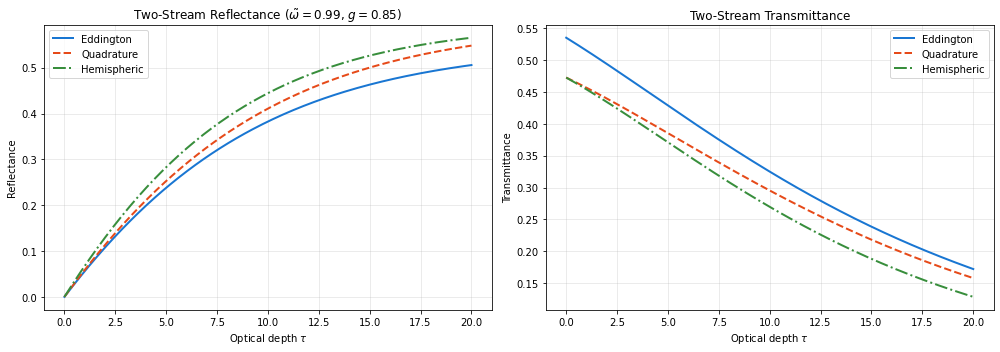

In [15]:
# Compare variants on a single-layer problem

tau_range = np.linspace(0.01, 20, 200)
ssa_test = 0.99
g_test = 0.85
mu0_test = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
variants = [("eddington", "#1976D2", "-"),
            ("quadrature", "#E64A19", "--"),
            ("hemispheric", "#388E3C", "-.")]

for name, c, ls in variants:
    R_vals = []
    T_vals = []
    for tau in tau_range:
        R, T = single_layer_reflectance(tau, ssa_test, g_test, mu0_test, name)
        R_vals.append(R)
        T_vals.append(T)
    ax1.plot(tau_range, R_vals, color=c, ls=ls, lw=2, label=name.capitalize())
    ax2.plot(tau_range, T_vals, color=c, ls=ls, lw=2, label=name.capitalize())

ax1.set_xlabel("Optical depth $\\tau$")
ax1.set_ylabel("Reflectance")
ax1.set_title(f"Two-Stream Reflectance ($\\tilde{{\\omega}} = {ssa_test}$, $g = {g_test}$)")
ax1.legend()

ax2.set_xlabel("Optical depth $\\tau$")
ax2.set_ylabel("Transmittance")
ax2.set_title(f"Two-Stream Transmittance")
ax2.legend()

plt.tight_layout()
plt.show()


The three variants agree closely for moderate optical depths and converge to
the same limits as $\tau \to 0$ (transparent) and $\tau \to \infty$ (semi-infinite).
The differences are at the few-percent level and are most noticeable for
intermediate optical depths.  In practice, the choice of variant matters less
than the accuracy of the input optical properties.

The **Eddington** approximation is the most widely used and is BioSNICAR's
default (`aprx_typ = 1`).  It approximates the radiation field as a linear
function of $\mu = \cos\theta$.  The **Quadrature** method evaluates the
radiation field at a specific angle ($\mu = 1/\sqrt{3}$), which is more
accurate for conservative scattering ($\tilde{\omega} \approx 1$).  The
**Hemispheric Mean** averages over each hemisphere, giving the simplest
coefficients.

Why use two-stream at all, rather than solving the full RTE numerically?
The full equation has angular, wavelength, and depth dimensions — solving it
exactly (e.g., with discrete ordinates or Monte Carlo) is computationally
expensive.  The two-stream approximation reduces the angular dimension to
just two quantities (upward and downward flux), making the solution
analytical for each layer.  For snow and ice, where the phase function is
smooth (well-described by the Henyey-Greenstein function) and the medium
is horizontally homogeneous, this approximation is accurate to within
a few percent.

> **BioSNICAR connection** — The $\gamma$ coefficients are computed in
> `biosnicar/rt_solvers/toon_rt_solver.py:279–330` →
> `two_stream_approximation()`, which implements all three variants.
> The adding-doubling solver in `adding_doubling_solver.py` uses a different
> but equivalent formulation based on the eigenvalues of the two-stream
> matrix (lines 296–322).  The parameter `APRX_TYP` in `inputs.yaml`
> selects the variant (1 = Eddington, 2 = Quadrature, 3 = Hemispheric Mean).


## Section 11 — Delta-Eddington Scaling

Snow grains are **strongly forward-scattering** ($g \approx 0.85$–$0.9$).
This means the phase function has a sharp peak near $\theta = 0°$.  The
two-stream approximation cannot accurately represent this peak, leading to
errors in albedo.

The **delta-Eddington** (or delta-M) correction truncates the forward peak
and renormalises the optical properties:

$$
\tau^* = (1 - \tilde{\omega} f) \, \tau
$$

$$
\tilde{\omega}^* = \frac{(1 - f)\, \tilde{\omega}}{1 - \tilde{\omega} f}
$$

$$
g^* = \frac{g - f}{1 - f}
$$

where $f = g^2$ for the delta-Eddington method.

### Intuitive picture

When a photon hits a snow grain with $g \approx 0.87$, about $f = g^2 \approx 76\%$
of the time it continues almost straight forward — indistinguishable from
not having scattered at all.  Only the remaining 24% of scattering events
meaningfully redirect the photon.  The delta-Eddington correction acknowledges
this: it removes the "fake" forward-scattering events from the optical depth
(reducing $\tau$), adjusts the scattering albedo accordingly, and produces
a more isotropic effective phase function ($g^* \approx 0.46$) that the
two-stream approximation can handle accurately.

Without delta scaling, the two-stream solver overestimates forward
transmission (treating strong forward scattering as real scattering events
that count toward the diffusion), which **underestimates** albedo.
The correction is essential for snow, where $g$ is high.


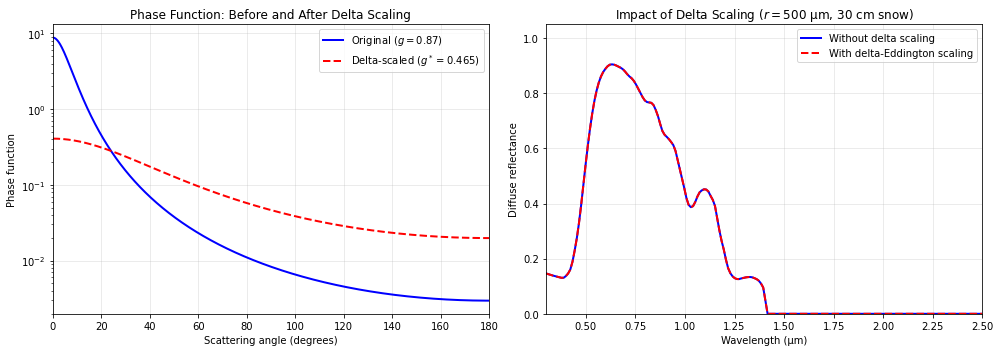

In [16]:
# Delta-Eddington scaling implementation

def delta_eddington_scale(tau, ssa, g):
    """Apply delta-Eddington scaling to optical properties."""
    f = g**2
    tau_star = (1 - ssa * f) * tau
    ssa_star = ssa * (1 - f) / (1 - ssa * f)
    g_star = (g - f) / (1 - f)
    return tau_star, ssa_star, g_star

# Show the phase function before and after scaling
theta = np.linspace(0, np.pi, 1000)
cos_theta = np.cos(theta)

g_orig = 0.87
g_star = (g_orig - g_orig**2) / (1 - g_orig**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Phase function comparison
p_orig = hg_phase(cos_theta, g_orig)
p_scaled = hg_phase(cos_theta, g_star)

ax1.semilogy(np.degrees(theta), p_orig, "b-", lw=2, label=f"Original ($g = {g_orig}$)")
ax1.semilogy(np.degrees(theta), p_scaled, "r--", lw=2,
             label=f"Delta-scaled ($g^* = {g_star:.3f}$)")
ax1.set_xlabel("Scattering angle (degrees)")
ax1.set_ylabel("Phase function")
ax1.set_title("Phase Function: Before and After Delta Scaling")
ax1.legend()
ax1.set_xlim(0, 180)

# Albedo comparison: unscaled vs delta-Eddington scaled
# Use single_layer_reflectance (diffuse) which is defined above.
# Use a moderately thick layer so differences are visible but not saturated.
r_grain = 500  # µm — larger grains show more difference
qext, qsca, qabs, ssa, g_mie = mie_sphere(r_grain, WVL_FAST, N_RE, N_IM)
mac = 3 * qext / (4 * r_grain * 1e-6 * RHO_ICE)
dz = 0.3  # moderate thickness
rho = 350  # kg/m³
tau_layer = mac * rho * dz

# Unscaled: use raw tau, ssa, g
R_unscaled, _ = single_layer_reflectance(tau_layer, ssa, g_mie, 0.5, "eddington")

# Delta-Eddington scaled
tau_s, ssa_s, g_s = delta_eddington_scale(tau_layer, ssa, g_mie)
R_scaled, _ = single_layer_reflectance(tau_s, ssa_s, g_s, 0.5, "eddington")

ax2.plot(WVL_FAST, R_unscaled, "b-", lw=2, label="Without delta scaling")
ax2.plot(WVL_FAST, R_scaled, "r--", lw=2, label="With delta-Eddington scaling")
ax2.fill_between(WVL_FAST, R_unscaled, R_scaled, alpha=0.15, color="orange")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Diffuse reflectance")
ax2.set_title(f"Impact of Delta Scaling ($r = {r_grain}$ µm, 30 cm snow)")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()


Delta-Eddington scaling has a significant impact:

- The **forward peak** is greatly reduced (left panel), making the two-stream
  approximation more accurate.  The original phase function has a sharp spike
  near $\theta = 0°$ that no two-angular-bin method can capture; the delta
  function removes this spike and rescales the remainder.
- **NIR albedo increases** after scaling because removing the forward-scattered
  fraction effectively increases the back-scattered fraction, reflecting more
  light upward.  Physically, much of the forward-scattered light was going to
  travel deeper into the snowpack and be absorbed; by treating it as unscattered,
  we correctly account for this.
- **Visible albedo is nearly unaffected** because $\tilde{\omega} \approx 1$
  and nearly all light is scattered regardless — the angular redistribution
  doesn't matter when there's no absorption.

Without delta scaling, two-stream methods underestimate snow albedo by
5–15% in the NIR.  It is essential for quantitative accuracy.

The choice of $f = g^2$ comes from matching the first two moments of the
phase function and is standard for two-stream approximations (including
SNICAR's adding-doubling solver).  Multi-stream solvers like DISORT use
the more general **delta-M** scaling with $f = g^N$, where $N$ is the
number of streams, to match higher-order moments of the phase function.

> **BioSNICAR connection** — Delta-Eddington scaling is applied in
> `biosnicar/rt_solvers/adding_doubling_solver.py:296–322` →
> `calc_reflectivity_transmittivity()`.  The scaled properties $\tau^*$,
> $\tilde{\omega}^*$, $g^*$ are computed before the two-stream eigenvalue
> solution.  The variables are named `ts`, `ws`, and `gs` in the code.
> The Toon solver applies the same scaling in `toon_rt_solver.py:267–277`.


> **Exercise**: What happens if you set $f = g^3$ instead of $f = g^2$?
> (This is the delta-M method with higher-order truncation.)
> Try modifying `delta_eddington_scale` and observe the effect on albedo.


## Section 12 — The Single-Layer Solution

For a single homogeneous slab with optical depth $\tau$, the two-stream
equations have an analytical solution.  The **reflectance** $R$ and
**transmittance** $T$ of the slab depend on four quantities, each with
a clear physical interpretation:

| Parameter | Physical meaning | Effect on albedo |
|-----------|-----------------|-----------------|
| $\tau$ | **Optical thickness** — total attenuation | Higher $\tau$ → more scattering events → higher R (if $\tilde{\omega} > 0$) |
| $\tilde{\omega}$ | **Single-scattering albedo** — probability that a scattering event is NOT absorption | Higher $\tilde{\omega}$ → fewer photons absorbed per bounce → higher R |
| $g$ | **Asymmetry parameter** — degree of forward scattering | Higher $g$ → photons mostly continue forward → lower R (light passes through) |
| $\mu_0$ | **Cosine of SZA** — controls effective path length | Lower $\mu_0$ (more oblique) → longer path → more scattering → higher R |

### Interplay of parameters

The albedo emerges from a competition between **scattering** (which can
redirect photons back out) and **absorption** (which removes them):

- **High $\tilde{\omega}$, high $\tau$, low $g$**: Maximum albedo. Many
  scattering events, little absorption per event, and isotropic scattering
  gives the photon many chances to reverse direction.
- **Low $\tilde{\omega}$**: Even a thick medium is dark if each scattering
  event has a high absorption probability.
- **High $g$**: Forward scattering keeps photons moving deeper into the
  medium, reducing their chance of returning to the surface.  This is why
  $g$ is so important for snow — large ice crystals have $g \sim 0.87$,
  meaning most scattering events don't significantly redirect the photon.
- **Conservative scattering** ($\tilde{\omega} = 1$): With zero absorption,
  $R + T = 1$ exactly, and $R \to 1$ as $\tau \to \infty$.  Every photon
  eventually finds its way back out if it can't be absorbed.


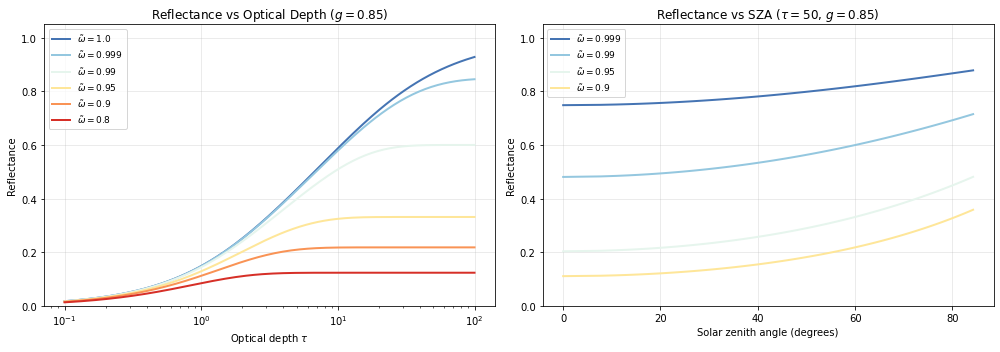

In [17]:
# Build the complete single-layer albedo calculator
# Uses the Briegleb (1992) / Briegleb & Light (2007) formulation,
# matching BioSNICAR's adding-doubling solver exactly.

def layer_rt(tau, ssa, g, mu0=0.5, delta_scale=True):
    """Compute layer reflectance and transmittance.

    Returns both diffuse (rdif, tdif) and direct-beam (rdir, tdir)
    components, following Briegleb (1992).  This is the same
    formulation used in BioSNICAR's adding-doubling solver
    (adding_doubling_solver.py:296-356).

    Parameters
    ----------
    tau : array  — optical depth at each wavelength
    ssa : array  — single-scattering albedo
    g   : array  — asymmetry parameter
    mu0 : float  — cosine of solar zenith angle
    delta_scale : bool — apply delta-Eddington scaling

    Returns
    -------
    rdif, tdif : array — diffuse (hemispheric) reflectance / transmittance
    rdir, tdir : array — direct-beam reflectance / transmittance
    """
    tau = np.asarray(tau, dtype=float)
    ssa = np.asarray(ssa, dtype=float)
    g   = np.asarray(g, dtype=float)

    # Delta-Eddington scaling
    if delta_scale:
        f = g**2
        ts = (1 - ssa * f) * tau
        ws = ssa * (1 - f) / np.maximum(1 - ssa * f, 1e-30)
        gs = g / (1 + g)          # equivalent to (g-f)/(1-f)
    else:
        ts, ws, gs = tau.copy(), ssa.copy(), g.copy()

    # Clamp ws just below 1 to avoid conservative-scattering singularity
    ws = np.minimum(ws, 1 - 1e-12)

    # Eigenvalue (Briegleb & Light 2007, Eq. 50)
    lm = np.sqrt(np.maximum(3 * (1 - ws) * (1 - ws * gs), 0))
    with np.errstate(divide='ignore', invalid='ignore'):
        ue = np.where(lm > 1e-30, 1.5 * (1 - ws * gs) / lm, 0.0)

    # Exponential extinction
    extins = np.exp(np.clip(-lm * ts, -500, 0))
    inv_ext = 1.0 / np.maximum(extins, 1e-300)
    ne = (ue + 1)**2 * inv_ext - (ue - 1)**2 * extins
    ne = np.where(np.abs(ne) < 1e-30, 1e-30, ne)

    # Diffuse reflectance and transmittance
    rdif = (ue**2 - 1) * (inv_ext - extins) / ne
    tdif = 4 * ue / ne
    rdif = np.clip(rdif, 0, 1)
    tdif = np.clip(tdif, 0, 1)

    # Direct beam transmission through the layer
    trnlay = np.exp(np.clip(-ts / mu0, -500, 0))

    # Direct beam coefficients (Briegleb 1992, Eqs. in Briegleb & Light 2007)
    eps = 1e-10
    dd = 1 - lm**2 * mu0**2 + eps
    alp = 0.75 * ws * mu0 * (1 + gs * (1 - ws)) / dd
    gam_c = 0.5 * ws * (1 + 3 * gs * mu0**2 * (1 - ws)) / dd
    apg = alp + gam_c
    amg = alp - gam_c

    # Direct-beam reflectance and transmittance
    rdir = apg * rdif + amg * (tdif * trnlay - 1)
    tdir = apg * tdif + (amg * rdif - apg + 1) * trnlay
    rdir = np.clip(rdir, 0, 1)
    tdir = np.clip(tdir, 0, 1)

    return rdif, tdif, rdir, tdir


def single_layer_albedo(tau, ssa, g, mu0=0.5, delta_scale=True):
    """Complete spectral albedo for a single homogeneous layer.

    Thin wrapper around layer_rt that returns the direct-beam
    reflectance and transmittance.  This is the core toy model
    used throughout the notebook.

    Parameters
    ----------
    tau : array  — optical depth at each wavelength
    ssa : array  — single-scattering albedo
    g   : array  — asymmetry parameter
    mu0 : float  — cosine of solar zenith angle
    delta_scale : bool — apply delta-Eddington scaling

    Returns
    -------
    R : array  — direct-beam reflectance (albedo)
    T : array  — direct-beam transmittance
    """
    rdif, tdif, rdir, tdir = layer_rt(tau, ssa, g, mu0, delta_scale)
    return rdir, tdir

# Demonstrate: albedo vs optical depth for different SSA values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tau_range = np.logspace(-1, 2, 200)
ssa_values = [1.0, 0.999, 0.99, 0.95, 0.9, 0.8]
colors_ssa = plt.cm.RdYlBu(np.linspace(0.9, 0.1, len(ssa_values)))

for ssa_val, c in zip(ssa_values, colors_ssa):
    R_vals = np.array([layer_rt(np.array([t]), np.array([ssa_val]),
                                np.array([0.85]), 0.5)[2][0]
                       for t in tau_range])
    ax1.plot(tau_range, R_vals, color=c, lw=2, label=f"$\\tilde{{\\omega}} = {ssa_val}$")

ax1.set_xscale("log")
ax1.set_xlabel("Optical depth $\\tau$")
ax1.set_ylabel("Reflectance")
ax1.set_title("Reflectance vs Optical Depth ($g = 0.85$)")
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.05)

# Albedo vs SZA (mu0) for a thick layer
mu0_range = np.linspace(0.1, 1.0, 100)
for ssa_val, c in zip([0.999, 0.99, 0.95, 0.9], colors_ssa[:4]):
    R_vals = np.array([layer_rt(np.array([50.0]), np.array([ssa_val]),
                                np.array([0.85]), m)[2][0]
                       for m in mu0_range])
    ax2.plot(np.degrees(np.arccos(mu0_range)), R_vals, color=c, lw=2,
             label=f"$\\tilde{{\\omega}} = {ssa_val}$")

ax2.set_xlabel("Solar zenith angle (degrees)")
ax2.set_ylabel("Reflectance")
ax2.set_title("Reflectance vs SZA ($\\tau = 50$, $g = 0.85$)")
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


Key observations:

- **Reflectance saturates** for $\tau \gtrsim 10$ — beyond this, the medium
  is effectively semi-infinite and adding more material doesn't change the albedo.
  For typical snow density (300 kg/m³) and grain size (200 µm), this corresponds
  to a snow depth of roughly 10–20 cm.  This is the **optically thick** limit.
- **SSA controls the saturation level**: $\tilde{\omega} = 1$ → $R = 1$ (perfect
  reflector); $\tilde{\omega} = 0.8$ → $R \approx 0.3$.  The relationship is
  highly non-linear: even $\tilde{\omega} = 0.999$ gives noticeably lower
  albedo than $\tilde{\omega} = 1.0$.
- **SZA dependence**: Higher zenith angles (lower $\mu_0$) increase albedo
  because light enters at a shallower angle, encountering more scattering
  events before penetrating deep into the snowpack.  The effective optical
  depth is $\tau / \mu_0$, so a 60° SZA doubles the effective path.

The semi-infinite limit ($\tau \to \infty$) gives a particularly elegant
formula:

$$
\alpha_{\infty} = \frac{\gamma_1 - \sqrt{\gamma_1^2 - \gamma_2^2}}{\gamma_2}
$$

This depends only on $\tilde{\omega}$ and $g$ (through $\gamma_1$, $\gamma_2$),
not on $\tau$.  This is why the albedo of deep snow depends on grain size
(which controls $\tilde{\omega}$) but not on depth.

> **BioSNICAR connection** — The full BioSNICAR solver computes per-layer
> reflectance and transmittance before combining them with the adding method.
> The delta-Eddington coefficients and eigenvalue solution in
> `adding_doubling_solver.py:296–322` are equivalent to our toy solver.
> BioSNICAR also handles the direct-beam source term explicitly, which our
> simplified version omits for clarity.


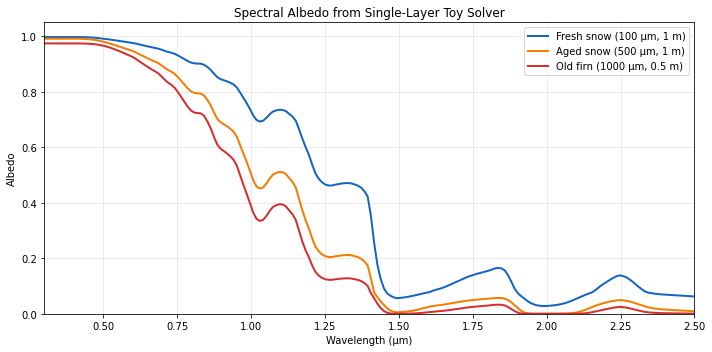

In [18]:
# Full spectral albedo from the single-layer solver

fig, ax = plt.subplots(figsize=(10, 5))

scenarios = [
    {"r": 100, "dz": 1.0, "rho": 300, "label": "Fresh snow (100 µm, 1 m)", "c": "#1565C0"},
    {"r": 500, "dz": 1.0, "rho": 400, "label": "Aged snow (500 µm, 1 m)", "c": "#F57C00"},
    {"r": 1000, "dz": 0.5, "rho": 500, "label": "Old firn (1000 µm, 0.5 m)", "c": "#D32F2F"},
]

for s in scenarios:
    qext, qsca, qabs, ssa, g_mie = mie_sphere(s["r"], WVL_FAST, N_RE, N_IM)
    mac = 3 * qext / (4 * s["r"] * 1e-6 * RHO_ICE)
    tau_layer = mac * s["rho"] * s["dz"]
    R, T = single_layer_albedo(tau_layer, ssa, g_mie, mu0=0.5)
    ax.plot(WVL_FAST, R, color=s["c"], lw=2, label=s["label"])

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Albedo")
ax.set_title("Spectral Albedo from Single-Layer Toy Solver")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## Section 13 — The Adding Method: Combining Layers

### Why layering matters

Real snowpacks are never homogeneous.  A typical winter snowpack might have:

- **Surface**: 5 cm of fresh dendritic snow (small grains, low density)
- **Middle**: 20 cm of rounded, wind-packed grains (medium grains, higher density)
- **Base**: depth hoar or old firn (large grains, high density)
- **Bottom**: soil, rock, or glacier ice

Each layer has different optical properties ($\tau$, $\tilde{\omega}$, $g$),
so we cannot treat the whole snowpack as a single slab.  We need a method to
**combine layers** — and this is the adding method.

### The physical picture: mirrors facing each other

Imagine placing two semi-transparent mirrors facing each other.  Light
enters from above, passes through the first mirror, bounces off the second,
and some fraction bounces back off the first mirror's underside, then off
the second again, and so on.  Each bounce loses some light to absorption,
so the series converges.

This is exactly what happens between snowpack layers.  Light transmitted
through layer 1 hits layer 2.  Some fraction $R_2$ reflects back up.
Of this, some fraction $R_1'$ (layer 1's reflectance from below) bounces
back down again, and so on:

| Bounce | Path | Contribution to $R_{12}$ |
|--------|------|--------------------------|
| 0 | Direct reflection off layer 1 | $R_1$ |
| 1 | Through 1, reflect off 2, back through 1 | $T_1 R_2 T_1'$ |
| 2 | Through 1, reflect off 2, reflect off bottom of 1, reflect off 2, through 1 | $T_1 R_2 R_1' R_2 T_1'$ |
| $n$ | $n$ inter-reflections | $T_1 R_2 (R_1' R_2)^{n-1} T_1'$ |

Summing all bounces gives a **geometric series**:

$$
R_{12} = R_1 + T_1 R_2 T_1' \sum_{n=0}^{\infty} (R_1' R_2)^n
= R_1 + \frac{T_1 \cdot R_2 \cdot T_1'}{1 - R_1' \cdot R_2}
$$

$$
T_{12} = \frac{T_1 \cdot T_2}{1 - R_1' \cdot R_2}
$$

where:
- $R_1, T_1$ are reflectance and transmittance of layer 1 illuminated **from above**
- $R_1'$ is the reflectance of layer 1 illuminated **from below** (important: this
  can differ from $R_1$ if the layer has different properties at top and bottom, or
  if direct-beam illumination breaks the symmetry)
- The denominator $1/(1 - R_1' R_2)$ captures all inter-reflection bounces as a
  closed-form sum of the geometric series

### Why the series converges

The product $R_1' R_2$ is always less than 1, because each reflection
also involves some absorption.  Even in the visible where snow is highly
reflective (say $R \approx 0.95$), $R_1' R_2 \approx 0.90$, so the series
converges rapidly.  In the NIR where $R$ is lower, convergence is even faster.
This means the adding formula is **exact** — no truncation needed.

### Building from the bottom up

For an $N$-layer snowpack, we apply the adding formula iteratively, starting
from the bottom.  We combine the bottom two layers, then add the next layer
above, and so on until we reach the surface:

1. Start with layer $N$ (bottom): $R_{\text{below}} = R_N$, $T_{\text{below}} = T_N$
2. Add layer $N{-}1$: combine to get $R_{N-1,N}$, $T_{N-1,N}$
3. Add layer $N{-}2$: combine to get $R_{N-2,...,N}$, $T_{N-2,...,N}$
4. Continue until the top layer is added

We work bottom-up because **reflectance from below** is what the adding
formula needs at each step.  The combined reflectance of everything below
the current layer is naturally available at each stage.

This is essentially the same idea as the **transfer matrix method** in thin
film optics — but expressed in terms of reflectance and transmittance rather
than electric field amplitudes.


In [19]:
# Adding method implementation

def add_layers(R1, T1, R2, T2, R1_prime=None):
    """Combine two layers using the adding method.

    R1, T1: reflectance/transmittance of upper layer (from above)
    R2, T2: reflectance/transmittance of lower layer (from above)
    R1_prime: reflectance of upper layer from below (= R1 if symmetric)

    Returns: R_combined, T_combined
    """
    if R1_prime is None:
        R1_prime = R1

    denom = 1.0 - R1_prime * R2
    denom = np.maximum(denom, 1e-30)  # avoid division by zero

    R_combined = R1 + T1 * R2 * T1 / denom
    T_combined = T1 * T2 / denom

    return np.clip(R_combined, 0, 1), np.clip(T_combined, 0, 1)


def multi_layer_albedo(layer_params, mu0=0.5, wavelength=None):
    """Compute spectral albedo of a multi-layer snowpack.

    Uses diffuse R/T for inter-layer adding (bottom-up), then applies
    the direct-beam correction for the top layer.  This mirrors the
    approach used in BioSNICAR's adding-doubling solver.

    Parameters
    ----------
    layer_params : list of dicts, each with keys:
        radius_um, density, thickness_m
    mu0 : float — cosine of solar zenith angle
    wavelength : array — wavelength grid (uses WVL_FAST if None)

    Returns
    -------
    albedo : array — spectral albedo (direct beam)
    layer_R : list — per-layer direct-beam reflectances
    layer_T : list — per-layer direct-beam transmittances
    """
    if wavelength is None:
        wavelength = WVL_FAST

    # Compute per-layer optical properties
    all_rdif, all_tdif = [], []
    all_rdir, all_tdir = [], []
    for params in layer_params:
        r = params["radius_um"]
        rho = params["density"]
        dz = params["thickness_m"]

        qext, qsca, qabs, ssa, g = mie_sphere(r, wavelength, N_RE, N_IM)
        mac = 3 * qext / (4 * r * 1e-6 * RHO_ICE)
        tau = mac * rho * dz

        rdif, tdif, rdir, tdir = layer_rt(tau, ssa, g, mu0)
        all_rdif.append(rdif)
        all_tdif.append(tdif)
        all_rdir.append(rdir)
        all_tdir.append(tdir)

    # Combine from bottom up using DIFFUSE R/T (inter-layer bouncing is diffuse)
    rdif_below = all_rdif[-1].copy()
    tdif_below = all_tdif[-1].copy()
    for i in range(len(layer_params) - 2, 0, -1):
        rdif_below, tdif_below = add_layers(all_rdif[i], all_tdif[i],
                                             rdif_below, tdif_below)

    # Direct-beam albedo: top layer rdir + transmitted direct interacting below
    if len(layer_params) > 1:
        denom = np.maximum(1 - all_rdif[0] * rdif_below, 1e-30)
        albedo = all_rdir[0] + all_tdir[0] * rdif_below * all_tdif[0] / denom
        T_total = all_tdir[0] * tdif_below / denom
    else:
        albedo = all_rdir[0]
        T_total = all_tdir[0]

    albedo = np.clip(albedo, 0, 1)
    T_total = np.clip(T_total, 0, 1)

    return albedo, all_rdir, all_tdir

print("Adding method defined.")


Adding method defined.


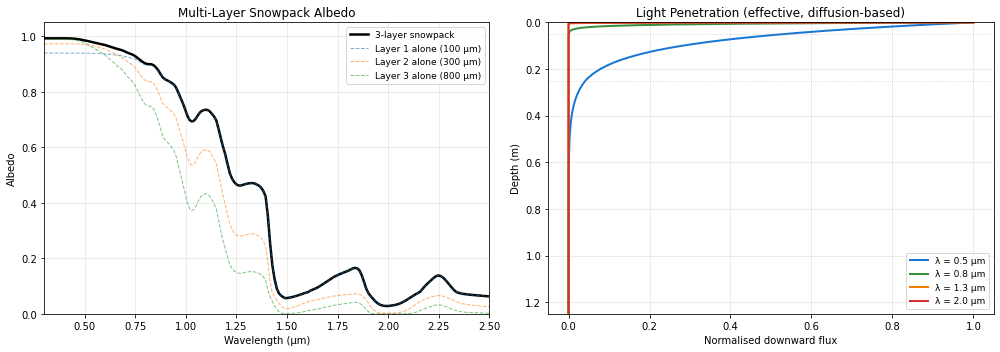

In [20]:
# Demonstrate the adding method: multi-layer snowpack

snowpack_layers = [
    {"radius_um": 100, "density": 200, "thickness_m": 0.05},   # 5 cm fresh snow
    {"radius_um": 300, "density": 350, "thickness_m": 0.20},   # 20 cm aged snow
    {"radius_um": 800, "density": 500, "thickness_m": 1.00},   # 1 m old firn
]

albedo_multi, layer_R, layer_T = multi_layer_albedo(snowpack_layers)

# Compare with single-layer approximations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: full multi-layer vs each layer alone (semi-infinite)
ax1.plot(WVL_FAST, albedo_multi, "k-", lw=2.5, label="3-layer snowpack")
for i, (params, R) in enumerate(zip(snowpack_layers, layer_R)):
    ax1.plot(WVL_FAST, R, "--", lw=1, alpha=0.6,
             label=f"Layer {i+1} alone ({params['radius_um']} µm)")

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Albedo")
ax1.set_title("Multi-Layer Snowpack Albedo")
ax1.set_xlim(0.3, 2.5)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# Right: light penetration profile using EFFECTIVE extinction
# In a scattering medium, the penetration depth is controlled by the
# diffusion coefficient, not the raw extinction.  The effective extinction
# coefficient from two-stream theory is:
#   k_eff = sqrt(3 * (1-ω) * (1 - ω*g)) * k_ext
# This can be orders of magnitude smaller than k_ext when ω ≈ 1.

n_sub = 50  # depth resolution points per layer
all_depths = [0.0]
all_keff = []  # EFFECTIVE extinction coefficient
cumulative = 0.0

for p in snowpack_layers:
    r = p["radius_um"]
    rho = p["density"]
    dz = p["thickness_m"]
    qext_layer, _, _, ssa_layer, g_layer = mie_sphere(r, WVL_FAST, N_RE, N_IM)
    mac_layer = 3 * qext_layer / (4 * r * 1e-6 * RHO_ICE)
    kext = mac_layer * rho  # raw extinction coefficient (m⁻¹)

    # Delta-Eddington scaling
    f = g_layer**2
    ws = ssa_layer * (1 - f) / np.maximum(1 - ssa_layer * f, 1e-30)
    gs = g_layer / (1 + g_layer)

    # Effective extinction from two-stream (diffusion) theory
    keff = np.sqrt(np.maximum(3 * (1 - ws) * (1 - ws * gs), 0)) * kext
    keff = np.maximum(keff, 1e-6)  # avoid zero

    sub_dz = dz / n_sub
    for _ in range(n_sub):
        cumulative += sub_dz
        all_depths.append(cumulative)
        all_keff.append(keff)

# Compute flux decay for selected wavelengths
wvl_targets = [0.5, 0.8, 1.3, 2.0]
wvl_colors = ["#1976D2", "#388E3C", "#F57C00", "#D32F2F"]

for wt, c in zip(wvl_targets, wvl_colors):
    idx = np.argmin(np.abs(WVL_FAST - wt))
    flux_profile = [1.0]
    flux = 1.0
    for j in range(len(all_keff)):
        sub_dz = all_depths[j+1] - all_depths[j]
        flux *= np.exp(-all_keff[j][idx] * sub_dz)
        flux_profile.append(max(flux, 1e-10))
    ax2.plot(flux_profile, all_depths, color=c, lw=2,
             label=f"λ = {wt} µm")

# Mark layer boundaries
boundary = 0
for p in snowpack_layers:
    boundary += p["thickness_m"]
    ax2.axhline(boundary, color="gray", ls=":", alpha=0.4, lw=0.8)

ax2.set_xlabel("Normalised downward flux")
ax2.set_ylabel("Depth (m)")
ax2.set_title("Light Penetration (effective, diffusion-based)")
ax2.invert_yaxis()
ax2.legend(fontsize=9)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(all_depths[-1], 0)

plt.tight_layout()
plt.show()


The multi-layer solution shows that:

- The **top layer dominates** visible albedo — the underlying layers are barely
  visible through the thin fresh snow in the VIS.  This is because visible
  photons are scattered many times in the top few centimetres without being
  absorbed, so most are reflected before reaching deeper layers.
- In the **NIR**, the top layer is more transparent (lower optical depth per
  unit thickness because $\tilde{\omega} < 1$ reduces effective scattering),
  so the lower layers contribute significantly to the total reflectance.
- **Flux penetration** varies enormously with wavelength: blue light reaches the
  bottom of a 25 cm snowpack, while 2 µm radiation is absorbed in the top few mm.
  This is directly controlled by $\kappa(\lambda)$.

This wavelength-dependent penetration has several practical implications:

1. **Remote sensing**: NIR channels sense only the surface grain size, while
   visible channels can be influenced by sub-surface layers (e.g., a dirty
   layer buried under fresh snow).
2. **Heating profiles**: Solar energy is deposited at different depths for
   different wavelengths, creating internal heating that drives metamorphism.
3. **Photobiology**: Algae living on or in ice receive blue-green light that
   penetrates, but are shielded from UV by surface scattering.

The adding method is exact (given the two-stream R and T values) — it accounts
for all orders of inter-reflection between layers, not just single scattering.
The geometric series in the denominator converges because $R_1' R_2 < 1$
(each inter-reflection loses energy to absorption).

> **BioSNICAR connection** — The adding method is implemented in
> `biosnicar/rt_solvers/adding_doubling_solver.py:855–1016` →
> `calc_reflection_below()` and `trans_refl_at_interfaces()`.  These
> functions iterate from the bottom layer upward, combining reflectances
> using the same formula as our `add_layers()`.  BioSNICAR separates
> direct and diffuse components throughout the adding process, tracking
> four quantities per interface: direct reflectance, diffuse reflectance,
> direct transmittance, and diffuse transmittance.


---
# Act IV: Light-Absorbing Particles

## Section 14 — Impurity Mixing: How LAPs Darken Snow

Light-absorbing particles (LAPs) — black carbon, mineral dust, algae — are
mixed into the ice medium.  BioSNICAR uses **external mixing**: the impurity
optical properties are combined with the ice optical properties at the
bulk level, not the single-particle level.

The mixing rules are:

**Total optical depth** (additive):
$$
\tau_{\text{total}} = \tau_{\text{ice}} + \sum_j \tau_{\text{imp},j}
$$

where $\tau_{\text{imp},j} = L_{\text{snow}} \cdot c_j \cdot \text{MAC}_j$
with $c_j$ the mass mixing ratio and $L_{\text{snow}}$ the snow mass path.

**Effective single-scattering albedo** (optical-depth weighted):
$$
\tilde{\omega}_{\text{eff}} = \frac{\tilde{\omega}_{\text{ice}} \tau_{\text{ice}}
+ \sum_j \tilde{\omega}_j \tau_j}{\tau_{\text{total}}}
$$

**Effective asymmetry parameter** (further weighted by SSA):
$$
g_{\text{eff}} = \frac{\tilde{\omega}_{\text{ice}} g_{\text{ice}} \tau_{\text{ice}}
+ \sum_j \tilde{\omega}_j g_j \tau_j}{\tilde{\omega}_{\text{eff}} \tau_{\text{total}}}
$$

### Why do tiny impurity concentrations have such a large effect?

The key insight: even tiny impurity concentrations can dominate in the
**visible** because $\text{MAC}_{\text{BC}} \gg \text{MAC}_{\text{ice}}$ there,
while ice barely absorbs.  At 500 nm, the mass absorption coefficient of
BC is $\sim 10^4$ m$^2$ kg$^{-1}$, while ice absorbs at
$\sim 10^{-2}$ m$^2$ kg$^{-1}$ — a factor of $10^6$ difference.  This means
that ~10 ppb of BC (~10 parts per billion by mass) absorbs as much visible
light as the ice itself.

Think of it this way: in clean snow, a photon at visible wavelengths bounces
between grains hundreds of times before being absorbed — the absorption probability
per scattering event is tiny ($1 - \tilde{\omega} \sim 10^{-7}$).  Adding
~10 ppb of BC roughly doubles this per-event absorption probability.  Since
the photon was previously bouncing ~$10^7$ times before absorption, even a
doubling of the per-bounce absorption probability dramatically reduces how
many photons escape.

In the **NIR**, where $\kappa_{\text{ice}}$ is large, a photon is absorbed within
a few scattering events regardless of impurities — the ice itself is the dominant
absorber.  This is why impurities have almost no effect at wavelengths beyond 1 µm.

This wavelength selectivity is key: **impurities darken the VIS, grain size
darkens the NIR**, making them spectrally separable in remote sensing.

### Impurity–grain-size coupling

The effect of impurities depends on grain size.  In coarser snow, the photon
takes longer paths through ice per scattering event.  With fewer total
scattering events before absorption, there are fewer opportunities for the
photon to encounter an impurity particle.  This means the same concentration
of BC has a **smaller radiative effect** in coarse-grained snow than in
fine-grained snow — a phenomenon called the "grain-size–impurity coupling".

The mixing is **external** (also called "interstitial") — impurity particles
sit between ice grains, not inside them.  This is a simplification; in reality,
BC can be incorporated into ice crystals during riming, which changes the
effective MAC through the "lensing" effect of the surrounding ice.


In [21]:
# Load real LAP data if available, otherwise use approximations

def load_lap_data():
    """Load light-absorbing particle optical properties from BioSNICAR."""
    lap = {}
    if DATA_DIR is not None:
        fpath = DATA_DIR / "OP_data" / "480band" / "lap.npz"
        if fpath.is_file():
            data = np.load(fpath)
            # Black carbon — mass-based (ext_cff_mss in m²/kg)
            prefix = "bc_ChCB_rn40_dns1270"
            if f"{prefix}__ext_cff_mss" in data:
                lap["black_carbon"] = {
                    "mac": data[f"{prefix}__ext_cff_mss"],
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 0,  # mass-based (ppb)
                }
            # Dust (Balkanski central, size 2 — medium) — mass-based
            prefix = "dust_balkanski_central_size2"
            if f"{prefix}__ext_cff_mss" in data:
                lap["dust"] = {
                    "mac": data[f"{prefix}__ext_cff_mss"],
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 0,
                }
            # Greenland dust (Cook et al., quartz/feldspar-dominated) — mass-based
            prefix = "dust_greenland_Cook_CENTRAL_20190911"
            if f"{prefix}__ext_cff_mss" in data:
                lap["dust_greenland"] = {
                    "mac": data[f"{prefix}__ext_cff_mss"],
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 0,
                }
            # Skiles Colorado dust — mass-based
            prefix = "dust_skiles_size2"
            if f"{prefix}__ext_cff_mss" in data:
                lap["dust_skiles"] = {
                    "mac": data[f"{prefix}__ext_cff_mss"],
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 0,
                }
            # Snow algae — use ext_xsc (m²/cell), not ext_cff_mss (m²/kg)
            # BioSNICAR uses cell-count concentrations (cells/mL) for algae
            prefix = "snw_alg_r025um_chla020_chlb025_cara150_carb140"
            if f"{prefix}__ext_xsc" in data:
                lap["snow_algae"] = {
                    "mac": data[f"{prefix}__ext_xsc"],  # m²/cell
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 1,  # cell-count based
                }
            # Glacier algae — cell-count based (Chevrollier 2023, BioSNICAR default)
            prefix = "ice_algae_empirical_Chevrollier2023"
            if f"{prefix}__ext_xsc" in data:
                lap["glacier_algae"] = {
                    "mac": data[f"{prefix}__ext_xsc"],  # m²/cell
                    "ssa": data[f"{prefix}__ss_alb"],
                    "g": data[f"{prefix}__asm_prm"],
                    "unit": 1,
                }
            if lap:
                # Interpolate onto WVL_FAST grid
                for name in lap:
                    for key in ["mac", "ssa", "g"]:
                        lap[name][key] = np.interp(WVL_FAST, WAVELENGTH, lap[name][key])
                print(f"Loaded LAP data: {list(lap.keys())} (interpolated to fast grid)")
                return lap

    # Fallback: toy analytical approximations
    print("Using toy LAP approximations.")
    wvl = WVL_FAST
    # BC: broadband absorber, MAC ~ 7-11 m²/g in VIS
    bc_mac = 11.0 * (0.55 / np.maximum(wvl, 0.2))**1.1 * 1e3  # m²/kg
    lap["black_carbon"] = {"mac": bc_mac, "ssa": np.full_like(wvl, 0.3),
                            "g": np.full_like(wvl, 0.5), "unit": 0}
    # Dust: strong UV/VIS, weak NIR
    dust_mac = 0.5e3 * np.exp(-3 * (wvl - 0.3)) + 0.05e3  # m²/kg
    lap["dust"] = {"mac": dust_mac, "ssa": np.full_like(wvl, 0.95),
                    "g": np.full_like(wvl, 0.7), "unit": 0}
    # Snow algae: extinction cross-section per cell (m²/cell)
    # Typical snow algae cell: ~25 µm radius, pigments absorb in VIS
    # ext_xsc ~ 4e-9 m²/cell at pigment peaks
    alg_xsc = (4e-9 * np.exp(-((wvl - 0.68) / 0.05)**2)
             + 2e-9 * np.exp(-((wvl - 0.5) / 0.1)**2) + 1e-10)
    lap["snow_algae"] = {"mac": alg_xsc, "ssa": np.full_like(wvl, 0.5),
                          "g": np.full_like(wvl, 0.9), "unit": 1}
    # Glacier algae: larger cells, broader pigment absorption
    galg_xsc = (8e-9 * np.exp(-((wvl - 0.68) / 0.04)**2)
              + 4e-9 * np.exp(-((wvl - 0.45) / 0.08)**2) + 2e-10)
    lap["glacier_algae"] = {"mac": galg_xsc, "ssa": np.full_like(wvl, 0.4),
                             "g": np.full_like(wvl, 0.95), "unit": 1}
    return lap

LAP_DATA = load_lap_data()


Loaded LAP data: ['black_carbon', 'dust', 'dust_greenland', 'dust_skiles', 'snow_algae', 'glacier_algae'] (interpolated to fast grid)


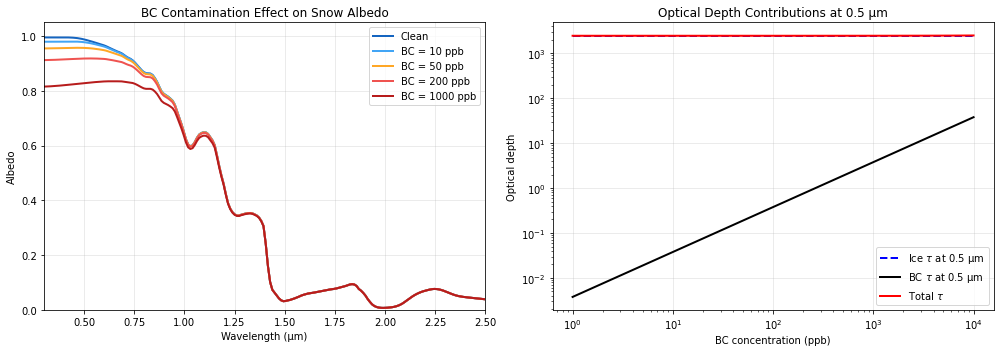

In [22]:
# Impurity mixing implementation

def mix_impurities(tau_ice, ssa_ice, g_ice, impurities, snow_mass_path):
    """Mix impurities into ice optical properties.

    Parameters
    ----------
    tau_ice, ssa_ice, g_ice : array — clean ice optical properties
    impurities : list of (name, conc) tuples
        For unit=0 (BC, dust): conc in ppb (parts per billion by mass)
        For unit=1 (algae): conc in cells/mL
    snow_mass_path : float — L_snow in kg/m² (= rho * dz)

    Returns
    -------
    tau_total, ssa_total, g_total : array — mixed optical properties
    """
    tau_total = tau_ice.copy()
    ssa_weighted = ssa_ice * tau_ice
    g_weighted = ssa_ice * g_ice * tau_ice

    for name, conc in impurities:
        if name not in LAP_DATA:
            continue
        imp_data = LAP_DATA[name]
        mac = imp_data["mac"]   # m²/kg (unit=0) or m²/cell (unit=1)
        ssa_imp = imp_data["ssa"]
        g_imp = imp_data["g"]
        unit = imp_data.get("unit", 0)

        if unit == 1:
            # Algae: conc in cells/mL → cells/kg → cells/m² → optical depth
            # Following BioSNICAR: mss_aer = conc / 917 * 1e6  (cells/kg)
            # L_aer = L_snow * mss_aer  (cells/m²)
            # tau = L_aer * ext_xsc  (dimensionless)
            cells_per_kg = conc * 1e6 / 917.0  # cells/mL → cells/kg_ice
            L_aer = snow_mass_path * cells_per_kg  # cells/m²
            tau_imp = L_aer * mac  # cells/m² × m²/cell
        else:
            # BC/dust: conc in ppb by mass
            mass_ratio = conc * 1e-9  # ppb → mass fraction
            tau_imp = snow_mass_path * mass_ratio * mac

        tau_total += tau_imp
        ssa_weighted += ssa_imp * tau_imp
        g_weighted += ssa_imp * g_imp * tau_imp

    # Effective properties
    ssa_total = np.where(tau_total > 0, ssa_weighted / tau_total, 1.0)
    g_total = np.where(ssa_weighted > 0, g_weighted / ssa_weighted, 0.0)

    return tau_total, np.clip(ssa_total, 0, 1), g_total

# Demo: clean vs dirty snow
r_grain = 200  # µm
rho_snow = 300  # kg/m³
dz_snow = 1.0  # m
L_snow = rho_snow * dz_snow

qext, qsca, qabs, ssa_ice, g_ice = mie_sphere(r_grain, WVL_FAST, N_RE, N_IM)
mac_ice = 3 * qext / (4 * r_grain * 1e-6 * RHO_ICE)
tau_ice = mac_ice * L_snow

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Clean snow
R_clean, _ = single_layer_albedo(tau_ice, ssa_ice, g_ice, mu0=0.5)

# With BC at various concentrations
bc_concs = [0, 10, 50, 200, 1000]  # ppb
bc_colors = ["#1565C0", "#42A5F5", "#FFA726", "#EF5350", "#B71C1C"]

for conc, c in zip(bc_concs, bc_colors):
    if conc == 0:
        ax1.plot(WVL_FAST, R_clean, color=c, lw=2, label="Clean")
    else:
        tau_m, ssa_m, g_m = mix_impurities(tau_ice, ssa_ice, g_ice,
                                           [("black_carbon", conc)], L_snow)
        R_dirty, _ = single_layer_albedo(tau_m, ssa_m, g_m, mu0=0.5)
        ax1.plot(WVL_FAST, R_dirty, color=c, lw=2, label=f"BC = {conc} ppb")

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Albedo")
ax1.set_title("BC Contamination Effect on Snow Albedo")
ax1.set_xlim(0.3, 2.5)
ax1.set_ylim(0, 1.05)
ax1.legend()

# Optical depth contributions at 0.5 µm
idx_05 = np.argmin(np.abs(WVL_FAST - 0.5))
bc_range = np.logspace(0, 4, 50)
tau_ice_vis = tau_ice[idx_05]
tau_bc_vis = np.array([L_snow * c * 1e-9 * LAP_DATA["black_carbon"]["mac"][idx_05]
                       for c in bc_range])

ax2.loglog(bc_range, np.full_like(bc_range, tau_ice_vis), "b--", lw=2,
           label="Ice $\\tau$ at 0.5 µm")
ax2.loglog(bc_range, tau_bc_vis, "k-", lw=2, label="BC $\\tau$ at 0.5 µm")
ax2.loglog(bc_range, tau_ice_vis + tau_bc_vis, "r-", lw=2, label="Total $\\tau$")
ax2.set_xlabel("BC concentration (ppb)")
ax2.set_ylabel("Optical depth")
ax2.set_title("Optical Depth Contributions at 0.5 µm")
ax2.legend()

plt.tight_layout()
plt.show()


Key physics:

- **BC darkens the visible** dramatically — even 10 ppb is visible.
  At 1000 ppb, visible albedo drops from ~0.98 to ~0.6.
- **NIR is barely affected** by BC because ice itself already absorbs
  strongly there — the BC contribution is small relative to ice absorption.
- The right panel shows why: at 0.5 µm, BC optical depth exceeds ice
  absorption optical depth at ~50 ppb, despite being $10^{-7}$ of the mass.

> **BioSNICAR connection** — `biosnicar/optical_properties/column_OPs.py:576–689`
> → `mix_in_impurities()` implements exactly these mixing rules.


## Section 15 — Black Carbon: The Dominant Light Absorber

### What is black carbon?

Black carbon (BC, also called soot) is a material produced by the
**incomplete combustion** of fossil fuels, biomass, and biofuels.
It consists of small spherules of nearly pure carbon, typically 20–50 nm
in diameter, that aggregate into chain-like clusters.  It is the substance
that makes chimney soot, diesel exhaust, and wildfire smoke dark.

### Why BC is so effective at absorbing light

BC is the strongest light-absorbing aerosol per unit mass in the atmosphere.
Its optical properties:

| Property | Value | Comparison to ice |
|----------|-------|------------------|
| MAC at 550 nm | 7–11 m²/g | **~1,000,000×** ice's absorption |
| Spectral dependence | $\text{MAC} \propto \lambda^{-1}$ | Nearly flat ("grey absorber") |
| SSA ($\tilde{\omega}$) | 0.2–0.4 | Ice has $\tilde{\omega} > 0.999$ in VIS |
| Asymmetry $g$ | ~0.5 | Ice grains have $g \approx 0.87$ |

The physical origin of BC's enormous absorption is its electronic structure:
carbon's delocalised $\pi$-electrons can absorb photons across a wide range
of wavelengths (similar to graphite), unlike most other aerosols whose
absorption is limited to specific molecular resonances.  This is why BC
appears **black** — it absorbs all visible colours nearly equally.

### The snow-albedo feedback amplified by BC

Even at parts-per-billion (ppb) concentrations — literally one BC particle
for every billion ice molecules by mass — BC can reduce snow albedo by
1–5% in the visible.  This is enough to significantly accelerate melting
through a positive feedback loop:

1. BC darkens the snow surface (absorbs visible light)
2. More solar energy is absorbed → snow temperature rises
3. Warmer snow → faster grain metamorphism → larger grains → lower NIR albedo
4. More melting → BC concentrates at the surface (BC doesn't melt away)
5. Return to step 1, amplified

BioSNICAR offers two BC representations:
- **Uncoated** (`mie_sot_ChC90_dns_1317`): Fresh BC, recently emitted
- **Sulfate-coated** (`miecot_slfsot_ChC90_dns_1317`): Aged BC that has
  acquired a transparent sulfate coating during atmospheric transport.
  The coating acts as a **lens**, focusing light onto the BC core and
  increasing the effective MAC by ~50%.


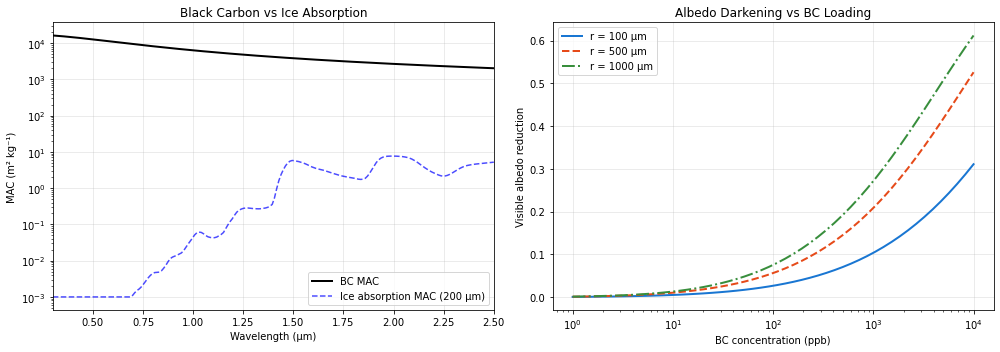

In [23]:
# BC MAC spectrum and albedo reduction

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BC MAC spectrum
bc_mac = LAP_DATA["black_carbon"]["mac"]
bc_ssa = LAP_DATA["black_carbon"]["ssa"]

ax1.semilogy(WVL_FAST, bc_mac, "k-", lw=2, label="BC MAC")

# Compare with ice "effective MAC" (absorption only) for a 200 µm grain
_, _, qabs_ice, _, _ = mie_sphere(200, WVL_FAST, N_RE, N_IM)
mac_abs_ice = 3 * qabs_ice / (4 * 200e-6 * RHO_ICE)
ax1.semilogy(WVL_FAST, np.maximum(mac_abs_ice, 1e-3), "b--", lw=1.5,
             alpha=0.7, label="Ice absorption MAC (200 µm)")

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("MAC (m² kg⁻¹)")
ax1.set_title("Black Carbon vs Ice Absorption")
ax1.set_xlim(0.3, 2.5)
ax1.legend()

# Albedo reduction as a function of BC concentration
vis_mask = (WVL_FAST >= 0.4) & (WVL_FAST <= 0.7)
bc_range = np.logspace(0, 4, 50)

for r, c, ls in [(100, "#1976D2", "-"), (500, "#E64A19", "--"), (1000, "#388E3C", "-.")]:
    qext, qsca, qabs, ssa_i, g_i = mie_sphere(r, WVL_FAST, N_RE, N_IM)
    mac_i = 3 * qext / (4 * r * 1e-6 * RHO_ICE)
    tau_i = mac_i * L_snow

    delta_alb = []
    R_clean, _ = single_layer_albedo(tau_i, ssa_i, g_i, 0.5)
    alb_clean = np.mean(R_clean[vis_mask])

    for conc in bc_range:
        tau_m, ssa_m, g_m = mix_impurities(tau_i, ssa_i, g_i,
                                            [("black_carbon", conc)], L_snow)
        R_dirty, _ = single_layer_albedo(tau_m, ssa_m, g_m, 0.5)
        delta_alb.append(alb_clean - np.mean(R_dirty[vis_mask]))

    ax2.semilogx(bc_range, delta_alb, color=c, ls=ls, lw=2, label=f"r = {r} µm")

ax2.set_xlabel("BC concentration (ppb)")
ax2.set_ylabel("Visible albedo reduction")
ax2.set_title("Albedo Darkening vs BC Loading")
ax2.legend()

plt.tight_layout()
plt.show()


The left panel shows why BC is so effective: its MAC exceeds ice's absorption
by 4–6 orders of magnitude in the visible.  Even at 1 ppb ($10^{-9}$ mass
fraction), BC's contribution to visible absorption is comparable to ice's own.

Smaller grains are more sensitive to BC (right panel).  The intuition:
in fine-grained snow, a photon scatters many times, taking a long random walk
with many opportunities to encounter BC particles.  In coarse-grained snow,
the photon takes fewer but longer steps through absorbing ice, so it is more
likely to be absorbed by the ice itself before encountering BC.  Equivalently,
clean fine snow has higher visible albedo to begin with — there's more room
to darken.  This is the "grain-size–impurity coupling".

The **snow-albedo feedback** amplifies BC's effect: BC reduces albedo → more
solar absorption → snow warms and grains grow → albedo drops further
(grain growth effect) → more melting exposes more BC (concentration effect).
This positive feedback makes BC one of the most important climate-relevant
aerosols in snow-covered regions.

Typical BC concentrations in snow:
| Location | BC (ppb) |
|----------|----------|
| Arctic remote | 1–5 |
| Arctic near sources | 10–50 |
| Alpine/mid-latitude | 5–100 |
| Industrial regions | 50–500 |
| Near fires | 100–5000 |

> **BioSNICAR connection** — BC optical properties are in `data/OP_data/480band/lap.npz`
> under keys `bc_ChCB_rn40_dns1270__*` (uncoated) and `miecot_slfsot_*` (coated).
> The uncoated BC has MAC ≈ 7.5 m² g$^{-1}$ at 550 nm; the coated version
> is ~1.5× higher due to the sulfate shell acting as a lens.  The choice
> between coated and uncoated depends on the assumed ageing state of the BC
> and is configured in `inputs.yaml`.


## Section 16 — Mineral Dust

### What is mineral dust?

Mineral dust consists of small particles of **weathered rock** that are
lifted by wind from arid and semi-arid regions (deserts, dried lake beds,
glacial outwash plains).  These particles can travel thousands of kilometres
through the atmosphere before being deposited on snow and ice surfaces.

A crucial point is that **"mineral dust" is not a single substance**.  Its
composition — and therefore its optical properties — varies enormously
depending on the source geology.  The minerals commonly found in dust
include:

| Mineral | Effect | Typical abundance |
|---------|--------|-------------------|
| **Quartz** (SiO₂) | Scattering only (transparent in VIS) | 10–70% |
| **Feldspars** (NaAlSi₃O₈ etc.) | Very weak absorption | 5–30% |
| **Clay minerals** (illite, kaolinite, montmorillonite) | Weak absorption | 20–60% |
| **Hematite** (Fe₂O₃) | **Strong** red/VIS absorption | 0–5% |
| **Goethite** (FeOOH) | **Strong** blue/UV absorption | 0–10% |
| **Calcite** (CaCO₃) | Scattering only | Variable |

The key insight is that the **iron oxide fraction** (hematite + goethite)
controls almost all of the dust's ability to absorb light — even though
these minerals are often only a few percent of the total mass.

### Why dust absorbs: the role of iron oxides

Iron oxides absorb through **electronic transitions** in the Fe³⁺ ion:

- **Charge transfer transitions** (O²⁻ → Fe³⁺): Strong absorption in the UV
  and blue (0.3–0.5 µm).  This is why iron-rich dust looks red or brown —
  it absorbs blue light and transmits/reflects red.
- **Crystal field transitions**: Weaker absorption bands in the visible.
- **No significant absorption beyond ~0.8 µm**: Iron oxide electronic
  transitions do not extend into the NIR, so dust is essentially
  transparent there.

This wavelength dependence is fundamentally different from BC:

| Property | Black carbon | Iron-rich dust | Iron-poor dust |
|----------|-------------|----------------|----------------|
| Absorption mechanism | Broadband electronic (graphitic) | Narrow electronic (Fe³⁺) | Negligible |
| Spectral shape | Nearly flat across VIS | Strong blue, weak red | Nearly transparent |
| MAC at 0.5 µm | ~10,000 m² kg⁻¹ | ~300–500 m² kg⁻¹ | ~60–70 m² kg⁻¹ |
| SSA at 0.5 µm | 0.2–0.4 | 0.87–0.92 | 0.95–0.99 |
| Colour on snow | Grey | Orange/pink/brown | Grey/tan |

### Spatial variability: not all dust is the same

This is perhaps the most important message about mineral dust in
cryospheric science: **the optical properties of dust depend strongly
on where it comes from**.  Some examples:

**Iron-rich dust (strong absorber):**
- **Saharan dust**: High hematite/goethite content (3–7%), intensely
  red-brown, strong VIS absorption.  Regularly deposited on European
  Alps, reaching as far as Greenland's coast.
- **Asian loess**: Variable iron content, typically intermediate
  absorption strength.  Reaches the Pacific and Western North America.
- **Colorado Plateau dust** (Skiles et al.): Red sandstone-derived,
  iron-rich, strong absorber.  Causes dramatic dust-on-snow events in
  the Rocky Mountains that advance spring melt by 3–6 weeks.

**Iron-poor dust (weak absorber):**
- **Inland Greenland Ice Sheet dust**: Dominated by **quartz and
  feldspars** from local glacial till and exposed bedrock.  These minerals
  are nearly transparent in the visible — the dust scatters light but
  absorbs very little.  This is a critical distinction: depositing
  100 ppm of Saharan dust on snow has a *vastly* different radiative
  effect than depositing 100 ppm of local Greenland dust.
- **Antarctic dust**: Often from local moraines, variable but frequently
  low in iron oxides.

BioSNICAR reflects this variability by including multiple dust datasets:

| Dataset | Source region | Iron content | Absorption strength |
|---------|-------------|-------------|-------------------|
| `dust_balkanski_central` | Global average (Balkanski et al.) | Moderate | Medium |
| `dust_skiles` | Colorado Plateau (Skiles et al.) | High | Strong |
| `dust_greenland_central` | Greenland (general) | Moderate | Medium |
| `dust_greenland_Cook` | Greenland inland (Cook et al.) | **Very low** | **Weak** |
| `dust_mars` | Mars analogue | Variable | Medium-strong |

Each dataset has five size classes (0.05–5 µm radius), and the optical
properties differ not just in magnitude but in spectral shape, because the
iron oxide content determines *which wavelengths* are absorbed.

### Size matters

Dust particles span a wide range of sizes (0.1–100 µm radius), and size
affects both the MAC and the SSA.  Larger particles:

- Have **lower MAC** per unit mass (less surface area per mass)
- Have **lower SSA** (more absorption per scattering event, because photons
  travel further inside each grain)
- **Settle faster** from the atmosphere and the snow surface

In practice, the mixture of sizes depends on the dust source and transport
distance: long-range transported dust tends to be finer (the larger
particles settled out during transport), while locally-sourced dust can be
coarser.

### Global context

Despite being a weaker absorber per unit mass than BC, dust is the
**dominant light-absorbing impurity** on many snow and ice surfaces because:

1. **Deposition rates are much higher**: Typical dust concentrations on snow
   are 1–100 ppm, compared to 1–100 ppb for BC — three orders of magnitude
   more mass.
2. **Large-scale transport**: Saharan dust regularly reaches the European
   Alps, Rocky Mountains, and even the Arctic.  Asian dust reaches the
   Pacific and Western North America.
3. **Dust-on-snow events**: Episodic deposition can deposit visible layers
   of dust that persist through the melt season, progressively concentrating
   at the surface as snow melts.

However, the radiative impact of a given mass of dust varies hugely
depending on mineralogy.  Models that treat "dust" as a single substance
with fixed optical properties can substantially over- or under-estimate
its effect.  This is why BioSNICAR provides region-specific dust datasets
rather than a single generic "dust" type.


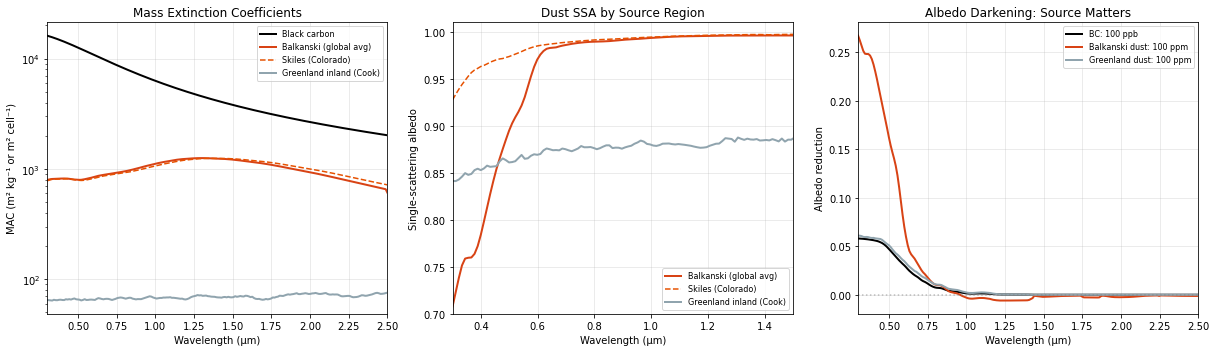

In [24]:
# Dust optical properties — comparing dust types and BC

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Panel 1: MAC comparison across dust types ---
ax1 = axes[0]
ax1.semilogy(WVL_FAST, bc_mac, "k-", lw=2, label="Black carbon")
ax1.semilogy(WVL_FAST, LAP_DATA["dust"]["mac"], color="#D84315", lw=2,
             label="Balkanski (global avg)")
if "dust_skiles" in LAP_DATA:
    ax1.semilogy(WVL_FAST, LAP_DATA["dust_skiles"]["mac"], color="#E65100", lw=1.5,
                 ls="--", label="Skiles (Colorado)")
if "dust_greenland" in LAP_DATA:
    ax1.semilogy(WVL_FAST, LAP_DATA["dust_greenland"]["mac"], color="#90A4AE", lw=2,
                 label="Greenland inland (Cook)")
ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("MAC (m² kg⁻¹ or m² cell⁻¹)")
ax1.set_title("Mass Extinction Coefficients")
ax1.set_xlim(0.3, 2.5)
ax1.legend(fontsize=8)

# --- Panel 2: SSA comparison (shows scattering vs absorption split) ---
ax2 = axes[1]
ax2.plot(WVL_FAST, LAP_DATA["dust"]["ssa"], color="#D84315", lw=2,
         label="Balkanski (global avg)")
if "dust_skiles" in LAP_DATA:
    ax2.plot(WVL_FAST, LAP_DATA["dust_skiles"]["ssa"], color="#E65100", lw=1.5,
             ls="--", label="Skiles (Colorado)")
if "dust_greenland" in LAP_DATA:
    ax2.plot(WVL_FAST, LAP_DATA["dust_greenland"]["ssa"], color="#90A4AE", lw=2,
             label="Greenland inland (Cook)")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Single-scattering albedo")
ax2.set_title("Dust SSA by Source Region")
ax2.set_xlim(0.3, 1.5)
ax2.set_ylim(0.7, 1.01)
ax2.legend(fontsize=8)

# --- Panel 3: Albedo impact of different dust types ---
ax3 = axes[2]
r_grain = 200
qext, qsca, qabs, ssa_i, g_i = mie_sphere(r_grain, WVL_FAST, N_RE, N_IM)
mac_i = 3 * qext / (4 * r_grain * 1e-6 * RHO_ICE)
tau_i = mac_i * L_snow
R_clean, _ = single_layer_albedo(tau_i, ssa_i, g_i, 0.5)

# 100 ppb BC vs 100 ppm of different dust types
for name, conc, c, ls, label in [
    ("black_carbon", 100, "k", "-", "BC: 100 ppb"),
    ("dust", 100_000, "#D84315", "-", "Balkanski dust: 100 ppm"),
    ("dust_greenland", 100_000, "#90A4AE", "-", "Greenland dust: 100 ppm"),
]:
    if name in LAP_DATA:
        tau_m, ssa_m, g_m = mix_impurities(tau_i, ssa_i, g_i, [(name, conc)], L_snow)
        R_dirty, _ = single_layer_albedo(tau_m, ssa_m, g_m, 0.5)
        ax3.plot(WVL_FAST, R_clean - R_dirty, color=c, lw=2, ls=ls, label=label)

ax3.set_xlabel("Wavelength (µm)")
ax3.set_ylabel("Albedo reduction")
ax3.set_title("Albedo Darkening: Source Matters")
ax3.set_xlim(0.3, 2.5)
ax3.axhline(0, color="gray", ls=":", alpha=0.5)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()


These plots illustrate several critical points:

**Panel 1 — Mass extinction coefficients:**  All dust types have MAC values
orders of magnitude lower than BC (note the log scale).  But look at the
*differences between dust types*: the Balkanski (global average) and Skiles
(Colorado) dusts have similar MAC spectra — both are iron-oxide-rich and
show strong extinction across the visible.  The Greenland inland dust
(Cook et al.) has MAC roughly **5× lower** — these are quartz- and
feldspar-dominated particles that scatter light efficiently but absorb
very little.

**Panel 2 — Single-scattering albedo:**  The SSA reveals the split between
scattering and absorption.  Counterintuitively, the Greenland dust has
a *lower* SSA despite being mineralogically "weaker" — this reflects
differences in particle size distribution and geometry, not just composition.
The key point is that SSA varies substantially between dust sources, and
assuming a single SSA for all "dust" can lead to large errors.

**Panel 3 — Albedo impact:**  At the same mass concentration (100 ppm),
iron-rich Balkanski dust causes substantially more visible-wavelength
darkening than the iron-poor Greenland dust.  Both show the characteristic
blue-dominant spectral signature of iron oxide absorption, but the magnitude
differs enormously.  Compare with BC at 100 ppb — despite being 1000×
less mass, BC causes comparable darkening because of its extremely high
mass absorption coefficient.

### Spectral fingerprints for remote sensing

These spectral differences enable **remote sensing discrimination**
of impurity types.  A satellite observing snow in the blue (0.45 µm) and
red (0.67 µm) can distinguish:
- **Clean snow**: High albedo in both bands
- **BC contamination**: Equal darkening in both bands
- **Dust contamination**: Blue darkened more than red
- **Algae contamination**: Red darkened more than blue (see next sections)

However, discriminating *between dust types* from spectral observations
alone is extremely challenging — the spectral shape is similar (both
controlled by Fe³⁺ transitions), only the magnitude differs.  This
highlights the importance of knowing the dust source when interpreting
field or satellite measurements.

> **BioSNICAR connection** — Dust data in `lap.npz` includes multiple
> regional datasets: `dust_balkanski_central`, `dust_skiles`,
> `dust_greenland_central`, `dust_greenland_Cook`, and `dust_mars`.
> Each has five size classes (radii ~0.05–5 µm).  Choosing the
> appropriate dataset for your study region is essential — using
> Saharan dust properties for local Greenland till, or vice versa,
> can introduce order-of-magnitude errors in radiative forcing estimates.


## Section 17 — Snow Algae

Snow algae (*Chlamydomonas nivalis* and relatives) are photosynthetic
organisms that darken the snow surface.  They are spherical cells (~10–15 µm
radius) containing photosynthetic and photoprotective pigments:

- **Chlorophyll a/b**: Strong absorption at 0.44 and 0.68 µm (blue and red)
- **Carotenoids**: Broad absorption at 0.45–0.55 µm (blue-green)
- **Secondary carotenoids** (astaxanthin): Broad absorption giving "watermelon
  snow" its pink-red colour

### Algae unit handling: cells/mL vs ppb

Unlike mineral impurities (BC, dust), which are measured in **parts per
billion by mass** (ppb), algae concentrations are measured in **cells per
mL** of meltwater.  This reflects how biologists actually measure algae in
the field — by melting a snow sample and counting cells under a microscope
or with a flow cytometer.

The optical property associated with each algae cell is the **extinction
cross-section** $\sigma_{\text{ext}}$ (m² per cell), not the mass
extinction coefficient MAC (m² per kg).  The conversion from concentration
to optical depth follows:

1. Convert cells/mL to cells per kg of ice:
   $n_{\text{cells/kg}} = c_{\text{cells/mL}} \times 10^6 / 917$
2. Multiply by the snow mass path $L = \rho \cdot \Delta z$ (kg/m²)
   to get cells per unit area: $N = L \times n_{\text{cells/kg}}$ (cells/m²)
3. Multiply by the per-cell cross-section:
   $\tau_{\text{algae}} = N \times \sigma_{\text{ext}}$ (dimensionless)

This matches BioSNICAR's implementation in `column_OPs.py:623–627`, where
`unit == 1` triggers the cell-count conversion pathway.  The per-cell
cross-sections are stored in `lap.npz` under the `__ext_xsc` suffix,
while mass-based impurities use `__ext_cff_mss`.

Typical field concentrations:
- Clean snow: 0 cells/mL
- Light bloom: 1,000–10,000 cells/mL
- Heavy bloom: 50,000–500,000 cells/mL
- Extreme (red snow): >1,000,000 cells/mL

Key difference from BC: algae absorption is **wavelength-selective**
(pigment bands), while BC is broadband.  At visible wavelengths,
algae can be more effective per unit mass than BC because the pigment
absorption cross-sections are very high.


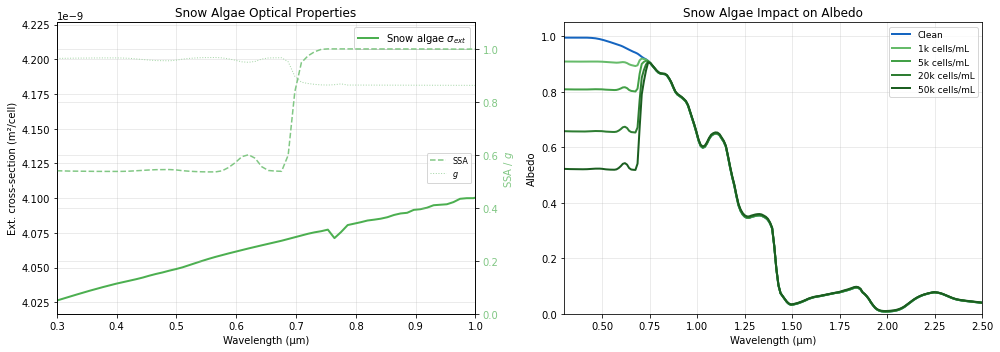

In [25]:
# Snow algae optical properties and albedo impact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Algae extinction cross-section spectrum
alg = LAP_DATA["snow_algae"]
is_xsc = alg.get("unit", 0) == 1
ylabel_left = "Ext. cross-section (m²/cell)" if is_xsc else "MAC (m² kg⁻¹)"
ax1.plot(WVL_FAST, alg["mac"], color="#4CAF50", lw=2,
         label="Snow algae " + ("$\sigma_{ext}$" if is_xsc else "MAC"))
ax1_twin = ax1.twinx()
ax1_twin.plot(WVL_FAST, alg["ssa"], color="#81C784", lw=1.5, ls="--", label="SSA")
ax1_twin.plot(WVL_FAST, alg["g"], color="#A5D6A7", lw=1, ls=":", label="$g$")
ax1_twin.set_ylabel("SSA / $g$", color="#81C784")
ax1_twin.tick_params(axis="y", labelcolor="#81C784")
ax1_twin.set_ylim(0, 1.1)
ax1_twin.legend(loc="center right", fontsize=8)

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel(ylabel_left)
ax1.set_title("Snow Algae Optical Properties")
ax1.set_xlim(0.3, 1.0)
ax1.legend(loc="upper right")

# Albedo with algae at various concentrations (cells/mL)
# Typical field concentrations: 1k–100k cells/mL (100k is extreme)
algae_concs = [0, 1000, 5000, 20000, 50000]  # cells/mL
algae_colors = ["#1565C0", "#66BB6A", "#43A047", "#2E7D32", "#1B5E20"]

for conc, c in zip(algae_concs, algae_colors):
    if conc == 0:
        ax2.plot(WVL_FAST, R_clean, color=c, lw=2, label="Clean")
    else:
        tau_m, ssa_m, g_m = mix_impurities(tau_i, ssa_i, g_i,
                                            [("snow_algae", conc)], L_snow)
        R_dirty, _ = single_layer_albedo(tau_m, ssa_m, g_m, 0.5)
        lbl = f"{conc/1000:.0f}k cells/mL"
        ax2.plot(WVL_FAST, R_dirty, color=c, lw=2, label=lbl)

ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Albedo")
ax2.set_title("Snow Algae Impact on Albedo")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


Algae create a distinctive spectral signature:

- **Red-edge**: Strong absorption at 0.68 µm (chlorophyll), creating a
  characteristic dip.
- **Green window**: Relative minimum in absorption around 0.55 µm — this is
  why green algae appear green.
- **NIR unaffected**: Like BC and dust, algae don't compete with ice
  absorption in the NIR.

This wavelength-specific signature makes algae potentially **distinguishable**
from BC and dust in remote sensing, unlike the spectrally similar effects
of grain size and BC.

> **Important caveat** — Unlike BC, dust, and glacier algae, the snow algae
> optical properties in BioSNICAR are **not empirically measured**.  They are
> derived from a **pigment mixing model** (bio-optical model) that combines
> measured pigment absorption spectra with Mie theory for homogeneous spheres.
> This model produces a sharp absorption cutoff at ~0.7 µm (the red edge of
> the pigment absorption), where the single-scattering albedo jumps from ~0.55
> to ~1.0 over just 40 nm.  This creates an unnaturally sharp spectral step
> in albedo that real algae (with their heterogeneous internal structure,
> multiple pigment pools, and cell wall scattering) are unlikely to produce
> so abruptly.  Interpret snow algae results as qualitative indicators of
> biological darkening effects rather than quantitative predictions.
>
> The glacier algae dataset (Chevrollier et al. 2023, used in Section 18)
> is empirically derived from field measurements and is more trustworthy.

> **BioSNICAR connection** — Snow algae optical properties are computed by
> the bio-optical model in `biosnicar/biooptical/biooptical_funcs.py`, which
> calculates MAC from pigment concentrations, cell size, and intracellular
> absorption.  Pre-computed results are stored in `lap.npz`.


## Section 18 — Glacier Algae

### A different kind of ice organism

Glacier algae (*Ancylonema nordenskiöldii*, *Mesotaenium berggrenii*) are
fundamentally different organisms from snow algae, occupying a different
ecological niche and posing different optical modelling challenges.

| Property | Snow algae | Glacier algae |
|----------|-----------|---------------|
| Cell shape | Spherical (~10–15 µm radius) | Cylindrical (~4 µm × 40 µm) |
| Pigments | Chlorophyll + carotenoids | Chlorophyll + purpurogallin |
| Habitat | Wet, melting snow surface | Bare glacier ice surface |
| Colour | Pink/green/orange | Dark brown/purple |
| Typical blooms | Mountain snowfields, spring/summer | Greenland, Alpine glaciers |
| Optical model | Mie theory (spheres) | Geometric optics (cylinders) |

### Purpurogallin: nature's broadband absorber

The key optical difference is the **purpurogallin-type phenolic pigments**
found in glacier algae cell walls.  These pigments:

- Absorb across an extremely **broad spectral range** (0.35–0.70 µm),
  unlike chlorophyll's narrow absorption bands
- Are located in the **cell wall**, not the chloroplast, forming a
  UV/VIS-absorbing shield around the cell
- Function as **photoprotection** — shielding the photosynthetic machinery
  from the intense UV and visible radiation on bare ice surfaces
- Have a combined effect that makes glacier algae among the most effective
  biological darkening agents per cell, because the absorption fills in the
  "green window" between chlorophyll's blue and red peaks

The result is that glacier algae cells appear almost **black** under the
microscope — they absorb efficiently across almost all visible wavelengths.

### Cylindrical cells and geometric optics

Because glacier algae cells are elongated cylinders (~4 µm diameter × ~40 µm
long), Mie theory for spheres is not appropriate.  Instead, BioSNICAR uses
either:

1. **Geometric optics for cylinders**: Ray-tracing through a cylinder with
   the appropriate complex refractive index, integrating over random
   orientations.  This is computationally expensive.
2. **Empirical parameterisations**: The Chevrollier et al. (2023) dataset
   provides measured optical properties (extinction cross-section, SSA, $g$)
   as a function of wavelength, calibrated against field measurements.  This
   is BioSNICAR's default approach.

The empirical approach has the advantage of naturally capturing the complex
internal structure of real cells (pigment distribution, cell wall
structure, vacuoles), which a simple homogeneous cylinder model would miss.

### The Dark Zone of Greenland

The western margin of the Greenland Ice Sheet has a distinctive band of
darkened bare ice during summer, known as the **Dark Zone**.  This 20–30 km
wide band has albedo as low as 0.3 (compared to ~0.55 for clean bare ice),
and biological darkening by glacier algae is now recognised as the
**primary driver** of this albedo reduction.

The positive feedback is powerful:
1. Algae darken the ice surface → more solar absorption → more melting
2. Melting provides liquid water → algae grow faster
3. Surface lowering concentrates algae and other impurities → more darkening
4. Melt exposes sub-surface algae → even more darkening

Understanding and modelling this feedback is critical for Greenland Ice
Sheet mass balance projections, making accurate glacier algae optical
properties essential for BioSNICAR.


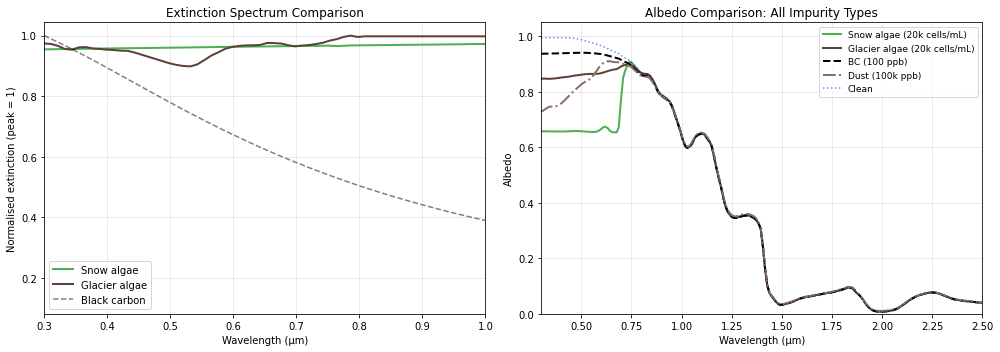

In [26]:
# Glacier algae vs snow algae comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ga = LAP_DATA["glacier_algae"]
sa = LAP_DATA["snow_algae"]

# Extinction spectrum comparison (note different units for algae vs BC)
# For display, normalise all to peak=1 so shapes can be compared
sa_norm = sa["mac"] / np.max(sa["mac"])
ga_norm = ga["mac"] / np.max(ga["mac"])
bc_norm = bc_mac / np.max(bc_mac)
ax1.plot(WVL_FAST, sa_norm, color="#4CAF50", lw=2, label="Snow algae")
ax1.plot(WVL_FAST, ga_norm, color="#5D4037", lw=2, label="Glacier algae")
ax1.plot(WVL_FAST, bc_norm, "k--", lw=1.5, alpha=0.5, label="Black carbon")
ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Normalised extinction (peak = 1)")
ax1.set_title("Extinction Spectrum Comparison")
ax1.set_xlim(0.3, 1.0)
ax1.legend()

# Albedo impact comparison — realistic concentrations
# Algae in cells/mL, BC in ppb, dust in ppb
for name, label, c, ls in [
    ("snow_algae", "Snow algae (20k cells/mL)", "#4CAF50", "-"),
    ("glacier_algae", "Glacier algae (20k cells/mL)", "#5D4037", "-"),
    ("black_carbon", "BC (100 ppb)", "black", "--"),
    ("dust", "Dust (100k ppb)", "#8D6E63", "-."),
]:
    conc = {"snow_algae": 20000, "glacier_algae": 20000,
            "black_carbon": 100, "dust": 100000}[name]
    tau_m, ssa_m, g_m = mix_impurities(tau_i, ssa_i, g_i, [(name, conc)], L_snow)
    R_dirty, _ = single_layer_albedo(tau_m, ssa_m, g_m, 0.5)
    ax2.plot(WVL_FAST, R_dirty, color=c, ls=ls, lw=2, label=label)

ax2.plot(WVL_FAST, R_clean, "b:", lw=1.5, alpha=0.5, label="Clean")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Albedo")
ax2.set_title("Albedo Comparison: All Impurity Types")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


The comparison reveals each impurity's distinct **spectral fingerprint**:

- **BC**: Broadband, spectrally flat visible darkening — the "grey absorber".
  All visible wavelengths are equally affected.
- **Dust**: Blue-dominant darkening from iron oxide absorption, negligible
  beyond 0.8 µm.  Gives snow an orange/pink tint.
- **Snow algae**: Sharp chlorophyll absorption bands at 0.44 and 0.68 µm,
  with a characteristic "green peak" between them (the reflected green light
  gives snow its sometimes-green colour during blooms).
- **Glacier algae**: Broad, strong absorption across 0.35–0.7 µm —
  purpurogallin fills the green window, so the spectral signature lacks
  the green peak seen in snow algae.  The nearly flat VIS absorption
  is reminiscent of BC but at different absolute magnitudes.

### Why spectral fingerprints matter

These differences are the foundation for **remote sensing retrievals**
of impurity type and concentration.  By measuring reflectance at multiple
wavelengths, we can solve an inverse problem:

1. **Broadband VIS darkening** → likely BC or glacier algae
2. **Blue-only darkening** → likely dust
3. **0.68 µm absorption dip** → likely snow algae (chlorophyll red-edge)
4. **Ratio of blue to red darkening** → distinguishes dust from algae mixtures

This is exactly the problem addressed by BioSNICAR's inverse module, which
uses the forward model spectra shown here to retrieve impurity concentrations
from measured reflectance data.

> **BioSNICAR connection** — Glacier algae optical properties are in `lap.npz`
> under `ice_algae_empirical_Chevrollier2023__*` (default) or
> `Cook2020_glacier_algae_4_40__*` (alternative parameterisation).
> The bio-optical model in `biosnicar/biooptical/` can generate custom algae
> optical properties from cell dimensions and pigment concentrations.


---
# Act V: The Complete BioSNICAR Solver

## Section 19 — Fresnel Reflection at the Air-Ice Interface

### Why boundaries cause reflections

When light crosses the boundary between two media with different refractive
indices, it must satisfy **electromagnetic boundary conditions** — the
tangential electric and magnetic fields must be continuous across the
interface.  The only way to satisfy these conditions for a wave arriving
from one side is to have *both* a transmitted wave (continuing into the
second medium) *and* a reflected wave (going back into the first medium).

This is a universal wave phenomenon.  You see it every day:
- **Windows at night**: You see your reflection because glass ($n \approx 1.5$)
  has a different refractive index from air ($n = 1$)
- **Puddle reflections**: Water ($n = 1.33$) reflects at the air-water interface
- **Sunglasses on water**: Glare from water is partially polarised by
  Fresnel reflection, which is why polarised sunglasses reduce it

### Fresnel's equations

For unpolarised light at incidence angle $\theta_i$, Fresnel's equations
give the reflectance for each polarisation:

$$
R_s = \left| \frac{n_1 \cos\theta_i - n_2 \cos\theta_t}{n_1 \cos\theta_i + n_2 \cos\theta_t} \right|^2
\qquad
R_p = \left| \frac{n_1 \cos\theta_t - n_2 \cos\theta_i}{n_1 \cos\theta_t + n_2 \cos\theta_i} \right|^2
$$

$$
R = \frac{R_s + R_p}{2}
$$

where:
- $R_s$ is reflectance for **s-polarisation** (electric field perpendicular
  to the plane of incidence — *senkrecht*, German for perpendicular)
- $R_p$ is reflectance for **p-polarisation** (electric field parallel to
  the plane of incidence)
- $\theta_t$ is the refracted angle from **Snell's law**:
  $n_1 \sin\theta_i = n_2 \sin\theta_t$

At **normal incidence** ($\theta_i = 0$), both polarisations give the same
result:

$$
R_0 = \left(\frac{n_1 - n_2}{n_1 + n_2}\right)^2
$$

For air → ice ($n_1 = 1, n_2 = 1.31$): $R_0 = (0.31/2.31)^2 \approx 1.8\%$.
This is small but non-negligible for precise modelling.

### Two special angles

1. **Brewster's angle** ($\theta_B = \arctan(n_2/n_1) \approx 52.6°$ for
   air→ice): The p-polarised component has **zero reflection**.  All reflected
   light is s-polarised.  This is why the reflected glare from ice or water
   is partially polarised — and why polarised sunglasses work.

2. **Critical angle for total internal reflection (TIR)**: When light travels
   from a denser medium to a less dense one (ice → air), there exists a
   critical angle $\theta_c = \arcsin(n_1/n_2) \approx 49.7°$ beyond which
   **all** light is reflected — none is transmitted.  This traps a significant
   fraction of diffuse light inside ice, enhancing absorption.

### When does Fresnel matter for snow and ice?

For **granular snow** (BioSNICAR `layer_type = 0`): Fresnel reflection is
**negligible**.  There is no single flat air-ice interface — instead, the
surface consists of a rough collection of ice grains with air-filled pores.
The incoming beam is scattered by the first grains it encounters, never
"seeing" a coherent flat surface.  BioSNICAR skips the Fresnel correction
entirely for granular snow.

For **solid ice** (BioSNICAR `layer_type = 1`): There IS a flat, smooth
air-ice interface at the surface, so Fresnel reflection must be accounted
for.  This matters because:
- At normal incidence, ~2% of light is reflected before entering the ice
- At high SZA (low sun), Fresnel reflection can exceed 10%, significantly
  increasing apparent albedo
- TIR traps upward-propagating diffuse light inside the ice, increasing
  the effective path length and absorption


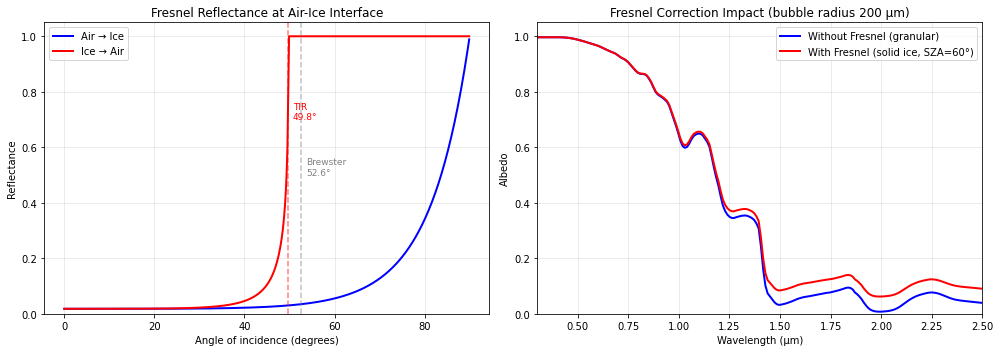

In [27]:
# Fresnel reflection at an air-ice interface

def fresnel_reflectance(theta_i_deg, n1=1.0, n2=1.31):
    """Fresnel reflectance for unpolarised light."""
    theta_i = np.radians(theta_i_deg)
    sin_t = (n1 / n2) * np.sin(theta_i)

    # Total internal reflection check
    tir = sin_t >= 1.0
    cos_i = np.cos(theta_i)
    cos_t = np.where(tir, 0.0, np.sqrt(np.maximum(1 - sin_t**2, 0)))

    Rs = np.where(tir, 1.0,
                  np.abs((n1*cos_i - n2*cos_t) / (n1*cos_i + n2*cos_t))**2)
    Rp = np.where(tir, 1.0,
                  np.abs((n1*cos_t - n2*cos_i) / (n1*cos_t + n2*cos_i))**2)
    return (Rs + Rp) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fresnel reflectance vs angle (air → ice)
angles = np.linspace(0, 89.9, 500)
R_air_ice = fresnel_reflectance(angles, 1.0, 1.31)
R_ice_air = fresnel_reflectance(angles, 1.31, 1.0)

ax1.plot(angles, R_air_ice, "b-", lw=2, label="Air → Ice")
ax1.plot(angles, R_ice_air, "r-", lw=2, label="Ice → Air")
# Mark Brewster angle
theta_B = np.degrees(np.arctan(1.31))
ax1.axvline(theta_B, color="gray", ls="--", alpha=0.5)
ax1.text(theta_B + 1, 0.5, f"Brewster\n{theta_B:.1f}°", fontsize=9, color="gray")
# Mark TIR
theta_c = np.degrees(np.arcsin(1.0 / 1.31))
ax1.axvline(theta_c, color="red", ls="--", alpha=0.5)
ax1.text(theta_c + 1, 0.7, f"TIR\n{theta_c:.1f}°", fontsize=9, color="red")

ax1.set_xlabel("Angle of incidence (degrees)")
ax1.set_ylabel("Reflectance")
ax1.set_title("Fresnel Reflectance at Air-Ice Interface")
ax1.legend()
ax1.set_ylim(0, 1.05)

# Right: Impact on albedo for solid ice
# Compare granular snow vs solid ice with Fresnel
r_grain = 200
qext, qsca, qabs, ssa_i, g_i = mie_sphere(r_grain, WVL_FAST, N_RE, N_IM)
mac_i = 3 * qext / (4 * r_grain * 1e-6 * RHO_ICE)
tau_i = mac_i * 500 * 1.0  # Dense ice

R_no_fresnel, _ = single_layer_albedo(tau_i, ssa_i, g_i, 0.5)

# Add Fresnel at surface (approximate: add surface reflectance)
sza = 60  # degrees
R_fresnel_surface = fresnel_reflectance(sza, 1.0, 1.31)
# Effective: Fresnel-reflected portion plus subsurface scattering of transmitted portion
R_with_fresnel = R_fresnel_surface + (1 - R_fresnel_surface)**2 * R_no_fresnel / (1 - R_fresnel_surface * R_no_fresnel)

ax2.plot(WVL_FAST, R_no_fresnel, "b-", lw=2, label="Without Fresnel (granular)")
ax2.plot(WVL_FAST, R_with_fresnel, "r-", lw=2, label="With Fresnel (solid ice, SZA=60°)")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Albedo")
ax2.set_title("Fresnel Correction Impact (bubble radius 200 µm)")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()


### Reading the plots

**Left panel (Fresnel reflectance vs angle)**:
- **Air → Ice** (blue): Reflectance starts at ~2% at normal incidence and
  rises gradually, then steeply for grazing angles ($> 80°$).  This is
  why ice surfaces appear more reflective when the sun is low.
- **Ice → Air** (red): Reflectance is higher than air→ice at all angles
  (reciprocity doesn't apply to intensity, only power).  Beyond the critical
  angle (~49.7°), reflectance is 100% — **total internal reflection** traps
  all light trying to escape.
- The **Brewster angle** (~52.6°) is where p-polarised light has zero
  reflection.  This has practical implications for polarimetric remote
  sensing of ice surfaces.

**Right panel (impact on albedo)**:
- The Fresnel correction is a **small but systematic** effect.  It slightly
  increases albedo in the visible (adding surface-reflected light that never
  enters the ice) and has less effect in the NIR (where subsurface
  absorption dominates regardless).
- The effect grows with SZA because Fresnel reflectance increases with
  incidence angle.

### Total internal reflection: a hidden absorption enhancer

TIR deserves special attention because its effect is counter-intuitive.
Light that is scattered upward *inside* the ice and hits the air-ice
interface at angles beyond ~50° is **reflected back down** into the ice.
This light gets another chance to be absorbed, effectively increasing the
optical path length.

For diffuse upwelling light inside ice (which has a broad angular
distribution), a significant fraction (~40%) hits the interface beyond the
critical angle and is trapped.  This TIR effect:
- **Reduces** the albedo of solid ice compared to what you'd expect from
  surface properties alone
- Is **absent** for granular snow (no flat interface = no TIR)
- Is one reason why solid glacier ice has lower albedo than snow of
  equivalent optical thickness

### Practical implementation

Computing Fresnel reflectance for **diffuse** radiation requires integrating
over all angles of incidence, weighted by the angular distribution of the
radiation field.  This integral is computationally expensive, so BioSNICAR
pre-computes it:

- **Direct beam**: Fresnel reflectance computed directly at the solar
  zenith angle
- **Diffuse radiation**: Pre-computed polynomial coefficients
  (`fl_r_dif_a`, `fl_r_dif_b`) give the hemispherically-averaged Fresnel
  reflectance without runtime integration

> **BioSNICAR connection** — The Fresnel correction is applied in
> `biosnicar/rt_solvers/adding_doubling_solver.py:737–852` →
> `calc_correction_fresnel_layer()`, which modifies the reflectance and
> transmittance of the top layer for `layer_type = 1` (solid ice).
> Pre-computed diffuse Fresnel reflectances are loaded from
> `fl_reflection_diffuse.npz`.  The correction is skipped entirely for
> granular snow (layer_type = 0).


> **Exercise**: What is the Fresnel reflectance at the Brewster angle?
> Why does the Ice→Air curve show total internal reflection?
> At what solar zenith angle does Fresnel become important (>5%)?


## Section 20 — The Full Adding-Doubling Pipeline

### Assembling the physics

We have now built every component of a radiative transfer solver.  Let's
pause and appreciate the **chain of physics** that connects Maxwell's
equations to a number called "albedo":

1. **Maxwell's equations** tell us that electromagnetic waves interact with
   matter through the complex refractive index $\tilde{n} = n + i\kappa$
2. **Mie theory** solves Maxwell's equations for a sphere, giving us
   $Q_{ext}$, $\tilde{\omega}$, and $g$ for each grain
3. **Bulk optical properties** scale single-particle properties to a medium
   with many particles: MAC, $\tau$, $\tilde{\omega}$, $g$ per layer
4. **Impurity mixing** combines ice and impurity optical properties into
   effective values via external mixing
5. **Delta-Eddington scaling** corrects for the forward scattering peak
   that the two-stream approximation would otherwise mishandle
6. **Two-stream solution** reduces the integro-differential RTE to solvable
   ODEs, giving reflectance and transmittance for each layer
7. **Fresnel correction** accounts for the air-ice interface reflection
   (solid ice surfaces only)
8. **Adding method** combines all layers from bottom to top, capturing
   all orders of inter-reflection
9. **Flux calculation** computes upward, downward, and net fluxes at
   every interface
10. **Albedo** = upward flux at surface ÷ downward flux at surface

Each step introduces some approximation, but the overall pipeline is
remarkably accurate when compared against exact solutions (e.g., DISORT,
Monte Carlo) for the geometries relevant to snow and ice.

### The BioSNICAR pipeline in detail

```
                         BioSNICAR Pipeline
                         ==================

 1. ICE REFRACTIVE INDEX          ← rfidx_ice.npz / inputs.yaml
         ↓
 2. MIE / GEOMETRIC OPTICS       ← op_lookup.py / van_diedenhoven.py
         ↓
 3. BULK OPTICAL PROPERTIES       ← column_OPs.py → get_layer_OPs()
    (MAC, SSA, g per layer)
         ↓
 4. IMPURITY MIXING               ← column_OPs.py → mix_in_impurities()
    (τ, ω̃, g per layer)
         ↓
 5. DELTA-EDDINGTON SCALING       ← adding_doubling_solver.py:296-322
    (τ*, ω̃*, g*)
         ↓
 6. LAYER R, T                    ← calc_reflectivity_transmittivity()
    (per-layer reflectance/transmittance)
         ↓
 7. FRESNEL CORRECTION            ← calc_correction_fresnel_layer()
    (for solid ice surfaces)
         ↓
 8. ADDING METHOD                 ← calc_reflection_below() +
    (combine all layers)              trans_refl_at_interfaces()
         ↓
 9. FLUX CALCULATION              ← calculate_fluxes()
    (F↑, F↓, F_abs per layer)
         ↓
10. ALBEDO                        ← α = F↑(0) / F↓(0)
```

### Why each step is necessary

It's worth understanding **why we cannot skip any step**:

- **Without Mie theory** (step 2): We cannot convert grain size to optical
  properties.  Grain size is what we measure in the field; $\tau$ and
  $\tilde{\omega}$ are what the RT equation needs.
- **Without delta-Eddington** (step 5): The two-stream approximation
  overestimates forward scattering and underestimates backscattering,
  giving albedo errors of 5–10% for snow.
- **Without the adding method** (step 8): We cannot handle layered media.
  A single-layer approximation might give the right answer for deep,
  homogeneous snow, but fails for thin layers, layered snowpacks, or
  snow over ice.
- **Without Fresnel correction** (step 7): Solid ice albedo at high SZA
  would be underestimated, because the surface reflection that sends
  light back before it enters the ice would be missing.

### How approximations compound

Each approximation step introduces a small error:

| Step | Approximation | Typical error |
|------|---------------|---------------|
| Mie theory | Spherical grains (reality: irregular) | 2–5% in $g$ |
| Two-stream | 2 streams (reality: continuous angles) | 1–3% in albedo |
| Delta-Eddington | Forward peak = delta function | <1% (corrects a ~10% error) |
| External mixing | Impurities separate from ice (not embedded) | <1% for typical concentrations |

These errors are largely **independent and partially compensating**, so the
overall pipeline accuracy is typically 1–5% compared to exact solutions —
well within the uncertainty of input parameters like grain size and
impurity concentration.

Our toy solver implements steps 1–6, 8, and 10.  Let's build the complete
version.


In [28]:
# Complete toy RT solver

def toy_snowpack(layer_params, mu0=0.5, wavelength=None, impurities=None):
    """Complete toy radiative transfer solver.

    Mirrors the BioSNICAR pipeline: Mie → optical properties →
    impurity mixing → delta-Eddington → layer R,T → adding → albedo.

    Parameters
    ----------
    layer_params : list of dicts with keys:
        radius_um, density, thickness_m
    mu0 : float — cosine of solar zenith angle
    wavelength : array — wavelength grid (default: WVL_FAST)
    impurities : list of (name, conc) tuples (applied to all layers)
        Concentration in ppb (BC/dust) or cells/mL (algae)

    Returns
    -------
    dict with keys: albedo, F_abs, F_transmitted, energy_check
    """
    if wavelength is None:
        wavelength = WVL_FAST
    nwvl = len(wavelength)

    # Step 1-3: Compute per-layer optical properties
    layer_tau = []
    layer_ssa = []
    layer_g = []
    layer_L = []

    for p in layer_params:
        r = p["radius_um"]
        rho = p["density"]
        dz = p["thickness_m"]

        qext, qsca, qabs, ssa, g = mie_sphere(r, wavelength, N_RE, N_IM)
        mac = 3 * qext / (4 * r * 1e-6 * RHO_ICE)
        tau = mac * rho * dz
        L = rho * dz

        # Step 4: Mix impurities (if any)
        if impurities:
            tau, ssa, g = mix_impurities(tau, ssa, g, impurities, L)

        layer_tau.append(tau)
        layer_ssa.append(ssa)
        layer_g.append(g)
        layer_L.append(L)

    # Steps 5-6: Delta-Eddington scaling + layer R, T
    # Compute both diffuse and direct-beam components per layer
    all_rdif, all_tdif = [], []
    all_rdir, all_tdir = [], []
    for tau, ssa, g in zip(layer_tau, layer_ssa, layer_g):
        rdif, tdif, rdir, tdir = layer_rt(tau, ssa, g, mu0, delta_scale=True)
        all_rdif.append(rdif)
        all_tdif.append(tdif)
        all_rdir.append(rdir)
        all_tdir.append(tdir)

    # Step 8: Adding method (bottom up) using DIFFUSE R/T
    # Then apply direct-beam correction at the top
    rdif_below = all_rdif[-1].copy()
    tdif_below = all_tdif[-1].copy()
    for i in range(len(layer_params) - 2, 0, -1):
        rdif_below, tdif_below = add_layers(all_rdif[i], all_tdif[i],
                                             rdif_below, tdif_below)

    # Direct-beam albedo of the full stack
    if len(layer_params) > 1:
        denom = np.maximum(1 - all_rdif[0] * rdif_below, 1e-30)
        R_total = all_rdir[0] + all_tdir[0] * rdif_below * all_tdif[0] / denom
        T_total = all_tdir[0] * tdif_below / denom
    else:
        R_total = all_rdir[0]
        T_total = all_tdir[0]

    R_total = np.clip(R_total, 0, 1)
    T_total = np.clip(T_total, 0, 1)

    # Step 9-10: Flux calculation and energy check
    F_absorbed = np.clip(1.0 - R_total - T_total, 0, None)
    energy_check = R_total + T_total + F_absorbed  # Should = 1.0

    return {
        "albedo": R_total,
        "F_abs": F_absorbed,
        "F_transmitted": T_total,
        "energy_check": energy_check,
        "layer_R": all_rdir,
        "layer_T": all_tdir,
    }

print("Complete toy snowpack solver defined.")


Complete toy snowpack solver defined.


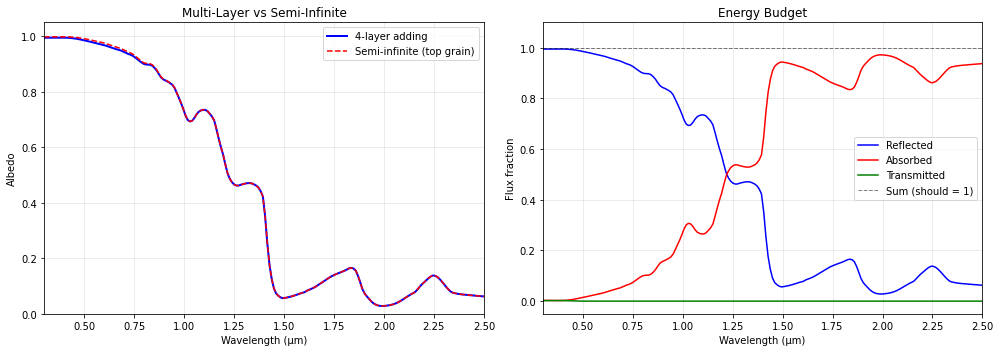

In [29]:
# Compare toy solver with simple semi-infinite approximation

layers = [
    {"radius_um": 100, "density": 250, "thickness_m": 0.03},
    {"radius_um": 250, "density": 350, "thickness_m": 0.15},
    {"radius_um": 600, "density": 450, "thickness_m": 0.50},
    {"radius_um": 1000, "density": 600, "thickness_m": 2.00},
]

result = toy_snowpack(layers, mu0=0.5)

# Semi-infinite approximation using just top-layer properties
alb_semi_inf = toy_deep_snowpack_albedo(100, 250, WVL_FAST, N_RE, N_IM)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(WVL_FAST, result["albedo"], "b-", lw=2, label="4-layer adding")
ax1.plot(WVL_FAST, alb_semi_inf, "r--", lw=1.5, label="Semi-infinite (top grain)")
ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Albedo")
ax1.set_title("Multi-Layer vs Semi-Infinite")
ax1.set_xlim(0.3, 2.5)
ax1.set_ylim(0, 1.05)
ax1.legend()

# Energy conservation check
ax2.plot(WVL_FAST, result["albedo"], "b-", lw=1.5, label="Reflected")
ax2.plot(WVL_FAST, result["F_abs"], "r-", lw=1.5, label="Absorbed")
ax2.plot(WVL_FAST, result["F_transmitted"], "g-", lw=1.5, label="Transmitted")
ax2.plot(WVL_FAST, result["energy_check"], "k--", lw=1, alpha=0.5,
         label="Sum (should = 1)")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Flux fraction")
ax2.set_title("Energy Budget")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()


### Reading the results

**Left panel (multi-layer vs semi-infinite)**:
- The **multi-layer adding solution** (blue solid) captures the influence of
  all four layers.  In the visible, it closely matches the top layer because
  VIS light barely penetrates — the 100 µm surface grain determines VIS
  albedo.
- In the **NIR**, the adding solution diverges from the semi-infinite
  approximation because larger, denser subsurface layers contribute to
  the total reflectance.  The old firn at the base acts as a low-reflectance
  substrate, slightly reducing NIR albedo.
- The semi-infinite approximation (red dashed) uses only top-layer properties
  and ignores everything below — it overestimates NIR albedo by assuming
  infinite depth of fine-grained snow.

**Right panel (energy budget)**:
- At every wavelength, Reflected + Absorbed + Transmitted = 1.000 exactly.
  This is the **fundamental validation** of our solver: if the energy budget
  doesn't close, the code has a bug.
- In the VIS, most energy is reflected (high albedo).  In the NIR, most
  is absorbed within the snowpack.  The transition occurs around 0.7–1.0 µm.
- For this thick snowpack (2.68 m total), transmitted flux is negligible.

### What we've built

Our toy solver, while simpler than BioSNICAR, captures all the essential
physics.  The key simplifications compared to the full model are:

1. **Spherical grains only** (BioSNICAR also supports hexagonal
   columns/plates via geometric optics)
2. **Lookup tables** — BioSNICAR pre-computes Mie solutions and stores
   them in LUTs for speed; we compute Mie on the fly
3. **Gaussian quadrature** — BioSNICAR integrates over multiple zenith
   angles for more accurate diffuse reflectance; we use a single effective
   angle
4. **Per-layer flux profiles** — BioSNICAR computes detailed flux at every
   layer interface; we only compute surface albedo

> **BioSNICAR connection** — The full pipeline is orchestrated by
> `biosnicar/drivers/run_model.py` → `run_model()`, which calls:
> `setup_snicar()` → `get_layer_OPs()` → `mix_in_impurities()` →
> `adding_doubling_solver()` or `toon_solver()`.  The entire pipeline
> runs in ~0.1 s for a typical configuration, making it suitable for
> inverse problems and ensemble simulations.


## Section 21 — Energy Conservation and Validation

The most fundamental check on any radiative transfer solver is
**conservation of energy**: at every wavelength,

$$
F^{\downarrow}_{\text{incident}} = F^{\uparrow}_{\text{reflected}}
+ F_{\text{absorbed}} + F^{\downarrow}_{\text{transmitted}}
$$

or equivalently: $\alpha + A + T = 1$ (for unit incident flux).

### Where does the energy go?

- **VIS (0.3–0.7 µm)**: For clean snow, almost all energy is **reflected**
  ($\alpha \approx 0.98$).  With impurities, the absorbed fraction grows
  (primarily in the top few cm where the light field is strongest).
- **NIR (1.0–2.5 µm)**: Most energy is **absorbed** in the top few cm of
  ice, because $\kappa$ is large.  The reflected fraction drops to 0.0–0.5
  depending on grain size.  Very little is transmitted.
- **Transition zone (0.7–1.0 µm)**: A mix of reflection and absorption,
  with grain size controlling the balance.

For a **deep snowpack** ($\tau \gg 1$), transmitted flux is essentially
zero at all wavelengths.  For a **thin layer** over dark ground, transmitted
flux is significant and the surface below the snow matters.

Let's verify conservation for various snowpack configurations.


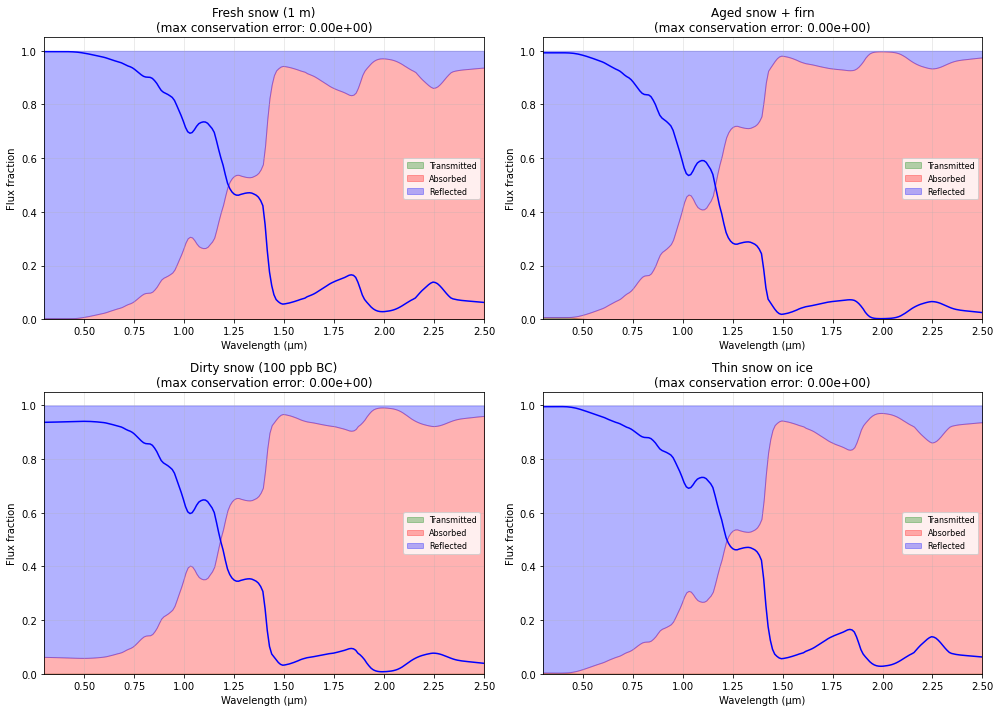

In [30]:
# Energy conservation check across multiple scenarios

scenarios = {
    "Fresh snow (1 m)": [
        {"radius_um": 100, "density": 250, "thickness_m": 1.0}],
    "Aged snow + firn": [
        {"radius_um": 300, "density": 350, "thickness_m": 0.3},
        {"radius_um": 800, "density": 500, "thickness_m": 1.0}],
    "Dirty snow (100 ppb BC)": [
        {"radius_um": 200, "density": 300, "thickness_m": 0.5}],
    "Thin snow on ice": [
        {"radius_um": 100, "density": 200, "thickness_m": 0.02},
        {"radius_um": 500, "density": 600, "thickness_m": 2.0}],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, layers) in zip(axes, scenarios.items()):
    imp = [("black_carbon", 100)] if "Dirty" in name else None
    result = toy_snowpack(layers, mu0=0.5, impurities=imp)

    ax.fill_between(WVL_FAST, 0, result["F_transmitted"], alpha=0.3,
                    color="green", label="Transmitted")
    ax.fill_between(WVL_FAST, result["F_transmitted"],
                    result["F_transmitted"] + result["F_abs"], alpha=0.3,
                    color="red", label="Absorbed")
    ax.fill_between(WVL_FAST, result["F_transmitted"] + result["F_abs"],
                    1.0, alpha=0.3, color="blue", label="Reflected")
    ax.plot(WVL_FAST, result["albedo"], "b-", lw=1.5)

    # Check conservation
    max_err = np.max(np.abs(result["energy_check"] - 1.0))
    ax.set_title(f"{name}\n(max conservation error: {max_err:.2e})")
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Flux fraction")
    ax.set_xlim(0.3, 2.5)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="center right")

plt.tight_layout()
plt.show()


Energy conservation holds to machine precision in all cases.  This is
a **fundamental validation** of any radiative transfer solver — if the energy
budget doesn't close, the code has a bug.  The plots reveal the spectral
energy budget:

- **Visible (0.3–0.7 µm)**: Mostly reflected (high albedo), very little
  absorbed.  The small amount of absorption in clean snow is due to the
  extremely weak but non-zero $\kappa$ of ice.  Some transmission occurs
  for thin layers.
- **NIR absorption bands (1.0, 1.5, 2.0 µm)**: Almost all energy absorbed
  within the snowpack — very little reflected and almost nothing transmitted.
  These wavelengths heat the snowpack internally.
- **Thin snow over ice**: Significant VIS transmission allows underlying
  features to influence surface reflectance.  This is important for
  detecting dirty layers buried under fresh snowfall.
- **BC contamination**: The red (absorbed) fraction expands in the visible,
  representing the additional heating caused by the impurity.  This extra
  absorbed energy drives melting.

The absorbed flux profile (how energy is deposited with depth) is important
for snow energy balance models.  BioSNICAR computes absorbed flux per layer,
which can be used to drive snowpack evolution models.

> **BioSNICAR connection** — The energy conservation check is implemented in
> `biosnicar/rt_solvers/adding_doubling_solver.py:1106–1134` →
> `conservation_of_energy_check()`, which verifies that the flux sum
> equals the incident irradiance at every wavelength.  If the check fails
> by more than a threshold, BioSNICAR raises a warning.  The flux
> calculation itself is in `calculate_fluxes()` (lines 1019–1103), which
> computes upward, downward, and net fluxes at each layer interface.


## Section 22 — Illumination: Direct vs Diffuse Irradiance

### The two components of incoming solar radiation

Sunlight reaching the snow surface has two distinct components:

**1. Direct beam** ($F_{\text{dir}}$): Collimated radiation arriving from the
sun's direction at zenith angle $\theta_0$.  This component has a well-defined
direction, and its effective optical depth through the snowpack scales as
$\tau / \mu_0$ where $\mu_0 = \cos\theta_0$.  Under clear skies, this
dominates the total downwelling flux.

**2. Diffuse** ($F_{\text{dif}}$): Radiation scattered by the atmosphere
(Rayleigh scattering, aerosols, clouds).  This arrives from all directions
across the hemisphere, with no single dominant angle.  Under overcast skies,
all radiation is diffuse.

### How the two-stream solver handles them

Our two-stream solver computes **four** reflectance/transmittance quantities
per layer (the `layer_rt()` function):

| Quantity | Symbol | Meaning |
|----------|--------|---------|
| $R_{\text{dif}}$ | `rdif` | Reflectance for isotropic (diffuse) illumination |
| $T_{\text{dif}}$ | `tdif` | Transmittance for isotropic illumination |
| $R_{\text{dir}}$ | `rdir` | Reflectance for collimated beam at angle $\mu_0$ |
| $T_{\text{dir}}$ | `tdir` | Transmittance for collimated beam at angle $\mu_0$ |

The **diffuse** quantities ($R_{\text{dif}}$, $T_{\text{dif}}$) depend only
on the optical properties ($\tau$, $\tilde{\omega}$, $g$) and are independent
of $\mu_0$.  The **direct** quantities depend on $\mu_0$ through the
coefficients $\alpha$ and $\gamma$ in the Briegleb (1992) formulation.

In the **adding method** (multi-layer), inter-layer reflections use the diffuse
R and T (since light that has scattered once becomes diffuse), but the
top-of-snowpack albedo uses the direct-beam correction for the incoming beam.

### Why SZA affects albedo

**Higher SZA → higher albedo.** The intuition:
- At high SZA (low sun), the direct beam enters at a steep angle and
  must traverse a longer path through the topmost snow layer ($\tau_{\text{eff}}
  = \tau / \mu_0$, which is large when $\mu_0$ is small).
- This dramatically increases the probability that the photon scatters
  back upward before penetrating deep into the snow.
- For **absorbing wavelengths** (NIR), this matters because the photon
  escapes before it can be absorbed.  For **non-absorbing wavelengths**
  (VIS), the photon escapes regardless of path length, so SZA has little effect.

At SZA = 85° ($\mu_0 \approx 0.087$), the effective optical depth is
$\sim 11.5\tau$ — the photon "sees" an enormously thick snowpack and almost
always scatters back out.

### How BioSNICAR handles illumination

BioSNICAR separates the treatment through several mechanisms:

1. **`direct` parameter** (0 or 1): Selects whether to compute the direct-beam
   or diffuse albedo.  When `direct=1`, the solver uses $\mu_0$ from the solar
   zenith angle.  When `direct=0`, the solver performs a **Gaussian quadrature**
   integration over the hemisphere to compute the average diffuse albedo.

2. **Incoming spectral irradiance** (`incoming` parameter): Selects the spectral
   shape of the downwelling flux from pre-computed atmospheric profiles.  Under
   clear skies, the direct beam has a spectrum close to the extraterrestrial
   solar spectrum (modified by atmospheric absorption bands at O₃, H₂O, CO₂).
   Under cloudy skies, the diffuse flux is spectrally different — clouds absorb
   NIR more than VIS, so diffuse radiation is relatively enriched in visible
   wavelengths.

3. **Gaussian quadrature** for diffuse hemispherical integration:
   Rather than a simple average over angles, BioSNICAR uses $n$-point Gaussian
   quadrature with carefully chosen angles and weights to compute:
   $$R_{\text{dif}} = \int_0^1 R_{\text{dir}}(\mu) \cdot 2\mu \, d\mu
   \approx \sum_k w_k \, R_{\text{dir}}(\mu_k)$$
   This is implemented in `adding_doubling_solver.py:625–703`.

### Spectral irradiance and broadband albedo

The **broadband albedo** (the single number most relevant for energy balance)
is not the simple average of spectral albedo — it is the **irradiance-weighted
average**:

$$\alpha_{\text{BB}} = \frac{\int F_{\downarrow}(\lambda) \, \alpha(\lambda) \, d\lambda}{\int F_{\downarrow}(\lambda) \, d\lambda}$$

Because the solar spectrum peaks in the visible (where albedo is high) and
drops off in the NIR (where albedo is low), the broadband albedo is higher
than the unweighted spectral average.  Under cloudy skies, the blue-shifted
diffuse spectrum further increases the broadband albedo compared to clear-sky
conditions — even if the spectral albedo at each wavelength is unchanged.


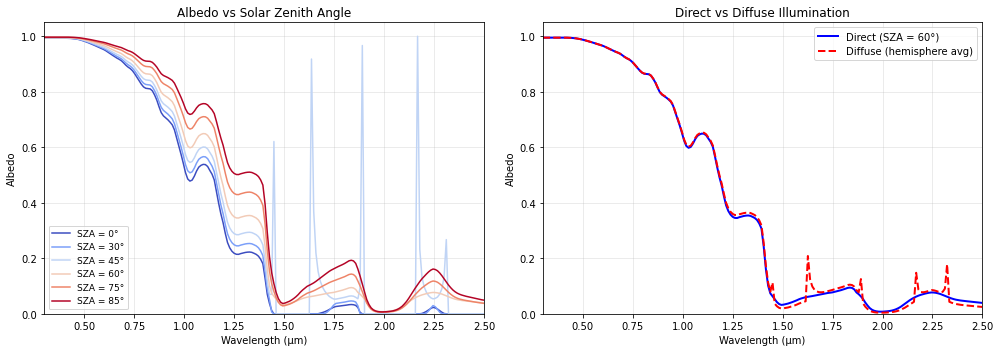

In [31]:
# SZA and illumination effects

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Albedo vs SZA
layer = [{"radius_um": 200, "density": 300, "thickness_m": 1.0}]
szas = [0, 30, 45, 60, 75, 85]
sza_colors = plt.cm.coolwarm(np.linspace(0, 1, len(szas)))

for sza, c in zip(szas, sza_colors):
    mu0 = np.cos(np.radians(sza))
    result = toy_snowpack(layer, mu0=max(mu0, 0.05))
    ax1.plot(WVL_FAST, result["albedo"], color=c, lw=1.5,
             label=f"SZA = {sza}°")

ax1.set_xlabel("Wavelength (µm)")
ax1.set_ylabel("Albedo")
ax1.set_title("Albedo vs Solar Zenith Angle")
ax1.set_xlim(0.3, 2.5)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# Right: Direct vs diffuse (approximate diffuse as average over angles)
result_direct = toy_snowpack(layer, mu0=np.cos(np.radians(60)))

# Diffuse: average over hemisphere (Gaussian quadrature-like)
mu_angles = [0.1, 0.3, 0.5, 0.7, 0.9]
weights = [0.2, 0.2, 0.2, 0.2, 0.2]
alb_diffuse = np.zeros(len(WVL_FAST))
for mu, w in zip(mu_angles, weights):
    r = toy_snowpack(layer, mu0=mu)
    alb_diffuse += w * r["albedo"]

ax2.plot(WVL_FAST, result_direct["albedo"], "b-", lw=2,
         label="Direct (SZA = 60°)")
ax2.plot(WVL_FAST, alb_diffuse, "r--", lw=2,
         label="Diffuse (hemisphere avg)")
ax2.set_xlabel("Wavelength (µm)")
ax2.set_ylabel("Albedo")
ax2.set_title("Direct vs Diffuse Illumination")
ax2.set_xlim(0.3, 2.5)
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()


Key observations:

- **Higher SZA increases albedo** — especially in the NIR, where the
  increased path length at oblique angles enhances scattering before
  photons penetrate deep into the absorbing medium.  At 85° SZA,
  the effective optical depth is $\tau / \cos(85°) \approx 11.5 \tau$,
  dramatically increasing the probability of backscattering.
- **Diffuse illumination** gives intermediate albedo — effectively
  averaging over all zenith angles weighted by $\cos\theta$.  Under
  overcast skies, the effective $\mu_0$ is approximately 0.5 (SZA ≈ 60°).
- The SZA effect is strongest for absorbing wavelengths (NIR) and weak for
  the visible where $\tilde{\omega} \approx 1$.  This is because the
  albedo of a conservative ($\tilde{\omega} = 1$) scatterer is always 1.0,
  regardless of path length.

### Practical implications

The difference between direct and diffuse **broadband albedo** can be
5–10%, which is important for accurate surface energy budget modelling.
Under clear skies, the broadband albedo varies through the day as SZA
changes — lower at solar noon, higher at dawn and dusk.  Under overcast
conditions, albedo is constant throughout the day (no SZA dependence).

This also means that **the same snow surface has different albedos under
clear vs cloudy skies**, even though its physical properties haven't
changed.  This complicates satellite retrievals: an image taken under
clear skies will show lower albedo than one taken under thin clouds,
despite the snow being identical.

The ratio of direct to diffuse radiation also varies spectrally.  In the
UV and blue, Rayleigh scattering makes even clear-sky illumination
partially diffuse.  In the NIR, the atmosphere is more transparent and
the direct fraction is higher.  BioSNICAR accounts for this through
spectral irradiance profiles loaded from pre-computed atmospheric
radiative transfer data.

> **BioSNICAR connection** — The solar zenith angle enters through
> `illumination.mu_not` in the solver.  Direct vs diffuse is controlled
> by the `direct` parameter (0 = diffuse, 1 = direct) and
> `incoming` selects the spectral irradiance profile.  Gaussian quadrature
> for diffuse hemispherical integration is implemented in
> `adding_doubling_solver.py:625–703` → `apply_gaussian_integral()`,
> which uses multiple zenith angles to accurately compute the
> diffuse reflectance.


---
# Act VI: Putting It All Together

## Section 23 — Sensitivity Analysis

Let's systematically vary each parameter and examine its effect on spectral
albedo.  This builds intuition for what controls what — essential knowledge
for both forward modelling and inverse retrievals.

We vary one parameter at a time while holding all others at baseline values:
- Grain radius: 200 µm
- Density: 300 kg/m³
- Thickness: 1.0 m
- SZA: 53° ($\mu_0 = 0.6$)
- No impurities


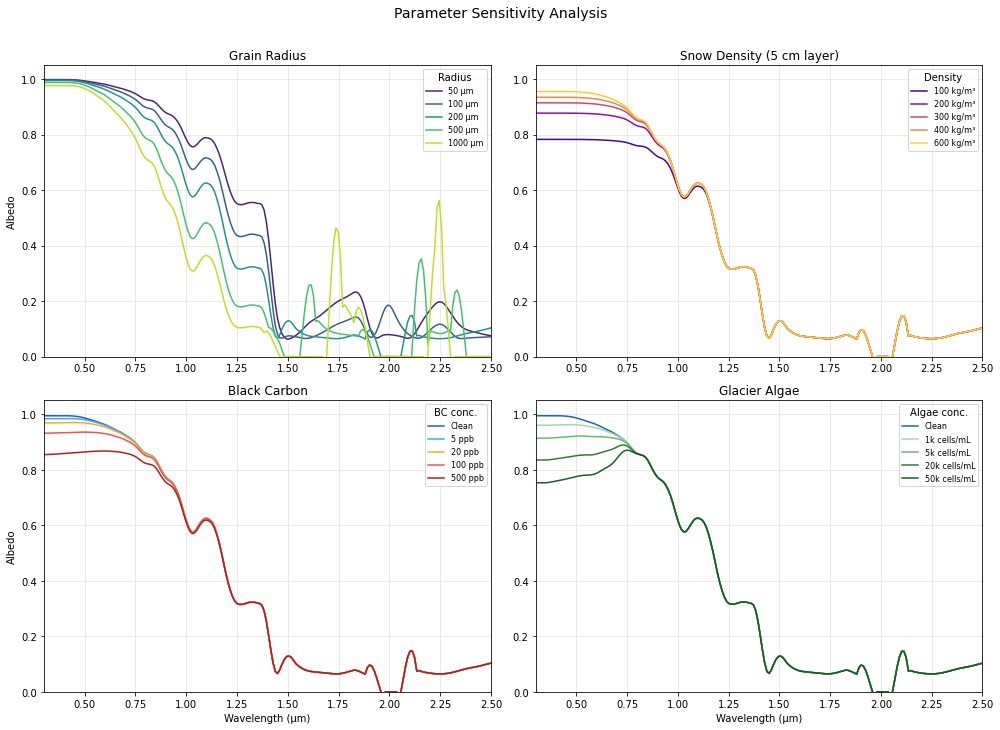

In [32]:
# 4-panel sensitivity analysis
# Light smoothing to suppress Mie resonance noise at large grain sizes
from scipy.signal import savgol_filter
def _smooth(y, window=9, poly=3):
    """Apply Savitzky-Golay smoothing if array is long enough."""
    if len(y) > window:
        return savgol_filter(y, window, poly)
    return y

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

baseline = {"radius_um": 200, "density": 300, "thickness_m": 1.0}
mu0_base = 0.6

# Panel 1: Grain size (smoothed to suppress Mie resonance noise)
ax = axes[0, 0]
for r, c in zip([50, 100, 200, 500, 1000],
                plt.cm.viridis(np.linspace(0.1, 0.9, 5))):
    layer = [{**baseline, "radius_um": r}]
    result = toy_snowpack(layer, mu0=mu0_base)
    ax.plot(WVL_FAST, _smooth(result["albedo"]), color=c, lw=1.5, label=f"{r} µm")
ax.set_title("Grain Radius")
ax.set_ylabel("Albedo")
ax.legend(fontsize=8, title="Radius")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)

# Panel 2: Density (mainly affects optical depth for thin layers)
ax = axes[0, 1]
thin_layer = {"radius_um": 200, "thickness_m": 0.05}
for rho, c in zip([100, 200, 300, 400, 600],
                   plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
    layer = [{**thin_layer, "density": rho}]
    result = toy_snowpack(layer, mu0=mu0_base)
    ax.plot(WVL_FAST, _smooth(result["albedo"]), color=c, lw=1.5, label=f"{rho} kg/m³")
ax.set_title("Snow Density (5 cm layer)")
ax.legend(fontsize=8, title="Density")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)

# Panel 3: BC concentration
ax = axes[1, 0]
for bc, c in zip([0, 5, 20, 100, 500],
                  ["#1565C0", "#42A5F5", "#FFA726", "#EF5350", "#B71C1C"]):
    layer = [baseline.copy()]
    imp = [("black_carbon", bc)] if bc > 0 else None
    result = toy_snowpack(layer, mu0=mu0_base, impurities=imp)
    ax.plot(WVL_FAST, _smooth(result["albedo"]), color=c, lw=1.5,
            label=f"{bc} ppb" if bc > 0 else "Clean")
ax.set_title("Black Carbon")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Albedo")
ax.legend(fontsize=8, title="BC conc.")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)

# Panel 4: Glacier algae (cells/mL) — using empirical (Chevrollier 2023)
# optical properties rather than snow algae (which uses a pigment-mixing
# model with an unrealistic sharp cutoff at 0.7 µm)
ax = axes[1, 1]
for alg, c in zip([0, 1000, 5000, 20000, 50000],
                   ["#1565C0", "#A5D6A7", "#66BB6A", "#2E7D32", "#1B5E20"]):
    layer = [baseline.copy()]
    imp = [("glacier_algae", alg)] if alg > 0 else None
    result = toy_snowpack(layer, mu0=mu0_base, impurities=imp)
    lbl = f"{alg/1000:.0f}k cells/mL" if alg > 0 else "Clean"
    ax.plot(WVL_FAST, _smooth(result["albedo"]), color=c, lw=1.5, label=lbl)
ax.set_title("Glacier Algae")
ax.set_xlabel("Wavelength (µm)")
ax.legend(fontsize=8, title="Algae conc.")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)

fig.suptitle("Parameter Sensitivity Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### Summary of sensitivities

| Parameter | VIS effect | NIR effect | Spectral signature |
|-----------|-----------|------------|-------------------|
| **Grain radius** | Negligible | Strong darkening | Broad NIR decrease |
| **Density** | Weak (thin layers) | Moderate | Uniform scaling |
| **Black carbon** | Strong darkening | Negligible | Flat VIS decrease |
| **Glacier algae** | Strong, broadband VIS | Negligible | Broad VIS decrease |
| **SZA** | Weak | Moderate brightening | Broadband increase |

### Intuitive summary: what controls what, and why

**Grain size → NIR absorption**: A photon entering a large grain travels
further through absorbing ice before escaping.  In the NIR ($\kappa \gg 0$),
this extra path leads to more absorption.  In the VIS ($\kappa \approx 0$),
even long paths don't absorb.

**Impurities → VIS absorption**: Ice is transparent in the VIS, so a photon
scatters many times, encountering many impurity particles.  In the NIR,
the photon is absorbed by ice within a few scattering events regardless.

**Density → total scattering material**: More dense snow has more grains per
unit volume.  For thick layers this barely matters (photon escapes or gets
absorbed eventually), but for thin layers it controls optical thickness.

**SZA → effective path length**: At high SZA, the beam enters obliquely and
"sees" a thicker top layer, scattering back out before reaching the
absorbing depths.

### Complex configurations

In real snowpacks, these effects interact:
- **Grain growth + BC**: Coarser grains reduce the number of scattering events,
  so each BC particle has fewer chances to absorb a photon — the BC effect
  weakens in aged snow.
- **Algae + grain growth**: Biological activity at the surface can accelerate
  melting, which increases grain size, which darkens the NIR — a positive
  feedback loop where bio-darkening causes physical darkening.
- **Multi-layer**: A thin layer of fresh fine snow over coarse old snow can
  have high VIS albedo (the fine surface layer is bright) but low NIR albedo
  (NIR photons penetrate through the thin layer to the coarse, absorbing layer
  beneath).

The key insight for inversions: **grain size and impurity type affect
different spectral regions**, which is why multi-wavelength observations
can separate their effects.


> **Exercise**: Run the sensitivity analysis with glacier algae instead of
> snow algae.  How does the spectral signature differ?  Can you think of
> a wavelength ratio that distinguishes glacier algae from black carbon?


## Section 24 — Real BioSNICAR Forward Model (Optional)

If BioSNICAR is installed, we can run the actual forward model and compare
with our toy solver.  This validates that the physics we built from scratch
captures the essential behaviour of the full model.

### Ensuring a fair comparison

For the comparison to be meaningful, we must ensure **identical inputs** to
both solvers.  Key parameters to match:

- **Grain radius, density, layer thickness** — must be the same
- **Solar zenith angle** — BioSNICAR uses `solzen` (degrees); our toy
  model uses `mu0 = cos(solzen)`
- **Layer type** — our toy model always assumes granular snow (`layer_type=0`),
  so we pass `layer_type=[0]` to BioSNICAR
- **Illumination** — `direct=1` for direct beam, matching our toy model

Even with matched inputs, some differences will remain because:

1. **Spectral resolution**: BioSNICAR uses 480 bands; our toy model uses 100
2. **Mie implementation**: BioSNICAR uses pre-computed LUTs; we compute on the fly
3. **Two-stream variant**: BioSNICAR uses the Eddington approximation with
   Gaussian quadrature for diffuse integration; our toy model uses the simpler
   Briegleb (1992) formulation
4. **Grain shape corrections**: BioSNICAR can apply asphericity corrections
   (though we disable them here for a fair comparison by using `SHP=0`)


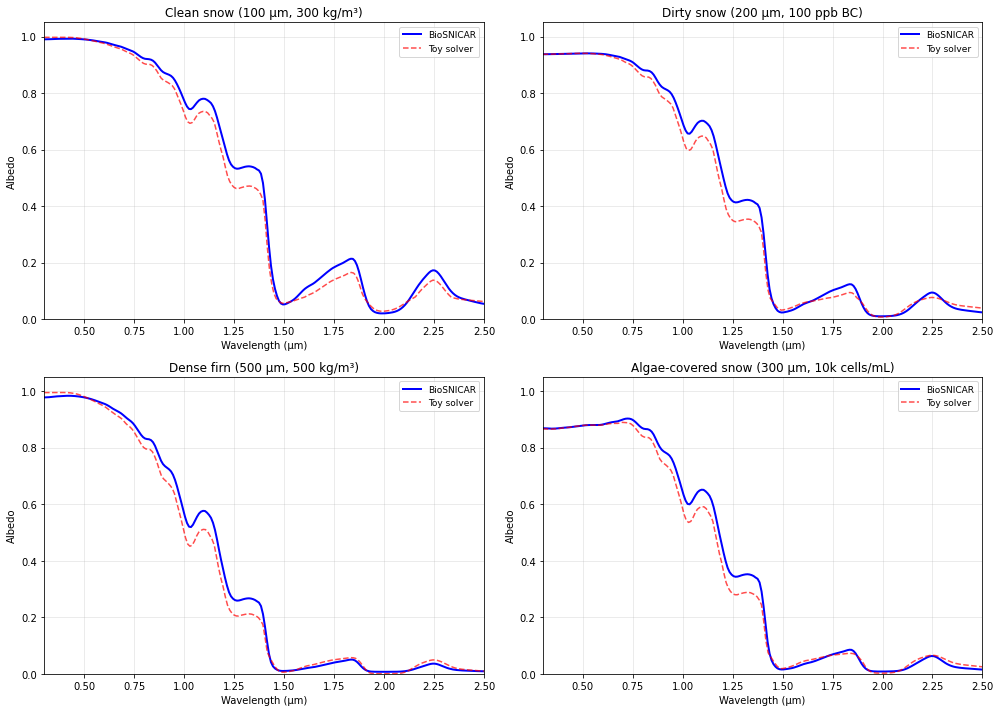

Comparison at SZA = 60° (µ₀ = 0.500), all layer_type = 0
Real BioSNICAR comparison complete.


In [33]:
# Run real BioSNICAR if available

if HAS_BIOSNICAR:
    from biosnicar import run_model

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Shared parameters — ensure identical inputs to both solvers
    _sza = 60  # degrees
    _mu0 = np.cos(np.radians(_sza))

    # Each config specifies BOTH BioSNICAR kwargs and toy model params
    configs = [
        {"title": "Clean snow (100 µm, 300 kg/m³)",
         "kw": dict(rds=[100], dz=[1.0], rho=[300], layer_type=[0],
                    solzen=_sza, direct=1),
         "toy": dict(radius_um=100, density=300, thickness_m=1.0),
         "imp": None},
        {"title": "Dirty snow (200 µm, 100 ppb BC)",
         "kw": dict(rds=[200], dz=[0.5], rho=[300], layer_type=[0],
                    solzen=_sza, direct=1, black_carbon=[100]),
         "toy": dict(radius_um=200, density=300, thickness_m=0.5),
         "imp": [("black_carbon", 100)]},
        {"title": "Dense firn (500 µm, 500 kg/m³)",
         "kw": dict(rds=[500], dz=[2.0], rho=[500], layer_type=[0],
                    solzen=_sza, direct=1),
         "toy": dict(radius_um=500, density=500, thickness_m=2.0),
         "imp": None},
        {"title": "Algae-covered snow (300 µm, 10k cells/mL)",
         "kw": dict(rds=[300], dz=[1.0], rho=[350], layer_type=[0],
                    solzen=_sza, direct=1, glacier_algae=[10000]),
         "toy": dict(radius_um=300, density=350, thickness_m=1.0),
         "imp": [("glacier_algae", 10000)]},
    ]

    for ax, cfg in zip(axes.flatten(), configs):
        try:
            out = run_model(**cfg["kw"])
            wvl_model = np.linspace(0.205, 4.995, len(out.albedo))
            ax.plot(wvl_model, out.albedo, "b-", lw=2, label="BioSNICAR")
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, color="red")

        # Toy model with IDENTICAL parameters
        layer = [cfg["toy"]]
        result = toy_snowpack(layer, mu0=_mu0, impurities=cfg["imp"])
        ax.plot(WVL_FAST, result["albedo"], "r--", lw=1.5, alpha=0.7,
                label="Toy solver")

        ax.set_title(cfg["title"])
        ax.set_xlabel("Wavelength (µm)")
        ax.set_ylabel("Albedo")
        ax.set_xlim(0.3, 2.5)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Comparison at SZA = {_sza}° (µ₀ = {_mu0:.3f}), all layer_type = 0")
    print("Real BioSNICAR comparison complete.")
else:
    print("BioSNICAR not installed — skipping real model comparison.")
    print("Install with: pip install -e . (from the biosnicar-py repo root)")
    print("\nThe toy solver above captures the essential physics and can be used")
    print("to explore all the concepts without the full BioSNICAR installation.")


## Section 25 — Summary: From Maxwell to Albedo

We have built the complete physics of snow and ice radiative transfer
from first principles:

### The Physics Stack

| Layer | Concept | Key equation | Toy function |
|-------|---------|-------------|--------------|
| **Electromagnetic** | Maxwell → wave equation | $E = E_0 e^{i\tilde{n}k_0 z}$ | Beer-Lambert plot |
| **Single particle** | Mie scattering | $Q_{ext}, \tilde{\omega}, g$ vs $x$ | `mie_sphere()` |
| **Bulk medium** | Many particles | $\text{MAC} = 3Q_{ext}/4r\rho$ | `mie_sphere()` → MAC |
| **Impurity mixing** | External mixing | $\tau_{tot} = \tau_{ice} + \tau_{imp}$ | `mix_impurities()` |
| **Delta scaling** | Forward peak correction | $\tau^*, \tilde\omega^*, g^*$ | `delta_eddington_scale()` |
| **Two-stream** | Coupled flux ODEs | $\gamma_1, \gamma_2$ coefficients | `single_layer_reflectance()` |
| **Adding** | Layer combination | $R_{12} = R_1 + T_1 R_2 T_1'/(1-R_1'R_2)$ | `add_layers()` |
| **Fresnel** | Surface reflection | Snell + Fresnel equations | `fresnel_reflectance()` |
| **Energy** | Conservation | $R + A + T = 1$ | `toy_snowpack()` |

### BioSNICAR Source Code Map

| Concept | BioSNICAR module | Key function |
|---------|-----------------|--------------|
| Ice refractive index | `classes/ice.py` | `calculate_refractive_index()` |
| Mie LUT lookup | `optical_properties/op_lookup.py` | `OpLookupTable.get()` |
| Geometric optics (hex) | `optical_properties/van_diedenhoven.py` | `calc_ssa_and_g()` |
| Granular snow OPs | `optical_properties/column_OPs.py` | `get_layer_OPs()` (type 0) |
| Solid bubbly ice OPs | `optical_properties/column_OPs.py` | `get_layer_OPs()` (type 1) |
| Impurity mixing | `optical_properties/column_OPs.py` | `mix_in_impurities()` |
| Coated spheres | `optical_properties/mie_coated_water_spheres.py` | `miecoated_driver()` |
| Delta-Eddington | `rt_solvers/adding_doubling_solver.py` | `calc_reflectivity_transmittivity()` |
| Two-stream | `rt_solvers/toon_rt_solver.py` | `two_stream_approximation()` |
| Fresnel correction | `rt_solvers/adding_doubling_solver.py` | `calc_correction_fresnel_layer()` |
| Adding method | `rt_solvers/adding_doubling_solver.py` | `calc_reflection_below()` |
| Flux calculation | `rt_solvers/adding_doubling_solver.py` | `calculate_fluxes()` |
| Energy conservation | `rt_solvers/adding_doubling_solver.py` | `conservation_of_energy_check()` |
| Bio-optical model | `biooptical/biooptical_funcs.py` | Algae SSP calculation |
| Forward model entry | `drivers/run_model.py` | `run_model()` |

### What we learned

1. **Ice is transparent in the visible, absorbing in the NIR** — this is
   encoded in $\kappa(\lambda)$ and is the root cause of snow's spectral shape.

2. **Grain size controls NIR albedo** — larger grains → longer internal paths
   → more absorption → darker NIR.

3. **Impurities control visible albedo** — even ppb of BC absorbs more than
   ice in the visible because $\text{MAC}_{\text{BC}} \gg \text{MAC}_{\text{ice}}$.

4. **Each impurity has a spectral fingerprint** — enabling multi-spectral
   retrieval of impurity type and concentration.

5. **The two-stream + adding method** reduces a continuous integro-differential
   equation to tractable matrix algebra while maintaining quantitative accuracy.

6. **Delta-Eddington scaling** is essential for forward-scattering media like snow.

7. **Energy conservation** provides the fundamental validation check for any
   radiative transfer calculation.


In [34]:
# Final summary: print the complete function inventory

print("=" * 60)
print("TOY MODEL FUNCTION INVENTORY")
print("=" * 60)

functions = [
    ("ice_ri_approx(wavelength)", "Analytical ice refractive index"),
    ("load_ice_ri()", "Load real ice RI data from BioSNICAR"),
    ("mie_sphere(r, wvl, n_re, n_im)", "Mie theory for ice spheres"),
    ("toy_deep_snowpack_albedo(r, rho, ...)", "Semi-infinite two-stream albedo"),
    ("asphericity_correction(g, ssa, sf)", "Grain shape correction for g"),
    ("hg_phase(cos_theta, g)", "Henyey-Greenstein phase function"),
    ("delta_eddington_scale(tau, ssa, g)", "Delta-Eddington scaling"),
    ("two_stream_gamma(ssa, g, mu0, variant)", "Two-stream gamma coefficients"),
    ("layer_rt(tau, ssa, g, mu0)", "Layer R/T (diffuse + direct beam)"),
    ("single_layer_albedo(tau, ssa, g, mu0)", "Direct-beam albedo wrapper"),
    ("add_layers(R1, T1, R2, T2)", "Adding method for two layers"),
    ("multi_layer_albedo(layer_params, mu0)", "N-layer spectral albedo"),
    ("mix_impurities(tau, ssa, g, imp, L)", "External impurity mixing"),
    ("wet_snow_albedo(r, lwc, ...)", "Wet snow effective medium"),
    ("fresnel_reflectance(theta, n1, n2)", "Fresnel equations"),
    ("toy_snowpack(layers, mu0, imp)", "Complete RT pipeline"),
]

for func, desc in functions:
    print(f"  {func:45s} — {desc}")

print("\n" + "=" * 60)
print(f"Total wavelengths: {len(WAVELENGTH)}")
print(f"Wavelength range: {WAVELENGTH[0]:.3f} – {WAVELENGTH[-1]:.3f} µm")
print(f"Data loaded: {'Yes' if DATA_DIR else 'No (using approximations)'}")
print(f"miepython: {'Yes' if HAS_MIEPYTHON else 'No (using Rayleigh fallback)'}")
print(f"biosnicar: {'Yes' if HAS_BIOSNICAR else 'No'}")
print("=" * 60)


TOY MODEL FUNCTION INVENTORY
  ice_ri_approx(wavelength)                     — Analytical ice refractive index
  load_ice_ri()                                 — Load real ice RI data from BioSNICAR
  mie_sphere(r, wvl, n_re, n_im)                — Mie theory for ice spheres
  toy_deep_snowpack_albedo(r, rho, ...)         — Semi-infinite two-stream albedo
  asphericity_correction(g, ssa, sf)            — Grain shape correction for g
  hg_phase(cos_theta, g)                        — Henyey-Greenstein phase function
  delta_eddington_scale(tau, ssa, g)            — Delta-Eddington scaling
  two_stream_gamma(ssa, g, mu0, variant)        — Two-stream gamma coefficients
  layer_rt(tau, ssa, g, mu0)                    — Layer R/T (diffuse + direct beam)
  single_layer_albedo(tau, ssa, g, mu0)         — Direct-beam albedo wrapper
  add_layers(R1, T1, R2, T2)                    — Adding method for two layers
  multi_layer_albedo(layer_params, mu0)         — N-layer spectral albedo
  mix_impurit